# PHÂN TÍCH VÀ DỰ BÁO RỦI RO DANH MỤC TÍN DỤNG TIÊU DÙNG

**Bộ dữ liệu:** Home Credit Default Risk  
**Đơn vị phân tích của mô hình:** một hồ sơ khách hàng trong `application_train`  
**Biến mục tiêu:** `TARGET = 1` biểu thị khách hàng có vấn đề trả nợ theo định nghĩa của bộ dữ liệu; khái niệm này không đồng nhất hoàn toàn với “vỡ nợ” hoặc “nợ xấu” theo quy định của ngân hàng Việt Nam.

## Mục tiêu nghiên cứu

Nghiên cứu được triển khai theo hai hướng bổ trợ:

1. **Phân tích chất lượng lịch sử tín dụng:** đánh giá DPD hiện tại, DPD xấu nhất từng quan sát, xu hướng delinquency theo tháng tương đối, Vintage proxy và Roll Rate từ `bureau` và `bureau_balance`.
2. **Dự báo và phân tầng rủi ro hồ sơ:** xây dựng đặc trưng từ nhiều bảng lịch sử, so sánh Logistic Regression với LightGBM, hiệu chỉnh xác suất PD, đánh giá KS–Decile–Lift, chuyển PD thành điểm và phân hạng rủi ro A–E.

> DPD, Vintage và Roll Rate trong notebook phản ánh **lịch sử tín dụng Bureau trước hồ sơ hiện tại**, không phải chuỗi thanh toán sau giải ngân của chính khoản vay đang được dự báo.

## Câu hỏi nghiên cứu
- Chất lượng và độ phủ lịch sử tín dụng trong bộ dữ liệu như thế nào?
- DPD, Vintage proxy và Roll Rate phản ánh hành vi rủi ro nào?
- LightGBM có cải thiện khả năng dự báo so với Logistic Regression không?
- Mô hình có thể được sử dụng như thế nào để phân tầng danh mục?

## Thiết kế phương pháp nghiên cứu

- Tổng hợp các bảng lịch sử về đúng cấp `SK_ID_CURR`; riêng `installments_payments` được gom về **cấp kỳ thanh toán** trước khi tạo đặc trưng để tránh cộng lặp.
- Phân biệt **DPD hiện tại** từ `CREDIT_DAY_OVERDUE` với **Ever DPD** từ chuỗi trạng thái `bureau_balance.STATUS`.
- Vintage được trình bày là **Vintage proxy** suy ra từ `DAYS_CREDIT`; Roll Rate giữ `Unknown` và `Closed` ở bảng kiểm tra dữ liệu nhưng loại `Unknown` khỏi mẫu số nghiệp vụ.
- Chia dữ liệu độc lập thành **train 60% – calibration 10% – threshold 10% – test 20%** bằng stratified split.
- Logistic Regression và LightGBM sử dụng cùng 5-fold stratified CV trên train; tập test không tham gia lựa chọn mô hình.
- Logistic Regression thực hiện imputation, capping, scaling và one-hot encoding bên trong pipeline; LightGBM sử dụng missing và categorical native.
- Platt Scaling được fit trên tập calibration; threshold tối đa F1 được chọn trên tập threshold riêng.
- Hiệu năng được đánh giá bằng ROC-AUC, Average Precision, GINI, bootstrap CI, Brier Score, Log Loss, KS, Decile, Lift, điểm rủi ro và Risk Grade.

**Kết quả chính:** LightGBM được chọn với CV AUC **0,7778**, test AUC **0,7844**, Average Precision **0,2720** và KS **0,4338**. Mô hình phù hợp cho **xếp hạng, phân tầng và ưu tiên quản trị rủi ro**, nhưng chưa đủ cơ sở để trở thành quy tắc phê duyệt hoặc từ chối tín dụng tự động.

## CHƯƠNG 2. KẾT QUẢ NGHIÊN CỨU VÀ THẢO LUẬN

### 2.1. Tiền xử lý và mô tả dữ liệu

#### 2.1.1. Thiết lập môi trường và nạp dữ liệu

Nghiên cứu sử dụng năm bảng chính của bộ Home Credit:

- `application_train`: 307.511 hồ sơ và 122 biến;
- `bureau`: 1.716.428 khoản tín dụng tại tổ chức khác;
- `bureau_balance`: 27.299.925 quan sát trạng thái theo tháng;
- `previous_application`: 1.670.214 hồ sơ vay trước;
- `installments_payments`: 13.605.401 dòng thanh toán.

Hai bảng `POS_CASH_balance` và `credit_card_balance` có sẵn nhưng được đặt `USE_EXTENDED_BEHAVIOR_TABLES = False` trong mô hình cuối để giới hạn bộ nhớ và giữ phạm vi đồ án cá nhân ở mức có thể tái lập trên Google Colab.

In [ ]:
# ── Thư viện cần thiết cho toàn bộ pipeline tín dụng ──────────────────────
import gc
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pointbiserialr
from scipy.optimize import minimize
from scipy.special import expit

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    average_precision_score,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
print('✓ Libraries loaded')


✓ Libraries loaded


In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────
# Option A: Kaggle/Colab
import kagglehub
path = kagglehub.dataset_download('julianocosta/home-credit')
DATA_DIR = Path(path)

# Option B: Local path
# DATA_DIR = Path('/path/to/home-credit')


def read_required_csv(filename, usecols=None, dtype=None):
    file_path = DATA_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(f'Không tìm thấy file bắt buộc: {file_path}')
    return pd.read_csv(file_path, usecols=usecols, dtype=dtype)


app_train = read_required_csv('application_train.csv')
bureau = read_required_csv('bureau.csv')
bureau_bal = read_required_csv(
    'bureau_balance.csv',
    dtype={'SK_ID_BUREAU': 'int32', 'MONTHS_BALANCE': 'int16', 'STATUS': 'category'}
)
prev_app = read_required_csv('previous_application.csv')
installments = read_required_csv(
    'installments_payments.csv',
    dtype={
        'SK_ID_PREV': 'int32', 'SK_ID_CURR': 'int32',
        'NUM_INSTALMENT_VERSION': 'float32', 'NUM_INSTALMENT_NUMBER': 'int16',
        'DAYS_INSTALMENT': 'float32', 'DAYS_ENTRY_PAYMENT': 'float32',
        'AMT_INSTALMENT': 'float32', 'AMT_PAYMENT': 'float32'
    }
)

# Hai bảng hành vi bổ sung của Home Credit. Mặc định tắt để notebook chạy ổn
# trên Colab RAM tiêu chuẩn. Bật True nếu muốn bổ sung POS/CASH và thẻ tín dụng.
USE_EXTENDED_BEHAVIOR_TABLES = False
POS_CASH_PATH = DATA_DIR / 'POS_CASH_balance.csv'
CREDIT_CARD_PATH = DATA_DIR / 'credit_card_balance.csv'

print(f'app_train    : {app_train.shape}')
print(f'bureau       : {bureau.shape}')
print(f'bureau_bal   : {bureau_bal.shape}')
print(f'prev_app     : {prev_app.shape}')
print(f'installments : {installments.shape}')
print(f'POS/CASH available     : {POS_CASH_PATH.exists()}')
print(f'Credit card available  : {CREDIT_CARD_PATH.exists()}')
print(f'Use extended tables    : {USE_EXTENDED_BEHAVIOR_TABLES}')


Using Colab cache for faster access to the 'home-credit' dataset.
app_train    : (307511, 122)
bureau       : (1716428, 17)
bureau_bal   : (27299925, 3)
prev_app     : (1670214, 37)
installments : (13605401, 8)
POS/CASH available     : True
Credit card available  : True
Use extended tables    : False


#### 2.1.2. Khám phá cấu trúc dữ liệu

##### Nhóm biến trong bảng hồ sơ chính

Các biến trong `application_train` được nhóm theo ý nghĩa nghiệp vụ để hỗ trợ kiểm tra dữ liệu và lựa chọn đặc trưng. Nhóm thông tin tòa nhà và nhóm cờ tài liệu gồm tổng cộng **67 biến** được loại theo danh sách xác định trước nhằm giảm chiều dữ liệu và tập trung vào các tín hiệu phù hợp hơn với mục tiêu phân tích danh mục.

- Nhóm biến tòa nhà có tỷ lệ thiếu rất cao ở nhiều cột.
- Nhóm cờ tài liệu có số lượng lớn nhưng tín hiệu đơn biến nhìn chung hạn chế.
- Quyết định loại biến không được thực hiện chỉ bằng một ngưỡng missing tự động và không sử dụng kết quả trên tập test.

In [ ]:
# ── Feature group classification ───────────────────────────────────────────
cols_id        = ['SK_ID_CURR']
cols_target    = ['TARGET']
cols_personal  = ['CODE_GENDER','DAYS_BIRTH','CNT_CHILDREN','NAME_FAMILY_STATUS',
                  'NAME_EDUCATION_TYPE','NAME_INCOME_TYPE','DAYS_EMPLOYED',
                  'CNT_FAM_MEMBERS','OCCUPATION_TYPE','DAYS_REGISTRATION',
                  'DAYS_ID_PUBLISH','DAYS_LAST_PHONE_CHANGE']
cols_financial = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
                  'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
cols_contract  = ['NAME_CONTRACT_TYPE','NAME_TYPE_SUITE','FLAG_OWN_CAR',
                  'FLAG_OWN_REALTY','OWN_CAR_AGE','NAME_HOUSING_TYPE']
cols_region    = ['REGION_POPULATION_RELATIVE','REGION_RATING_CLIENT',
                  'REGION_RATING_CLIENT_W_CITY','ORGANIZATION_TYPE']
cols_building  = [c for c in app_train.columns if any(x in c for x in ['_AVG','_MODE','_MEDI'])]
cols_flag_doc  = [c for c in app_train.columns if 'FLAG_DOCUMENT' in c]

print(f"{'Group':<30} {'Cols':>5}")
print("─" * 37)
for name, lst in [("Personal", cols_personal), ("Financial", cols_financial),
                  ("Contract & Asset", cols_contract), ("Region", cols_region),
                  ("Building AVG/MODE/MEDI", cols_building), ("Flag Documents", cols_flag_doc)]:
    print(f"{name:<30} {len(lst):>5}")
print(f"\n→ Building + Flag Documents ({len(cols_building)+len(cols_flag_doc)} cols) "
      "will be dropped — high missing, low discriminative power")


Group                           Cols
─────────────────────────────────────
Personal                          12
Financial                          7
Contract & Asset                   6
Region                             4
Building AVG/MODE/MEDI            47
Flag Documents                    20

→ Building + Flag Documents (67 cols) will be dropped — high missing, low discriminative power


##### Phân phối biến mục tiêu

TARGET = 0 (Good) : 282,686 (91.9%)
TARGET = 1 (Bad)  : 24,825 (8.1%)
Imbalance ratio   : 11:1


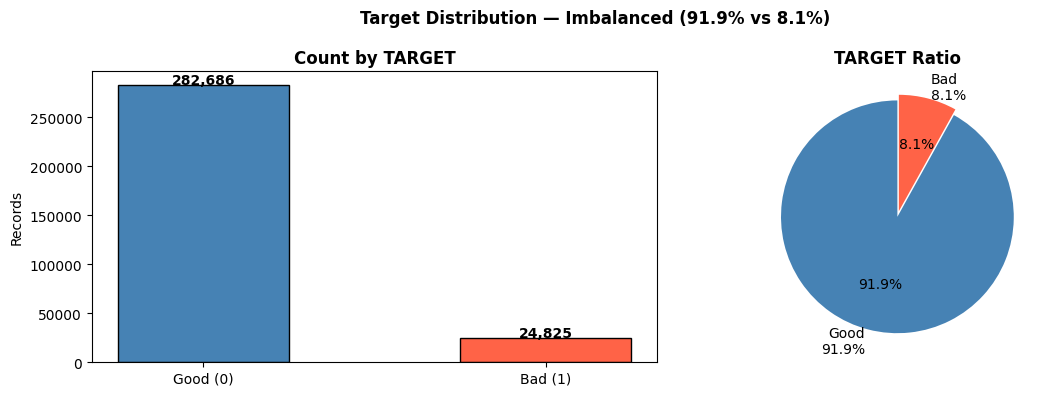

In [ ]:
target_count = app_train['TARGET'].value_counts()
target_pct   = app_train['TARGET'].value_counts(normalize=True) * 100

print(f"TARGET = 0 (Good) : {target_count[0]:,} ({target_pct[0]:.1f}%)")
print(f"TARGET = 1 (Bad)  : {target_count[1]:,} ({target_pct[1]:.1f}%)")
print(f"Imbalance ratio   : {target_pct[0]/target_pct[1]:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Good (0)', 'Bad (1)'], target_count.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Count by TARGET', fontweight='bold')
axes[0].set_ylabel('Records')
for i, v in enumerate(target_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_count.values,
            labels=[f'Good\n{target_pct[0]:.1f}%', f'Bad\n{target_pct[1]:.1f}%'],
            colors=['steelblue','tomato'], autopct='%1.1f%%',
            startangle=90, explode=(0,0.05))
axes[1].set_title('TARGET Ratio', fontweight='bold')
plt.suptitle('Target Distribution — Imbalanced (91.9% vs 8.1%)',
             fontweight='bold')
plt.tight_layout()
plt.show()


#### Mất cân bằng lớp

- `TARGET = 1` có **24.825 hồ sơ (8,1%)**, trong khi `TARGET = 0` có **282.686 hồ sơ (91,9%)**; tỷ lệ âm/dương xấp xỉ **11,39:1**.
- Accuracy không phù hợp làm chỉ tiêu chính: mô hình dự báo toàn bộ là khách hàng tốt vẫn có thể đạt gần 91,9% nhưng không phát hiện trường hợp rủi ro.
- Nghiên cứu ưu tiên **ROC-AUC, Average Precision, Precision, Recall, F1, KS, Decile và Lift**.
- Trọng số lớp được xem là siêu tham số. Cấu hình LightGBM tốt nhất sử dụng `scale_pos_weight = 3,3745`, gần căn bậc hai của tỷ lệ âm/dương, thay vì dùng toàn bộ tỷ lệ 11,39.

Việc tăng trọng số lớp giúp mô hình chú ý hơn đến lớp xấu nhưng đồng thời làm xác suất thô bị đẩy cao. Vì vậy, PD cuối cùng phải được hiệu chỉnh trên tập calibration độc lập.

> Threshold vận hành không được mặc định bằng 0,5. Threshold tối đa F1 trong notebook chỉ dùng để minh họa kỹ thuật, không thay thế tối ưu theo chi phí tín dụng.

---
#### 2.1.3. Kiểm tra và xử lý chất lượng dữ liệu

| Vấn đề | Cách xử lý trong notebook |
|---|---|
| Trùng lặp | Kiểm tra hàng trùng hoàn toàn và tính duy nhất của `SK_ID_CURR`. |
| Dữ liệu thiếu | Giữ `NaN` sau EDA; Logistic impute trong pipeline, LightGBM xử lý missing native. |
| `DAYS_EMPLOYED = 365243` | Tạo cờ bất thường rồi chuyển giá trị về `NaN`. |
| Ngoại lai | Mô tả bằng IQR/Z-score; không xóa cơ học. Capping của Logistic được học trong từng fold train. |
| Tổng hợp lịch sử | Dùng `sum(min_count=1)` ở các tổng tiền để không biến nhóm toàn missing thành giá trị 0. |
| Nhóm biến nhà ở/tài liệu | Loại theo phạm vi nghiên cứu đã xác định trước, không dựa vào test. |

Mọi phép biến đổi cần học từ phân phối dữ liệu được giới hạn trong train hoặc từng fold CV nhằm giảm data leakage.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1.3 — KIỂM TRA VÀ XỬ LÝ CHẤT LƯỢNG DỮ LIỆU
# ══════════════════════════════════════════════════════════════════════════════


print("=" * 65)
print("BƯỚC 1: KIỂM TRA VÀ XỬ LÝ DỮ LIỆU TRÙNG LẶP (DUPLICATES)")
print("=" * 65)

# ── Bước 1: Kiểm tra hàng trùng hoàn toàn ──────────────────────────────────────
# Duplicate rows = cùng toàn bộ giá trị → thường do lỗi ETL/data pipeline
n_dup_rows = app_train.duplicated().sum()
print(f"\nSố hàng trùng hoàn toàn    : {n_dup_rows:,}")
print(f"Tỷ lệ                       : {n_dup_rows/len(app_train)*100:.3f}%")

# ── Bước 2: Kiểm tra SK_ID_CURR trùng lặp ──────────────────────────────────────
# SK_ID_CURR là primary key của khách hàng — phải là duy nhất
n_dup_id = app_train['SK_ID_CURR'].duplicated().sum()
print(f"\nSố SK_ID_CURR trùng         : {n_dup_id:,}")
if n_dup_id == 0:
    print("  ✓ Không có ID khách hàng trùng lặp — dữ liệu sạch về mặt key")
else:
    print(f"  ⚠ Phát hiện {n_dup_id} ID trùng — cần điều tra nguyên nhân")
    # Xem các ID bị trùng
    dup_ids = app_train[app_train['SK_ID_CURR'].duplicated(keep=False)]
    print(dup_ids[['SK_ID_CURR','TARGET','AMT_CREDIT']].head(10))

# ── Bước 3: Loại bỏ hàng trùng nếu có ──────────────────────────────────────────
# Chỉ drop khi trùng hoàn toàn — không drop khi chỉ trùng ID mà khác thông tin
if n_dup_rows > 0:
    app_train_clean = app_train.drop_duplicates()
    print(f"\n→ Sau khi xóa duplicates: {app_train_clean.shape[0]:,} hàng (giảm {n_dup_rows:,})")
else:
    app_train_clean = app_train.copy()
    print("\n→ Không cần xóa duplicate — giữ nguyên dữ liệu")

print(f"\nShape sau bước 1: {app_train_clean.shape}")


BƯỚC 1: KIỂM TRA VÀ XỬ LÝ DỮ LIỆU TRÙNG LẶP (DUPLICATES)

Số hàng trùng hoàn toàn    : 0
Tỷ lệ                       : 0.000%

Số SK_ID_CURR trùng         : 0
  ✓ Không có ID khách hàng trùng lặp — dữ liệu sạch về mặt key

→ Không cần xóa duplicate — giữ nguyên dữ liệu

Shape sau bước 1: (307511, 122)


#### Tính toàn vẹn của bảng hồ sơ

- Không có hàng trùng hoàn toàn trong `application_train`.
- Không có `SK_ID_CURR` trùng; mỗi dòng bảng chính đại diện cho một hồ sơ hiện tại duy nhất.
- Việc một khách hàng có nhiều dòng trong `bureau`, `previous_application` hoặc `installments_payments` là quan hệ một–nhiều hợp lệ, không phải lỗi duplicate.

> Các bảng lịch sử phải được tổng hợp về cấp `SK_ID_CURR` trước khi nối vào tập mô hình để tránh nhân bản hồ sơ và làm sai biến mục tiêu.

BƯỚC 2: PHÂN TÍCH MISSING VALUES

Tổng số cột                         : 122
Cột không có missing               : 55
Cột cần impute trong model pipeline: 16
Cột cần xem xét vì thiếu > 40%     : 48
Cột được bảo vệ                    : 3

Các biến được giữ dù có tỷ lệ thiếu cao:
              pct_missing             strategy
EXT_SOURCE_1      56.3800  KEEP + MISSING FLAG
EXT_SOURCE_3      19.8300  KEEP + MISSING FLAG
EXT_SOURCE_2       0.2100  KEEP + MISSING FLAG


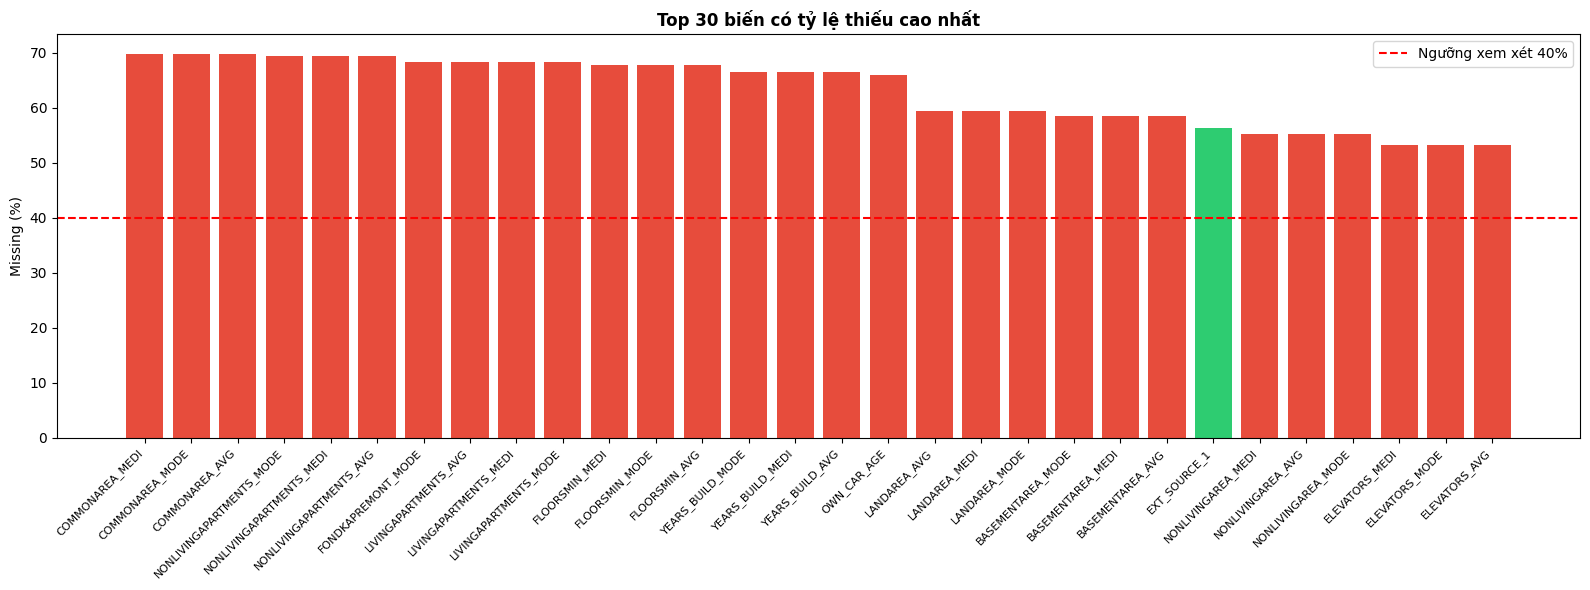


Các cột thiếu trên 40% cần đánh giá theo ý nghĩa nghiệp vụ, không tự động loại:
                              pct_missing
COMMONAREA_MEDI                   69.8700
COMMONAREA_MODE                   69.8700
COMMONAREA_AVG                    69.8700
NONLIVINGAPARTMENTS_MODE          69.4300
NONLIVINGAPARTMENTS_MEDI          69.4300
NONLIVINGAPARTMENTS_AVG           69.4300
FONDKAPREMONT_MODE                68.3900
LIVINGAPARTMENTS_AVG              68.3500
LIVINGAPARTMENTS_MEDI             68.3500
LIVINGAPARTMENTS_MODE             68.3500
FLOORSMIN_MEDI                    67.8500
FLOORSMIN_MODE                    67.8500
FLOORSMIN_AVG                     67.8500
YEARS_BUILD_MODE                  66.5000
YEARS_BUILD_MEDI                  66.5000
YEARS_BUILD_AVG                   66.5000
OWN_CAR_AGE                       65.9900
LANDAREA_AVG                      59.3800
LANDAREA_MEDI                     59.3800
LANDAREA_MODE                     59.3800
BASEMENTAREA_MODE                 58.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 2: PHÂN TÍCH MISSING VALUES — CHƯA IMPUTE, CHƯA DROP TỰ ĐỘNG
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("BƯỚC 2: PHÂN TÍCH MISSING VALUES")
print("=" * 70)

missing_count = app_train_clean.isnull().sum()
missing_pct = (missing_count / len(app_train_clean) * 100).round(2)

missing_summary = (
    pd.DataFrame({
        'n_missing': missing_count,
        'pct_missing': missing_pct
    })
    .query('n_missing > 0')
    .sort_values('pct_missing', ascending=False)
)

# Các điểm tín nhiệm ngoài có giá trị dự báo cao nên không loại chỉ vì tỷ lệ thiếu lớn.
protected_missing_features = {
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
}

def assign_missing_strategy(col, pct):
    if col in protected_missing_features:
        return 'KEEP + MISSING FLAG'
    if pct > 40:
        return 'REVIEW — DO NOT AUTO DROP'
    return 'TRAIN-ONLY IMPUTATION'

missing_summary['strategy'] = [
    assign_missing_strategy(col, pct)
    for col, pct in missing_summary['pct_missing'].items()
]

print(f"\nTổng số cột                         : {app_train_clean.shape[1]}")
print(f"Cột không có missing               : {(missing_count == 0).sum()}")
print(f"Cột cần impute trong model pipeline: {(missing_summary['strategy'] == 'TRAIN-ONLY IMPUTATION').sum()}")
print(f"Cột cần xem xét vì thiếu > 40%     : {(missing_summary['strategy'] == 'REVIEW — DO NOT AUTO DROP').sum()}")
print(f"Cột được bảo vệ                    : {(missing_summary['strategy'] == 'KEEP + MISSING FLAG').sum()}")

print("\nCác biến được giữ dù có tỷ lệ thiếu cao:")
protected_present = [
    c for c in protected_missing_features
    if c in missing_summary.index
]
if protected_present:
    print(missing_summary.loc[protected_present, ['pct_missing', 'strategy']].to_string())
else:
    print("  Không có biến protected nào bị thiếu trong dữ liệu hiện tại.")

# Trực quan top 30 cột có tỷ lệ thiếu cao nhất
top30 = missing_summary.head(30).copy()
strategy_color = {
    'KEEP + MISSING FLAG': '#2ecc71',
    'REVIEW — DO NOT AUTO DROP': '#e74c3c',
    'TRAIN-ONLY IMPUTATION': '#f39c12',
}
bar_colors = [strategy_color[s] for s in top30['strategy']]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(range(len(top30)), top30['pct_missing'], color=bar_colors, edgecolor='none')
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30.index, rotation=45, ha='right', fontsize=8)
ax.axhline(y=40, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng xem xét 40%')
ax.set_title('Top 30 biến có tỷ lệ thiếu cao nhất', fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCác cột thiếu trên 40% cần đánh giá theo ý nghĩa nghiệp vụ, không tự động loại:")
print(
    missing_summary[
        missing_summary['strategy'] == 'REVIEW — DO NOT AUTO DROP'
    ][['pct_missing']].to_string()
)


#### Dữ liệu thiếu

Trong 122 biến gốc:

- **55 biến** không có missing;
- **16 biến** cần impute trong pipeline Logistic Regression;
- **48 biến** thiếu trên 40% cần đánh giá theo nghiệp vụ;
- **3 biến `EXT_SOURCE`** được bảo vệ và giữ lại.

`EXT_SOURCE_1` thiếu **56,38%**, nhưng nhóm `EXT_SOURCE` có tín hiệu dự báo mạnh. Notebook vì vậy giữ biến, tạo missing flag và để mô hình xử lý thay vì gán missing bằng 0. Các biến tòa nhà có tỷ lệ thiếu cao nhất, nhiều cột thiếu khoảng 48%–70%, nên được loại có chủ đích để giảm độ phức tạp.

Sau khi tạo thêm các cờ và biến xử lý xác định, dữ liệu có **126 cột** và còn **9.207.839 ô thiếu**. Không có median, mode hoặc ngưỡng capping nào được học trên toàn bộ dữ liệu trước khi chia mẫu.

> Missing là một trạng thái dữ liệu cần được quản lý; tỷ lệ thiếu cao không tự động chứng minh một biến vô ích.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 2 (TIẾP): XỬ LÝ XÁC ĐỊNH, KHÔNG HỌC TỪ TOÀN BỘ DỮ LIỆU
# ══════════════════════════════════════════════════════════════════════════════

app_processed = app_train_clean.copy()

# 1) Tạo missing flag cho các EXT_SOURCE trước khi impute.
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    if col in app_processed.columns:
        app_processed[f'{col}_MISSING'] = app_processed[col].isna().astype('int8')

# 2) DAYS_EMPLOYED = 365243 là mã đặc biệt, không phải số ngày làm việc thật.
# Chỉ gắn cờ và chuyển thành NaN tại đây; median sẽ được fit trên TRAIN ở Mục 2.2.1.
if 'DAYS_EMPLOYED' in app_processed.columns:
    anomaly_mask = app_processed['DAYS_EMPLOYED'].eq(365243)
    app_processed['DAYS_EMPLOYED_ANOMALY'] = anomaly_mask.astype('int8')
    app_processed.loc[anomaly_mask, 'DAYS_EMPLOYED'] = np.nan
    print(f"DAYS_EMPLOYED: {anomaly_mask.sum():,} dòng được gắn cờ và chuyển thành NaN")

# 3) Không drop theo quy tắc cứng >40%, vì tỷ lệ thiếu không phản ánh trực tiếp
# giá trị dự báo. Nhóm building/document sẽ được loại có chủ đích ở Mục 2.2.1.
high_missing_candidates = missing_summary[
    missing_summary['pct_missing'] > 40
].index.tolist()

print("\nKết quả sau bước xử lý xác định:")
print(f"  Shape dữ liệu                    : {app_processed.shape}")
print(f"  Hàng trùng đã loại               : {len(app_train) - len(app_processed):,}")
print(f"  Tổng ô còn thiếu                 : {app_processed.isna().sum().sum():,}")
print(f"  Biến thiếu >40% cần review       : {len(high_missing_candidates)}")
print("  Imputation toàn bộ dữ liệu       : KHÔNG thực hiện")
print("  Capping toàn bộ dữ liệu          : KHÔNG thực hiện")


DAYS_EMPLOYED: 55,374 dòng được gắn cờ và chuyển thành NaN

Kết quả sau bước xử lý xác định:
  Shape dữ liệu                    : (307511, 126)
  Hàng trùng đã loại               : 0
  Tổng ô còn thiếu                 : 9,207,839
  Biến thiếu >40% cần review       : 49
  Imputation toàn bộ dữ liệu       : KHÔNG thực hiện
  Capping toàn bộ dữ liệu          : KHÔNG thực hiện


#### Xử lý mã bất thường `DAYS_EMPLOYED`

- Có **55.374 hồ sơ (18,01%)** mang giá trị `365243`.
- Nếu diễn giải trực tiếp theo số ngày, giá trị này tương đương hơn 1.000 năm làm việc và không có ý nghĩa thực tế.
- Notebook chuyển giá trị bất thường về `NaN` và giữ cờ `DAYS_EMPLOYED_ANOMALY`.

Cách xử lý này loại bỏ độ lớn phi thực tế nhưng vẫn bảo toàn tín hiệu “thông tin việc làm không áp dụng hoặc không xác định”.

BƯỚC 3: PHÁT HIỆN OUTLIER — PHÂN BIỆT GIÁ TRỊ THẬT VÀ LỖI KỸ THUẬT

Báo cáo outlier:
         Feature    IQR_Lower    IQR_Upper  N_IQR  Pct_IQR  N_Zscore  Pct_Zscore
 AMT_GOODS_PRICE -423000.0000 1341000.0000  14728   4.7900      4173      1.3600
AMT_INCOME_TOTAL  -22500.0000  337500.0000  14035   4.5600       454      0.1500
     AMT_ANNUITY  -10584.0000   61704.0000   7504   2.4400      2959      0.9600
      AMT_CREDIT -537975.0000 1616625.0000   6562   2.1300      3255      1.0600
    EXT_SOURCE_1      -0.1800       1.1900      0   0.0000         0      0.0000
    EXT_SOURCE_2      -0.0100       1.0700      0   0.0000         0      0.0000
    EXT_SOURCE_3      -0.0800       1.1200      0   0.0000         0      0.0000


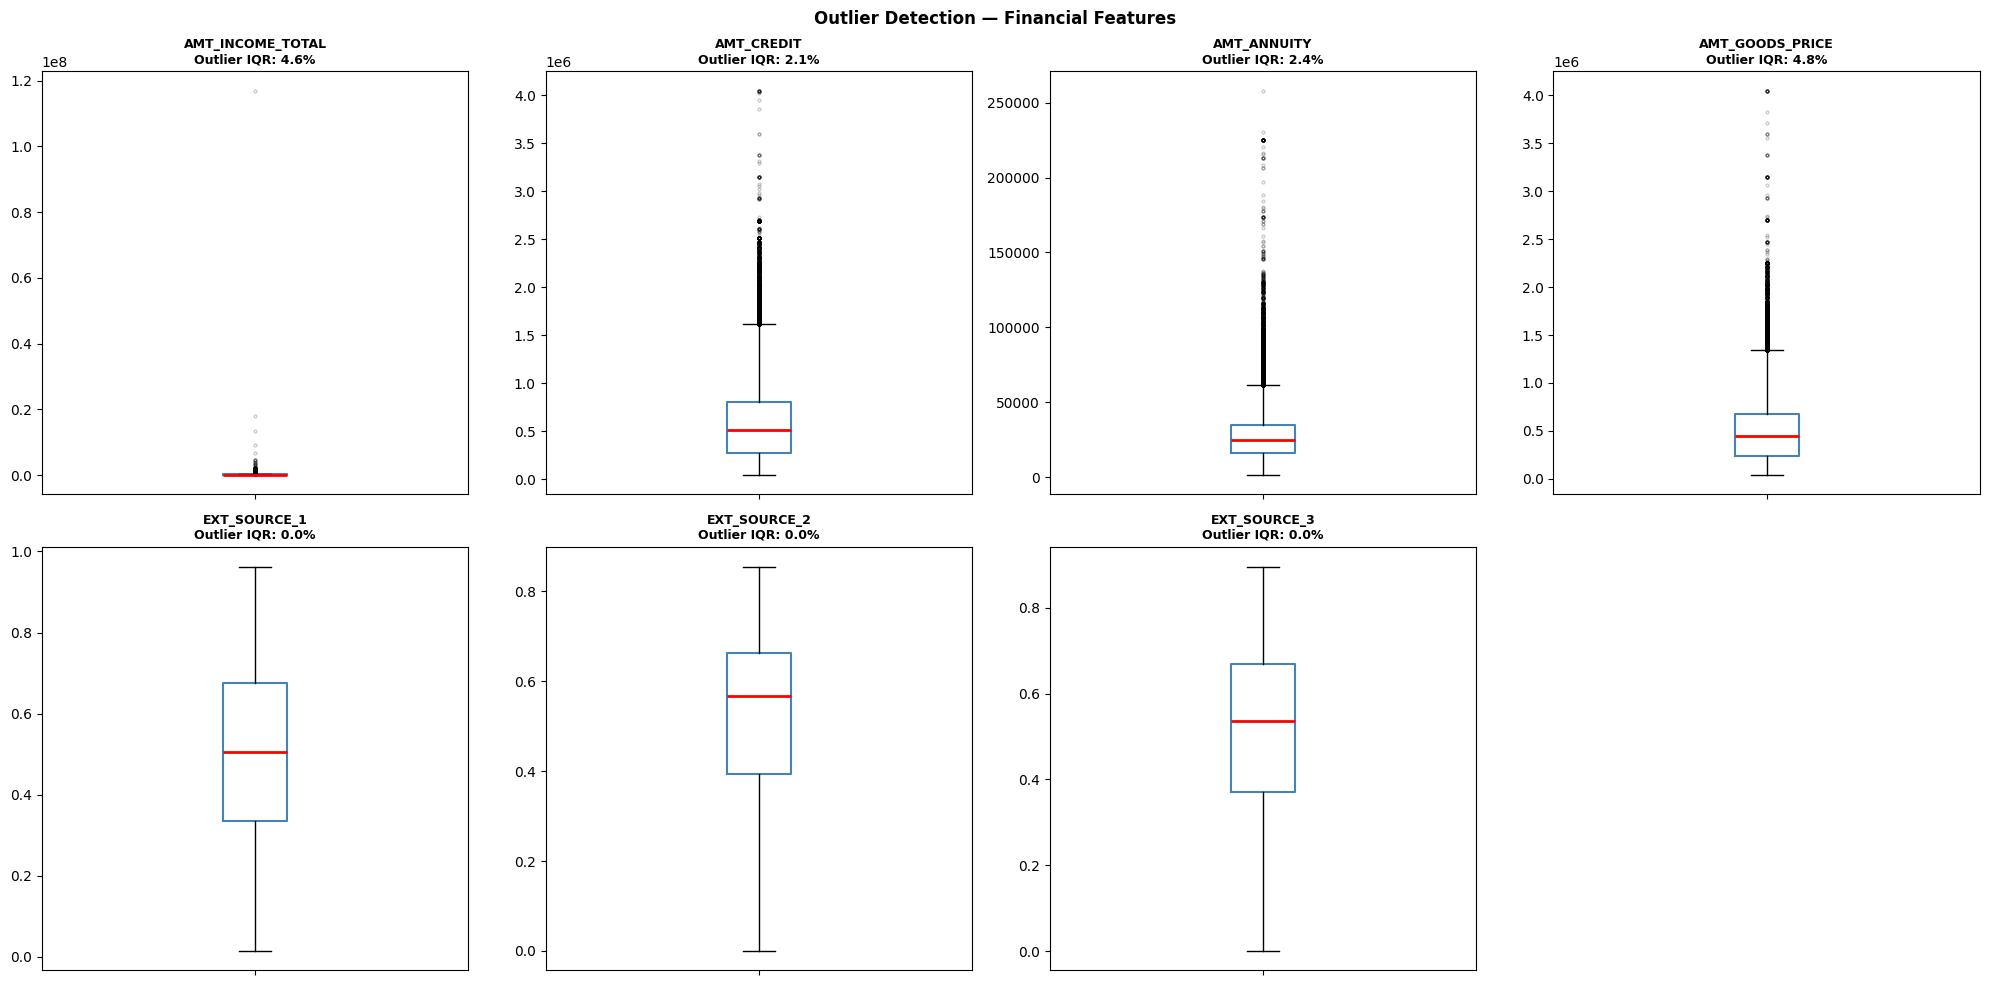

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BƯỚC 3: BÁO CÁO OUTLIER — CHƯA CAPPING TRÊN TOÀN BỘ DỮ LIỆU
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("BƯỚC 3: PHÁT HIỆN OUTLIER — PHÂN BIỆT GIÁ TRỊ THẬT VÀ LỖI KỸ THUẬT")
print("=" * 70)

def outlier_report(df, cols):
    """Báo cáo outlier bằng IQR và Z-score, không tự động xóa/cap."""
    rows = []

    for col in cols:
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if s.empty:
            continue

        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        n_iqr = ((s < lower) | (s > upper)).sum()
        z_scores = (s - s.mean()) / (s.std() + 1e-9)
        n_zscore = z_scores.abs().gt(3).sum()

        rows.append({
            'Feature': col,
            'IQR_Lower': lower,
            'IQR_Upper': upper,
            'N_IQR': int(n_iqr),
            'Pct_IQR': n_iqr / len(df) * 100,
            'N_Zscore': int(n_zscore),
            'Pct_Zscore': n_zscore / len(df) * 100,
        })

    return (
        pd.DataFrame(rows)
        .sort_values('Pct_IQR', ascending=False)
        .reset_index(drop=True)
    )

financial_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]
financial_cols_exist = [c for c in financial_cols if c in app_processed.columns]

outlier_df = outlier_report(app_processed, financial_cols_exist)
print("\nBáo cáo outlier:")
print(
    outlier_df[
        ['Feature', 'IQR_Lower', 'IQR_Upper', 'N_IQR', 'Pct_IQR', 'N_Zscore', 'Pct_Zscore']
    ].round(2).to_string(index=False)
)

n_cols = len(financial_cols_exist)
n_rows = max(1, (n_cols + 3) // 4)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(financial_cols_exist):
    data = pd.to_numeric(app_processed[col], errors='coerce').dropna()
    axes[i].boxplot(
        data,
        boxprops=dict(color='steelblue', linewidth=1.5),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', color='tomato', alpha=0.2, markersize=2)
    )

    pct_iqr = outlier_df.loc[
        outlier_df['Feature'].eq(col), 'Pct_IQR'
    ].iloc[0]

    axes[i].set_title(
        f'{col}\nOutlier IQR: {pct_iqr:.1f}%',
        fontsize=9,
        fontweight='bold'
    )
    axes[i].tick_params(axis='x', labelbottom=False)

for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — Financial Features', fontweight='bold')
plt.tight_layout()
plt.show()


#### Phân tích ngoại lai tài chính

Theo quy tắc IQR, tỷ lệ quan sát ngoài khoảng là:

- `AMT_GOODS_PRICE`: **4,79%**;
- `AMT_INCOME_TOTAL`: **4,56%**;
- `AMT_ANNUITY`: **2,44%**;
- `AMT_CREDIT`: **2,13%**.

Các biến tiền tệ có phân phối lệch phải; giá trị lớn có thể là hồ sơ hợp lệ thay vì lỗi kỹ thuật. Ba biến `EXT_SOURCE` không có outlier theo IQR vì nằm trong miền điểm số giới hạn. LightGBM giữ nguyên các giá trị này, còn Logistic Regression giảm độ nhạy với cực trị bằng bước capping được học bên trong fold train.

> Không xóa đồng loạt các khoản vay hoặc thu nhập lớn vì có thể làm mất nhóm khách hàng quan trọng và gây sai lệch phân phối danh mục.

##### Phân tích mối liên hệ đơn biến với `TARGET`

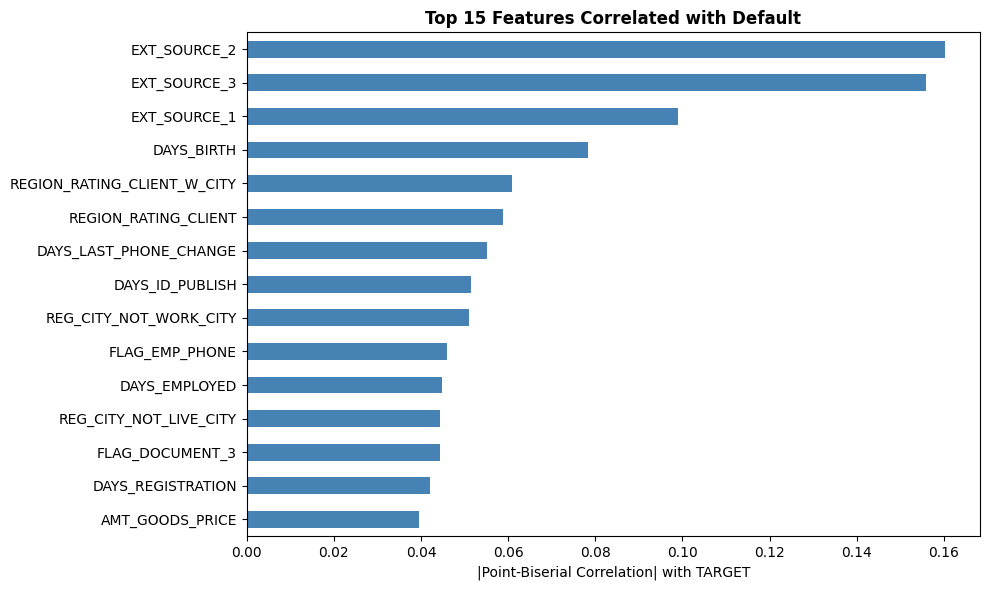

EXT_SOURCE_2                  0.1603
EXT_SOURCE_3                  0.1559
EXT_SOURCE_1                  0.0989
DAYS_BIRTH                    0.0782
REGION_RATING_CLIENT_W_CITY   0.0609
REGION_RATING_CLIENT          0.0589
DAYS_LAST_PHONE_CHANGE        0.0552
DAYS_ID_PUBLISH               0.0515
REG_CITY_NOT_WORK_CITY        0.0510
FLAG_EMP_PHONE                0.0460
DAYS_EMPLOYED                 0.0449
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_DOCUMENT_3               0.0443
DAYS_REGISTRATION             0.0420
AMT_GOODS_PRICE               0.0396


In [ ]:
num_cols = app_train.select_dtypes('number').columns.drop(['TARGET','SK_ID_CURR'])
pbs_corr = {}
for col in num_cols:
    try:
        corr_val, _ = pointbiserialr(
            app_train[col].fillna(app_train[col].median()), app_train['TARGET'])
        pbs_corr[col] = abs(corr_val)
    except Exception:
        pass

corr_series = pd.Series(pbs_corr).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
corr_series.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('|Point-Biserial Correlation| with TARGET')
ax.set_title('Top 15 Features Correlated with Default', fontweight='bold')
plt.tight_layout()
plt.show()
print(corr_series.to_string())


#### Nhận xét về tương quan đơn biến

- Ba biến có tương quan tuyệt đối cao nhất với `TARGET` là `EXT_SOURCE_2` **0,1603**, `EXT_SOURCE_3` **0,1559** và `EXT_SOURCE_1` **0,0989**.
- `DAYS_BIRTH` đạt **0,0782**; các biến xếp hạng khu vực, thay đổi điện thoại và giấy tờ có mức liên hệ thấp hơn.
- Tương quan lớn nhất chỉ khoảng 0,16, cho thấy không biến đơn lẻ nào đủ để tách hoàn toàn khách hàng tốt và khách hàng rủi ro.
- Tương quan chỉ phản ánh quan hệ đơn biến, không chứng minh nhân quả và không thể hiện đầy đủ tương tác phi tuyến.

> Tín hiệu phân tán trên nhiều biến là cơ sở để sử dụng mô hình đa biến và so sánh mô hình tuyến tính với mô hình cây.

#### 2.1.4. Xây dựng đặc trưng

Đặc trưng được xây dựng theo ba nguyên tắc:

1. Có ý nghĩa đối với rủi ro tín dụng và khả năng trả nợ.
2. Được tổng hợp đúng cấp quan sát của mô hình là `SK_ID_CURR`.
3. Không sử dụng `TARGET` hoặc thông tin tương lai của hồ sơ đang dự báo.

In [ ]:
# Sử dụng dữ liệu đã xử lý xác định ở phần Data Quality.
# Missing values vẫn được giữ để impute sau khi chia các tập dữ liệu.
df = app_processed.copy() if 'app_processed' in globals() else app_train.copy()


def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


# ── Bước 1: Xử lý bất thường DAYS_EMPLOYED ────────────────────────────────
if 'DAYS_EMPLOYED' in df.columns and 'DAYS_EMPLOYED_ANOMALY' not in df.columns:
    anomaly_mask = df['DAYS_EMPLOYED'].eq(365243)
    df['DAYS_EMPLOYED_ANOMALY'] = anomaly_mask.astype('int8')
    df.loc[anomaly_mask, 'DAYS_EMPLOYED'] = np.nan

# ── Bước 2: Biến tuổi và thâm niên ────────────────────────────────────────
if 'DAYS_BIRTH' in df.columns:
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25

if 'DAYS_EMPLOYED' in df.columns:
    df['EMPLOY_YEARS'] = -df['DAYS_EMPLOYED'] / 365.25

if {'EMPLOY_YEARS', 'AGE_YEARS'}.issubset(df.columns):
    df['EMPLOY_AGE_RATIO'] = safe_divide(df['EMPLOY_YEARS'], df['AGE_YEARS'])

# ── Bước 3: Tỷ lệ tài chính và cấu trúc khoản vay ─────────────────────────
if {'AMT_CREDIT', 'AMT_INCOME_TOTAL'}.issubset(df.columns):
    df['CREDIT_INCOME_RATIO'] = safe_divide(df['AMT_CREDIT'], df['AMT_INCOME_TOTAL'])

if {'AMT_ANNUITY', 'AMT_INCOME_TOTAL'}.issubset(df.columns):
    df['ANNUITY_INCOME_RATIO'] = safe_divide(df['AMT_ANNUITY'], df['AMT_INCOME_TOTAL'])

if {'AMT_ANNUITY', 'AMT_CREDIT'}.issubset(df.columns):
    df['ANNUITY_CREDIT_RATIO'] = safe_divide(df['AMT_ANNUITY'], df['AMT_CREDIT'])
    df['CREDIT_TERM_MONTHS_APPROX'] = safe_divide(df['AMT_CREDIT'], df['AMT_ANNUITY'])

if {'AMT_CREDIT', 'AMT_GOODS_PRICE'}.issubset(df.columns):
    df['CREDIT_GOODS_RATIO'] = safe_divide(df['AMT_CREDIT'], df['AMT_GOODS_PRICE'])
    df['CREDIT_GOODS_DIFF'] = df['AMT_CREDIT'] - df['AMT_GOODS_PRICE']

if {'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS'}.issubset(df.columns):
    df['INCOME_PER_PERSON'] = safe_divide(df['AMT_INCOME_TOTAL'], df['CNT_FAM_MEMBERS'])

if {'CNT_CHILDREN', 'CNT_FAM_MEMBERS'}.issubset(df.columns):
    df['CHILDREN_FAMILY_RATIO'] = safe_divide(df['CNT_CHILDREN'], df['CNT_FAM_MEMBERS'])

# ── Bước 4: Tổng hợp EXT_SOURCE và cờ thiếu ───────────────────────────────
ext_cols = [
    c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    if c in df.columns
]

for col in ext_cols:
    df[f'{col}_MISSING'] = df[col].isna().astype('int8')

if ext_cols:
    df['EXT_SOURCE_MISSING_COUNT'] = df[ext_cols].isna().sum(axis=1).astype('int8')
    df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1, skipna=True)
    df['EXT_SOURCE_MIN'] = df[ext_cols].min(axis=1, skipna=True)
    df['EXT_SOURCE_MAX'] = df[ext_cols].max(axis=1, skipna=True)
    df['EXT_SOURCE_STD'] = df[ext_cols].std(axis=1, skipna=True)
    # Product chỉ có ý nghĩa khi đủ cả ba nguồn.
    df['EXT_SOURCE_PROD'] = df[ext_cols].prod(axis=1, min_count=len(ext_cols))

# Loại giá trị vô hạn; NaN được xử lý đúng bên trong pipeline mô hình.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print('✓ Application-level feature engineering hoàn tất; chưa impute dữ liệu.')


✓ Application-level feature engineering hoàn tất; chưa impute dữ liệu.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TỔNG HỢP LỊCH SỬ TÍN DỤNG VỀ CẤP KHÁCH HÀNG
# ══════════════════════════════════════════════════════════════════════════════


def merge_history_aggregate(base, aggregate, count_column, flag_column):
    """Merge feature lịch sử và phân biệt 'không có lịch sử' với missing thật."""
    merged = base.merge(aggregate, on='SK_ID_CURR', how='left', validate='one_to_one')
    feature_columns = [c for c in aggregate.columns if c != 'SK_ID_CURR']
    no_history = merged[count_column].isna()
    merged[flag_column] = (~no_history).astype('int8')
    # Chỉ điền 0 khi khách hàng hoàn toàn không có bản ghi ở nguồn tương ứng.
    merged.loc[no_history, feature_columns] = 0
    return merged, no_history


# ── 1. Bureau: quy mô, trạng thái hiện tại và dư nợ ────────────────────────
bureau_work = bureau.copy()
bureau_work['IS_ACTIVE'] = bureau_work['CREDIT_ACTIVE'].eq('Active').astype('int8')
bureau_work['IS_CLOSED'] = bureau_work['CREDIT_ACTIVE'].eq('Closed').astype('int8')
bureau_work['HAS_CURRENT_OVERDUE'] = (
    pd.to_numeric(bureau_work['CREDIT_DAY_OVERDUE'], errors='coerce') > 0
).astype('int8')

bureau_agg = bureau_work.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'nunique'),
    BUREAU_ACTIVE_COUNT=('IS_ACTIVE', 'sum'),
    BUREAU_CLOSED_COUNT=('IS_CLOSED', 'sum'),
    BUREAU_CREDIT_TYPE_NUNIQUE=('CREDIT_TYPE', 'nunique'),
    BUREAU_DAYS_CREDIT_RECENT=('DAYS_CREDIT', 'max'),
    BUREAU_DAYS_CREDIT_OLDEST=('DAYS_CREDIT', 'min'),
    BUREAU_CURRENT_DPD_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_CURRENT_DPD_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_CURRENT_OVERDUE_COUNT=('HAS_CURRENT_OVERDUE', 'sum'),
    BUREAU_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', lambda x: x.sum(min_count=1)),
    BUREAU_CREDIT_SUM=('AMT_CREDIT_SUM', lambda x: x.sum(min_count=1)),
    BUREAU_OVERDUE_AMOUNT_SUM=('AMT_CREDIT_SUM_OVERDUE', lambda x: x.sum(min_count=1)),
    BUREAU_MAX_OVERDUE_AMOUNT=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_PROLONG_COUNT=('CNT_CREDIT_PROLONG', lambda x: x.sum(min_count=1)),
).reset_index()

bureau_agg['BUREAU_ACTIVE_RATE'] = safe_divide(
    bureau_agg['BUREAU_ACTIVE_COUNT'], bureau_agg['BUREAU_LOAN_COUNT']
)
bureau_agg['BUREAU_CURRENT_OVERDUE_RATE'] = safe_divide(
    bureau_agg['BUREAU_CURRENT_OVERDUE_COUNT'], bureau_agg['BUREAU_LOAN_COUNT']
)
bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = safe_divide(
    bureau_agg['BUREAU_DEBT_SUM'], bureau_agg['BUREAU_CREDIT_SUM']
)
bureau_agg['BUREAU_OVERDUE_CREDIT_RATIO'] = safe_divide(
    bureau_agg['BUREAU_OVERDUE_AMOUNT_SUM'], bureau_agg['BUREAU_CREDIT_SUM']
)

df, no_bureau_history = merge_history_aggregate(
    df, bureau_agg, 'BUREAU_LOAN_COUNT', 'HAS_BUREAU_HISTORY'
)

# ── 2. Bureau balance: hành vi DPD lịch sử trước hồ sơ hiện tại ────────────
bb_feature = bureau_bal[['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']].copy()
bb_feature['STATUS'] = bb_feature['STATUS'].astype(str)
bb_feature['STATUS_NUM'] = pd.to_numeric(
    bb_feature['STATUS'], errors='coerce'
).astype('float32')
bb_feature['IS_KNOWN'] = bb_feature['STATUS_NUM'].between(0, 5).astype('int8')
bb_feature['IS_DPD'] = bb_feature['STATUS_NUM'].ge(1).fillna(False).astype('int8')
bb_feature['IS_PAR30'] = bb_feature['STATUS_NUM'].ge(2).fillna(False).astype('int8')
bb_feature['IS_DPD90_PROXY'] = bb_feature['STATUS_NUM'].ge(4).fillna(False).astype('int8')
bb_feature['RECENT6_KNOWN'] = (
    bb_feature['MONTHS_BALANCE'].between(-5, 0) & bb_feature['IS_KNOWN'].eq(1)
).astype('int8')
bb_feature['RECENT6_DPD'] = (
    bb_feature['MONTHS_BALANCE'].between(-5, 0) & bb_feature['STATUS_NUM'].ge(1)
).astype('int8')

bb_loan = bb_feature.groupby('SK_ID_BUREAU').agg(
    BB_OBSERVED_MONTH_COUNT=('MONTHS_BALANCE', 'nunique'),
    BB_KNOWN_MONTH_COUNT=('IS_KNOWN', 'sum'),
    BB_MAX_STATUS=('STATUS_NUM', 'max'),
    BB_DPD_MONTH_COUNT=('IS_DPD', 'sum'),
    BB_PAR30_MONTH_COUNT=('IS_PAR30', 'sum'),
    BB_DPD90_MONTH_COUNT=('IS_DPD90_PROXY', 'sum'),
    BB_RECENT6_KNOWN_COUNT=('RECENT6_KNOWN', 'sum'),
    BB_RECENT6_DPD_COUNT=('RECENT6_DPD', 'sum'),
).reset_index()

bb_loan['BB_DPD_MONTH_RATE'] = safe_divide(
    bb_loan['BB_DPD_MONTH_COUNT'], bb_loan['BB_KNOWN_MONTH_COUNT']
)
bb_loan['BB_PAR30_MONTH_RATE'] = safe_divide(
    bb_loan['BB_PAR30_MONTH_COUNT'], bb_loan['BB_KNOWN_MONTH_COUNT']
)
bb_loan['BB_RECENT6_DPD_RATE'] = safe_divide(
    bb_loan['BB_RECENT6_DPD_COUNT'], bb_loan['BB_RECENT6_KNOWN_COUNT']
)

bb_loan = bb_loan.merge(
    bureau[['SK_ID_BUREAU', 'SK_ID_CURR']].drop_duplicates('SK_ID_BUREAU'),
    on='SK_ID_BUREAU', how='inner', validate='one_to_one'
)

bb_customer = bb_loan.groupby('SK_ID_CURR').agg(
    BB_LOAN_COUNT=('SK_ID_BUREAU', 'nunique'),
    BB_LOAN_WITH_KNOWN_STATUS_COUNT=('BB_KNOWN_MONTH_COUNT', lambda x: (x > 0).sum()),
    BB_KNOWN_MONTH_COUNT_SUM=('BB_KNOWN_MONTH_COUNT', 'sum'),
    BB_DPD_MONTH_COUNT_SUM=('BB_DPD_MONTH_COUNT', 'sum'),
    BB_PAR30_MONTH_COUNT_SUM=('BB_PAR30_MONTH_COUNT', 'sum'),
    BB_MAX_STATUS_MAX=('BB_MAX_STATUS', 'max'),
    BB_EVER_DPD_LOAN_COUNT=('BB_MAX_STATUS', lambda x: (x >= 1).sum()),
    BB_EVER_PAR30_LOAN_COUNT=('BB_MAX_STATUS', lambda x: (x >= 2).sum()),
    BB_EVER_DPD90_LOAN_COUNT=('BB_MAX_STATUS', lambda x: (x >= 4).sum()),
    BB_RECENT6_KNOWN_COUNT_SUM=('BB_RECENT6_KNOWN_COUNT', 'sum'),
    BB_RECENT6_DPD_COUNT_SUM=('BB_RECENT6_DPD_COUNT', 'sum'),
).reset_index()

bb_customer['BB_DPD_MONTH_RATE'] = safe_divide(
    bb_customer['BB_DPD_MONTH_COUNT_SUM'], bb_customer['BB_KNOWN_MONTH_COUNT_SUM']
)
bb_customer['BB_PAR30_MONTH_RATE'] = safe_divide(
    bb_customer['BB_PAR30_MONTH_COUNT_SUM'], bb_customer['BB_KNOWN_MONTH_COUNT_SUM']
)
bb_customer['BB_EVER_DPD_LOAN_RATE'] = safe_divide(
    bb_customer['BB_EVER_DPD_LOAN_COUNT'], bb_customer['BB_LOAN_WITH_KNOWN_STATUS_COUNT']
)
bb_customer['BB_EVER_PAR30_LOAN_RATE'] = safe_divide(
    bb_customer['BB_EVER_PAR30_LOAN_COUNT'], bb_customer['BB_LOAN_WITH_KNOWN_STATUS_COUNT']
)
bb_customer['BB_EVER_DPD90_LOAN_RATE'] = safe_divide(
    bb_customer['BB_EVER_DPD90_LOAN_COUNT'], bb_customer['BB_LOAN_WITH_KNOWN_STATUS_COUNT']
)
bb_customer['BB_RECENT6_DPD_RATE'] = safe_divide(
    bb_customer['BB_RECENT6_DPD_COUNT_SUM'], bb_customer['BB_RECENT6_KNOWN_COUNT_SUM']
)

df, no_bb_history = merge_history_aggregate(
    df, bb_customer, 'BB_LOAN_COUNT', 'HAS_BUREAU_BALANCE_HISTORY'
)

# ── 3. Previous applications ───────────────────────────────────────────────
prev_work = prev_app.copy()
prev_date_cols = [
    'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
    'DAYS_LAST_DUE', 'DAYS_TERMINATION'
]
for col in prev_date_cols:
    if col in prev_work.columns:
        prev_work.loc[prev_work[col].eq(365243), col] = np.nan

prev_work['PREV_CREDIT_APPLICATION_RATIO'] = safe_divide(
    prev_work['AMT_CREDIT'], prev_work['AMT_APPLICATION']
)
prev_work['PREV_ANNUITY_CREDIT_RATIO'] = safe_divide(
    prev_work['AMT_ANNUITY'], prev_work['AMT_CREDIT']
)

prev_agg = prev_work.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'nunique'),
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_DAYS_DECISION_RECENT=('DAYS_DECISION', 'max'),
    PREV_DAYS_DECISION_OLDEST=('DAYS_DECISION', 'min'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_CREDIT_MAX=('AMT_CREDIT', 'max'),
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_CREDIT_APPLICATION_RATIO_MEAN=('PREV_CREDIT_APPLICATION_RATIO', 'mean'),
    PREV_ANNUITY_CREDIT_RATIO_MEAN=('PREV_ANNUITY_CREDIT_RATIO', 'mean'),
).reset_index()

prev_agg['PREV_APPROVAL_RATE'] = safe_divide(
    prev_agg['PREV_APPROVED_COUNT'], prev_agg['PREV_APP_COUNT']
)
prev_agg['PREV_REFUSAL_RATE'] = safe_divide(
    prev_agg['PREV_REFUSED_COUNT'], prev_agg['PREV_APP_COUNT']
)

df, no_prev_history = merge_history_aggregate(
    df, prev_agg, 'PREV_APP_COUNT', 'HAS_PREV_HISTORY'
)

# ── 4. Installments: tổng hợp đúng ở cấp kỳ thanh toán ─────────────────────
# Một kỳ trả góp có thể có nhiều dòng do thanh toán từng phần. Phải gom về
# một kỳ trước khi tính số kỳ, số ngày trễ và tỷ lệ thanh toán.
inst_work = installments.copy()
installment_key = [
    'SK_ID_CURR', 'SK_ID_PREV', 'NUM_INSTALMENT_VERSION',
    'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT'
]
raw_duplicate_installment_rows = int(inst_work.duplicated(installment_key, keep=False).sum())

inst_level = inst_work.groupby(
    installment_key, as_index=False, dropna=False
).agg(
    DAYS_ENTRY_PAYMENT=('DAYS_ENTRY_PAYMENT', 'max'),
    AMT_INSTALMENT=('AMT_INSTALMENT', 'max'),
    AMT_PAYMENT=('AMT_PAYMENT', lambda x: x.sum(min_count=1)),
)

inst_level['DAYS_LATE'] = (
    inst_level['DAYS_ENTRY_PAYMENT'] - inst_level['DAYS_INSTALMENT']
).clip(lower=0)
inst_level['PAYMENT_RATIO'] = safe_divide(
    inst_level['AMT_PAYMENT'], inst_level['AMT_INSTALMENT']
)
inst_level['IS_LATE'] = np.where(
    inst_level['DAYS_ENTRY_PAYMENT'].notna(), inst_level['DAYS_LATE'].gt(0), np.nan
)
inst_level['IS_DPD30'] = np.where(
    inst_level['DAYS_ENTRY_PAYMENT'].notna(), inst_level['DAYS_LATE'].ge(30), np.nan
)
inst_level['IS_UNDERPAID'] = np.where(
    inst_level['PAYMENT_RATIO'].notna(), inst_level['PAYMENT_RATIO'].lt(0.99), np.nan
)
inst_level['IS_OVERPAID'] = np.where(
    inst_level['PAYMENT_RATIO'].notna(), inst_level['PAYMENT_RATIO'].gt(1.01), np.nan
)

instal_agg = inst_level.groupby('SK_ID_CURR').agg(
    INSTAL_SCHEDULE_COUNT=('NUM_INSTALMENT_NUMBER', 'size'),
    INSTAL_LOAN_COUNT=('SK_ID_PREV', 'nunique'),
    INSTAL_DAYS_LATE_MEAN=('DAYS_LATE', 'mean'),
    INSTAL_DAYS_LATE_MAX=('DAYS_LATE', 'max'),
    INSTAL_LATE_RATE=('IS_LATE', 'mean'),
    INSTAL_DPD30_RATE=('IS_DPD30', 'mean'),
    INSTAL_UNDERPAY_RATE=('IS_UNDERPAID', 'mean'),
    INSTAL_OVERPAY_RATE=('IS_OVERPAID', 'mean'),
    INSTAL_PAYMENT_RATIO_MEAN=('PAYMENT_RATIO', 'mean'),
    INSTAL_AMT_PAYMENT_SUM=('AMT_PAYMENT', lambda x: x.sum(min_count=1)),
    INSTAL_AMT_INSTAL_SUM=('AMT_INSTALMENT', lambda x: x.sum(min_count=1)),
).reset_index()
instal_agg['INSTAL_PAYMENT_RATIO_TOTAL'] = safe_divide(
    instal_agg['INSTAL_AMT_PAYMENT_SUM'], instal_agg['INSTAL_AMT_INSTAL_SUM']
)

# Hành vi gần đây: 12 kỳ đến hạn gần ngày nộp hồ sơ nhất của mỗi khách hàng.
inst_recent12 = (
    inst_level.sort_values(['SK_ID_CURR', 'DAYS_INSTALMENT'], ascending=[True, False])
    .groupby('SK_ID_CURR', group_keys=False)
    .head(12)
)
inst_recent_agg = inst_recent12.groupby('SK_ID_CURR').agg(
    INSTAL_RECENT12_LATE_RATE=('IS_LATE', 'mean'),
    INSTAL_RECENT12_DPD30_RATE=('IS_DPD30', 'mean'),
    INSTAL_RECENT12_UNDERPAY_RATE=('IS_UNDERPAID', 'mean'),
    INSTAL_RECENT12_DAYS_LATE_MAX=('DAYS_LATE', 'max'),
).reset_index()
instal_agg = instal_agg.merge(inst_recent_agg, on='SK_ID_CURR', how='left', validate='one_to_one')

df, no_instal_history = merge_history_aggregate(
    df, instal_agg, 'INSTAL_SCHEDULE_COUNT', 'HAS_INSTAL_HISTORY'
)

# ── 5. POS/CASH và credit card: tùy chọn theo RAM ──────────────────────────
no_pos_history = pd.Series(False, index=df.index)
no_cc_history = pd.Series(False, index=df.index)

if USE_EXTENDED_BEHAVIOR_TABLES and POS_CASH_PATH.exists():
    pos_usecols = [
        'SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT_FUTURE',
        'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF'
    ]
    pos = pd.read_csv(POS_CASH_PATH, usecols=pos_usecols)
    pos['POS_IS_DPD'] = pos['SK_DPD'].gt(0).astype('int8')
    pos['POS_IS_DPD30'] = pos['SK_DPD'].ge(30).astype('int8')
    pos['POS_IS_DPD90'] = pos['SK_DPD'].ge(90).astype('int8')
    pos['POS_RECENT6_KNOWN'] = pos['MONTHS_BALANCE'].between(-5, 0).astype('int8')
    pos['POS_RECENT6_DPD'] = (
        pos['MONTHS_BALANCE'].between(-5, 0) & pos['SK_DPD'].gt(0)
    ).astype('int8')
    pos['POS_IS_COMPLETED'] = pos['NAME_CONTRACT_STATUS'].eq('Completed').astype('int8')

    pos_agg = pos.groupby('SK_ID_CURR').agg(
        POS_MONTH_COUNT=('MONTHS_BALANCE', 'size'),
        POS_LOAN_COUNT=('SK_ID_PREV', 'nunique'),
        POS_DPD_MEAN=('SK_DPD', 'mean'),
        POS_DPD_MAX=('SK_DPD', 'max'),
        POS_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
        POS_DPD_RATE=('POS_IS_DPD', 'mean'),
        POS_DPD30_RATE=('POS_IS_DPD30', 'mean'),
        POS_DPD90_RATE=('POS_IS_DPD90', 'mean'),
        POS_RECENT6_KNOWN_COUNT=('POS_RECENT6_KNOWN', 'sum'),
        POS_RECENT6_DPD_COUNT=('POS_RECENT6_DPD', 'sum'),
        POS_INSTALMENT_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE', 'mean'),
        POS_COMPLETED_RATE=('POS_IS_COMPLETED', 'mean'),
    ).reset_index()
    pos_agg['POS_RECENT6_DPD_RATE'] = safe_divide(
        pos_agg['POS_RECENT6_DPD_COUNT'], pos_agg['POS_RECENT6_KNOWN_COUNT']
    )
    df, no_pos_history = merge_history_aggregate(
        df, pos_agg, 'POS_MONTH_COUNT', 'HAS_POS_HISTORY'
    )
    del pos, pos_agg
    gc.collect()
else:
    df['HAS_POS_HISTORY'] = 0

if USE_EXTENDED_BEHAVIOR_TABLES and CREDIT_CARD_PATH.exists():
    cc_usecols = [
        'SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
        'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
        'AMT_DRAWINGS_CURRENT', 'AMT_INST_MIN_REGULARITY',
        'AMT_PAYMENT_TOTAL_CURRENT', 'SK_DPD', 'SK_DPD_DEF'
    ]
    cc = pd.read_csv(CREDIT_CARD_PATH, usecols=cc_usecols)
    cc['CC_UTILIZATION'] = safe_divide(cc['AMT_BALANCE'], cc['AMT_CREDIT_LIMIT_ACTUAL'])
    cc['CC_PAYMENT_MIN_RATIO'] = safe_divide(
        cc['AMT_PAYMENT_TOTAL_CURRENT'], cc['AMT_INST_MIN_REGULARITY']
    )
    cc['CC_ATM_DRAWING_SHARE'] = safe_divide(
        cc['AMT_DRAWINGS_ATM_CURRENT'], cc['AMT_DRAWINGS_CURRENT']
    )
    cc['CC_IS_DPD'] = cc['SK_DPD'].gt(0).astype('int8')
    cc['CC_IS_DPD30'] = cc['SK_DPD'].ge(30).astype('int8')
    cc['CC_RECENT6_KNOWN'] = cc['MONTHS_BALANCE'].between(-5, 0).astype('int8')
    cc['CC_RECENT6_DPD'] = (
        cc['MONTHS_BALANCE'].between(-5, 0) & cc['SK_DPD'].gt(0)
    ).astype('int8')

    cc_agg = cc.groupby('SK_ID_CURR').agg(
        CC_MONTH_COUNT=('MONTHS_BALANCE', 'size'),
        CC_ACCOUNT_COUNT=('SK_ID_PREV', 'nunique'),
        CC_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
        CC_BALANCE_MAX=('AMT_BALANCE', 'max'),
        CC_CREDIT_LIMIT_MEAN=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
        CC_UTILIZATION_MEAN=('CC_UTILIZATION', 'mean'),
        CC_UTILIZATION_MAX=('CC_UTILIZATION', 'max'),
        CC_PAYMENT_MIN_RATIO_MEAN=('CC_PAYMENT_MIN_RATIO', 'mean'),
        CC_ATM_DRAWING_SHARE_MEAN=('CC_ATM_DRAWING_SHARE', 'mean'),
        CC_DPD_MAX=('SK_DPD', 'max'),
        CC_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
        CC_DPD_RATE=('CC_IS_DPD', 'mean'),
        CC_DPD30_RATE=('CC_IS_DPD30', 'mean'),
        CC_RECENT6_KNOWN_COUNT=('CC_RECENT6_KNOWN', 'sum'),
        CC_RECENT6_DPD_COUNT=('CC_RECENT6_DPD', 'sum'),
    ).reset_index()
    cc_agg['CC_RECENT6_DPD_RATE'] = safe_divide(
        cc_agg['CC_RECENT6_DPD_COUNT'], cc_agg['CC_RECENT6_KNOWN_COUNT']
    )
    df, no_cc_history = merge_history_aggregate(
        df, cc_agg, 'CC_MONTH_COUNT', 'HAS_CC_HISTORY'
    )
    del cc, cc_agg
    gc.collect()
else:
    df['HAS_CC_HISTORY'] = 0

# Dọn giá trị vô hạn còn lại do tỷ lệ.
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f'Master dataset: {df.shape}')
print(f'  Không có bureau history          : {no_bureau_history.sum():,}')
print(f'  Không có bureau_balance history  : {no_bb_history.sum():,}')
print(f'  Không có previous history        : {no_prev_history.sum():,}')
print(f'  Không có installment history     : {no_instal_history.sum():,}')
print(f'  Dòng installment thuộc kỳ lặp    : {raw_duplicate_installment_rows:,}')
print(f'  Số kỳ installment sau khi gom    : {len(inst_level):,}')
print(f'  Extended behavior tables enabled : {USE_EXTENDED_BEHAVIOR_TABLES}')

df_master = df.copy()

# Giải phóng các bảng trung gian lớn trước phần phân tích DPD.
del bureau_work, bureau_agg, bb_feature, bb_loan, bb_customer
del prev_work, prev_agg, inst_work, inst_level, instal_agg, inst_recent12, inst_recent_agg
gc.collect()


Master dataset: (307511, 214)
  Không có bureau history          : 44,020
  Không có bureau_balance history  : 215,280
  Không có previous history        : 16,454
  Không có installment history     : 15,868
  Dòng installment thuộc kỳ lặp    : 1,294,388
  Số kỳ installment sau khi gom    : 12,951,918
  Extended behavior tables enabled : False


0

#### Kết quả tổng hợp dữ liệu lịch sử

Sau feature engineering, master dataset có **307.511 khách hàng và 214 cột**; số hồ sơ không bị thay đổi sau các phép merge một–một.

- **44.020 khách hàng (14,31%)** không có lịch sử `bureau`.
- **215.280 khách hàng (70,01%)** không có lịch sử `bureau_balance` sau khi liên kết.
- **16.454 khách hàng (5,35%)** không có `previous_application`.
- **15.868 khách hàng (5,16%)** không có `installments_payments`.
- `installments_payments` có **1.294.388 dòng thuộc các kỳ lặp**; sau khi gom theo khóa kỳ thanh toán còn **12.951.918 kỳ**.

Các cờ `HAS_*_HISTORY` giúp phân biệt “không có lịch sử” với giá trị thực sự bằng 0. Các phép tổng tiền sử dụng `sum(min_count=1)` để giữ `NaN` khi toàn bộ giá trị của một nhóm đều thiếu. Việc tổng hợp installment ở cấp kỳ tránh cộng lặp `AMT_INSTALMENT` và tránh một kỳ trả nhiều lần bị gán trọng số quá lớn.

**Nhóm đặc trưng cuối cùng**

1. **Nhân khẩu học và khả năng trả nợ:** tuổi, thâm niên, tín dụng/thu nhập, niên kim/thu nhập, thu nhập bình quân thành viên.
2. **Điểm tín dụng ngoài:** mean, min, max, độ lệch chuẩn, tích và số nguồn bị thiếu.
3. **Bureau hiện tại:** số khoản, tỷ lệ active, dư nợ, tỷ lệ nợ/tín dụng và số khoản đang quá hạn.
4. **Bureau theo tháng:** tỷ lệ tháng DPD, Ever DPD/PAR30/90+ proxy và hành vi trong sáu mốc tháng gần nhất `[-5, 0]`.
5. **Previous applications:** số hồ sơ, tỷ lệ chấp thuận/từ chối, thời điểm quyết định và các tỷ lệ tài chính.
6. **Installments:** số kỳ thực, trễ hạn, trả thiếu, payment ratio và hành vi 12 kỳ gần nhất.
7. **Cờ độ phủ lịch sử:** giúp mô hình không đồng nhất “không có dữ liệu” với “lịch sử hoàn hảo”.

> Các bảng phụ được sử dụng như lịch sử có sẵn theo cấu trúc bộ Home Credit. Notebook không đưa `TARGET` vào feature và không sử dụng chuỗi sau giải ngân của khoản vay hiện tại.

#### 2.1.5. Phân tích DPD và lịch sử tín dụng Bureau

Phần này mô tả các khoản tín dụng tại tổ chức khác được ghi nhận trong `bureau` và `bureau_balance`.

| Phân tích | Nguồn | Đơn vị phân tích |
|---|---|---|
| DPD hiện tại | `bureau.CREDIT_DAY_OVERDUE` | Khoản Bureau đang `Active` |
| Ever DPD | Max `bureau_balance.STATUS` | Khoản Bureau có trạng thái 0–5 xác định |
| Delinquency theo tháng | `MONTHS_BALANCE`, `STATUS` | Loan–month |
| Vintage proxy | `DAYS_CREDIT` và trạng thái theo tháng | Cohort khoản Bureau |
| Roll Rate | Chuyển trạng thái T → T+1 | Cặp loan–month |

> Đây là phân tích lịch sử Bureau, không phải giám sát sau vay của chính hồ sơ trong `application_train`.

##### DPD hiện tại và DPD xấu nhất từng quan sát

DPD HIỆN TẠI — KHOẢN BUREAU ĐANG ACTIVE


,Số khoản vay,Tỷ lệ (%)
CURRENT_DPD_BUCKET,,
Current / no overdue,626563,99.3600
DPD 1-30,2006,0.3200
DPD 31-60,692,0.1100
DPD 61-89,215,0.0300
DPD 90+,1131,0.1800
Missing current DPD,0,0.0000


Current PAR30 (DPD >= 31) : 0.32%
Current NPL proxy (90+)   : 0.18%

DPD XẤU NHẤT TỪNG QUAN SÁT TRONG BUREAU_BALANCE


,Số khoản vay,Tỷ lệ (%)
HIST_DPD_BUCKET,,
Never delinquent observed,564773,32.9000
Ever DPD 1-30,84072,4.9000
Ever DPD 31-60,7279,0.4200
Ever DPD 61-90,1891,0.1100
Ever DPD 90+ proxy,5409,0.3200
Status unknown only,110930,6.4600
No bureau_balance data,942074,54.8900


Coverage trạng thái DPD xác định : 38.65%
Ever DPD > 0 trên nhóm xác định : 14.87%
Ever PAR30 trên nhóm xác định   : 2.20%
Ever DPD 90+ proxy              : 0.82%


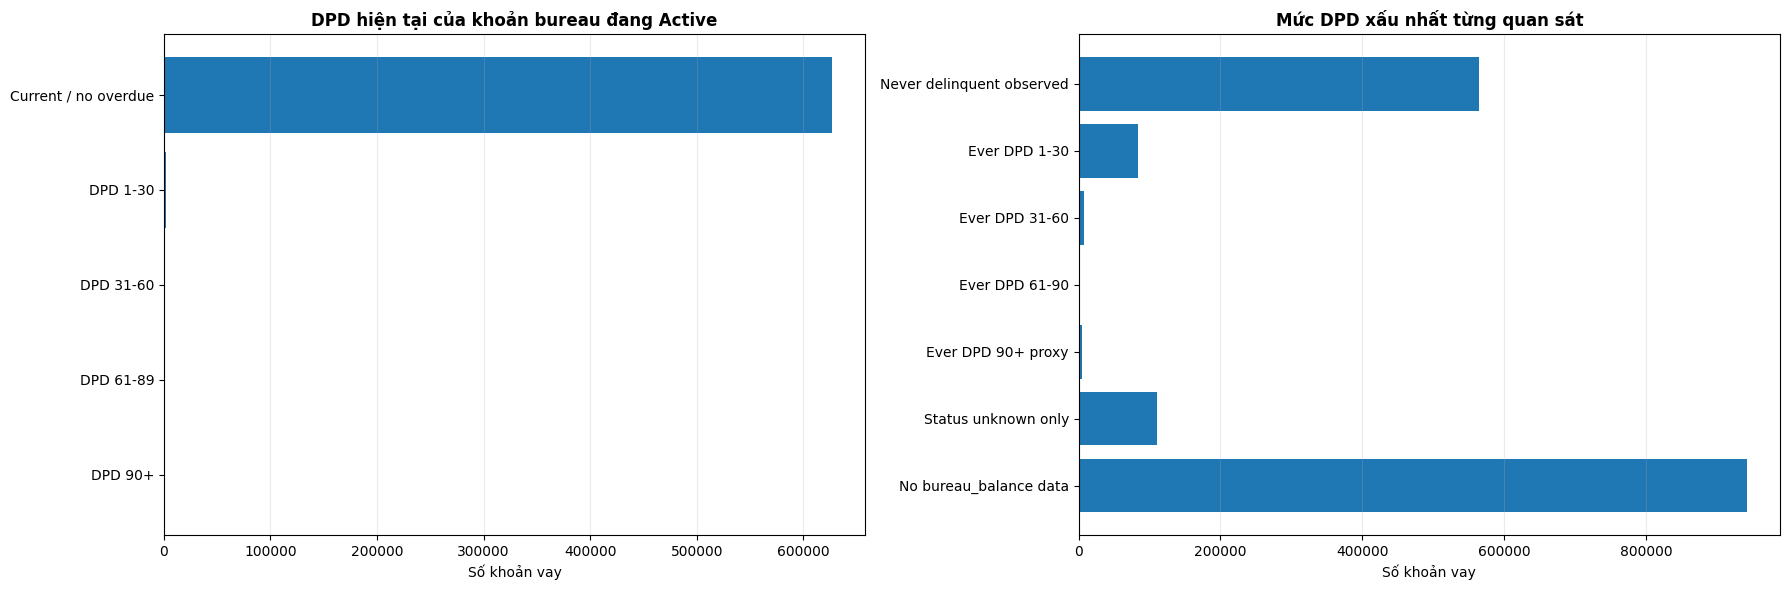

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1.5 — DPD HIỆN TẠI VÀ DPD XẤU NHẤT TRONG LỊCH SỬ BUREAU
# ══════════════════════════════════════════════════════════════════════════════
# CREDIT_DAY_OVERDUE: số ngày quá hạn hiện tại của khoản bureau.
# bureau_balance.STATUS: lịch sử theo tháng; 0 = đúng hạn, 1-5 = mức quá hạn,
# C = closed, X = unknown. Không quy đổi 1-5 thành số ngày giả.

bureau_bal_work = bureau_bal[['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']].copy()
bureau_bal_work['STATUS'] = bureau_bal_work['STATUS'].astype(str)
bureau_bal_work['STATUS_NUM'] = pd.to_numeric(
    bureau_bal_work['STATUS'], errors='coerce'
).astype('float32')

# Một dòng mỗi khoản bureau: độ phủ và mức DPD xấu nhất từng quan sát.
historical_dpd_per_loan = bureau_bal_work.groupby('SK_ID_BUREAU').agg(
    BB_ROW_COUNT=('MONTHS_BALANCE', 'size'),
    HIST_KNOWN_MONTHS=('STATUS_NUM', 'count'),
    HIST_MAX_STATUS=('STATUS_NUM', 'max'),
).reset_index()

# Trạng thái gần hiện tại nhất trong bureau_balance để kiểm tra dữ liệu,
# không dùng thay cho CREDIT_DAY_OVERDUE.
latest_status_per_loan = (
    bureau_bal_work.sort_values(['SK_ID_BUREAU', 'MONTHS_BALANCE'])
    .drop_duplicates('SK_ID_BUREAU', keep='last')
    [['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']]
    .rename(columns={
        'MONTHS_BALANCE': 'LATEST_BB_MONTH',
        'STATUS': 'LATEST_BB_STATUS',
    })
)

bureau_with_dpd = (
    bureau.merge(historical_dpd_per_loan, on='SK_ID_BUREAU', how='left')
    .merge(latest_status_per_loan, on='SK_ID_BUREAU', how='left')
)
bureau_with_dpd['HAS_BUREAU_BALANCE'] = bureau_with_dpd['BB_ROW_COUNT'].notna()
bureau_with_dpd['HAS_KNOWN_HIST_STATUS'] = bureau_with_dpd['HIST_KNOWN_MONTHS'].fillna(0).gt(0)
bureau_with_dpd['CURRENT_DPD_DAYS'] = pd.to_numeric(
    bureau_with_dpd['CREDIT_DAY_OVERDUE'], errors='coerce'
)


def current_dpd_bucket(days):
    if pd.isna(days):
        return 'Missing current DPD'
    if days <= 0:
        return 'Current / no overdue'
    if days <= 30:
        return 'DPD 1-30'
    if days <= 60:
        return 'DPD 31-60'
    if days < 90:
        return 'DPD 61-89'
    return 'DPD 90+'


def historical_dpd_bucket(row):
    if not row['HAS_BUREAU_BALANCE']:
        return 'No bureau_balance data'
    if not row['HAS_KNOWN_HIST_STATUS']:
        return 'Status unknown only'
    status = row['HIST_MAX_STATUS']
    if status <= 0:
        return 'Never delinquent observed'
    if status == 1:
        return 'Ever DPD 1-30'
    if status == 2:
        return 'Ever DPD 31-60'
    if status == 3:
        return 'Ever DPD 61-90'
    return 'Ever DPD 90+ proxy'


bureau_with_dpd['CURRENT_DPD_BUCKET'] = bureau_with_dpd['CURRENT_DPD_DAYS'].apply(
    current_dpd_bucket
)
bureau_with_dpd['HIST_DPD_BUCKET'] = bureau_with_dpd.apply(
    historical_dpd_bucket, axis=1
)

CURRENT_DPD_ORDER = [
    'Current / no overdue', 'DPD 1-30', 'DPD 31-60',
    'DPD 61-89', 'DPD 90+', 'Missing current DPD'
]
HIST_DPD_ORDER = [
    'Never delinquent observed', 'Ever DPD 1-30', 'Ever DPD 31-60',
    'Ever DPD 61-90', 'Ever DPD 90+ proxy',
    'Status unknown only', 'No bureau_balance data'
]

# DPD hiện tại nên đọc trên danh mục khoản bureau đang Active.
active_bureau = bureau_with_dpd[
    bureau_with_dpd['CREDIT_ACTIVE'].eq('Active')
].copy()
current_dist = (
    active_bureau['CURRENT_DPD_BUCKET']
    .value_counts().reindex(CURRENT_DPD_ORDER, fill_value=0)
)
current_known = active_bureau['CURRENT_DPD_DAYS'].notna()
current_par30 = active_bureau.loc[current_known, 'CURRENT_DPD_DAYS'].ge(31).mean() * 100
current_npl90 = active_bureau.loc[current_known, 'CURRENT_DPD_DAYS'].ge(90).mean() * 100

historical_dist = (
    bureau_with_dpd['HIST_DPD_BUCKET']
    .value_counts().reindex(HIST_DPD_ORDER, fill_value=0)
)
historical_known = bureau_with_dpd['HAS_KNOWN_HIST_STATUS']
historical_ever_dpd = bureau_with_dpd.loc[historical_known, 'HIST_MAX_STATUS'].ge(1).mean() * 100
historical_ever_par30 = bureau_with_dpd.loc[historical_known, 'HIST_MAX_STATUS'].ge(2).mean() * 100
historical_ever_dpd90 = bureau_with_dpd.loc[historical_known, 'HIST_MAX_STATUS'].ge(4).mean() * 100
historical_coverage = historical_known.mean() * 100

print('=' * 78)
print('DPD HIỆN TẠI — KHOẢN BUREAU ĐANG ACTIVE')
print('=' * 78)
display(pd.DataFrame({
    'Số khoản vay': current_dist,
    'Tỷ lệ (%)': current_dist / max(current_dist.sum(), 1) * 100,
}).round(2))
print(f'Current PAR30 (DPD >= 31) : {current_par30:.2f}%')
print(f'Current NPL proxy (90+)   : {current_npl90:.2f}%')

print('\n' + '=' * 78)
print('DPD XẤU NHẤT TỪNG QUAN SÁT TRONG BUREAU_BALANCE')
print('=' * 78)
display(pd.DataFrame({
    'Số khoản vay': historical_dist,
    'Tỷ lệ (%)': historical_dist / max(historical_dist.sum(), 1) * 100,
}).round(2))
print(f'Coverage trạng thái DPD xác định : {historical_coverage:.2f}%')
print(f'Ever DPD > 0 trên nhóm xác định : {historical_ever_dpd:.2f}%')
print(f'Ever PAR30 trên nhóm xác định   : {historical_ever_par30:.2f}%')
print(f'Ever DPD 90+ proxy              : {historical_ever_dpd90:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

current_plot = current_dist[current_dist.index != 'Missing current DPD']
axes[0].barh(current_plot.index[::-1], current_plot.values[::-1])
axes[0].set_title('DPD hiện tại của khoản bureau đang Active', fontweight='bold')
axes[0].set_xlabel('Số khoản vay')
axes[0].grid(axis='x', alpha=0.25)

historical_plot = historical_dist
axes[1].barh(historical_plot.index[::-1], historical_plot.values[::-1])
axes[1].set_title('Mức DPD xấu nhất từng quan sát', fontweight='bold')
axes[1].set_xlabel('Số khoản vay')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()


#### Insight về DPD toàn danh mục Bureau

**DPD hiện tại của các khoản đang Active**

- Có **630.607 khoản** Bureau đang active và có `CREDIT_DAY_OVERDUE` xác định.
- **99,36%** hiện không quá hạn.
- DPD 1–30 chiếm **0,32%**.
- Current PAR30 (`DPD ≥ 31`) là **0,32%**.
- Current DPD 90+ proxy là **0,18%**.

**DPD xấu nhất từng quan sát trong `bureau_balance`**

- Chỉ **38,65%** tổng số khoản Bureau có ít nhất một trạng thái số 0–5 xác định.
- **54,89%** không có dữ liệu `bureau_balance`; **6,46%** chỉ có trạng thái không xác định.
- Trong nhóm có trạng thái xác định: **14,87%** từng DPD > 0, **2,20%** từng PAR30 và **0,82%** từng đạt DPD 90+ proxy.

> Các tỷ lệ “Ever” phải được đọc trên đúng mẫu số có trạng thái xác định. Không được coi khoản thiếu `bureau_balance` hoặc chỉ có trạng thái `X` là khoản tốt.

Lịch sử DPD theo CREDIT_TYPE của khoản Bureau:


,Segment,Tổng khoản vay,DPD lịch sử xác định,Coverage lịch sử (%),Ever DPD > 0 (%),Ever PAR30 (%),Ever DPD 90+ proxy (%),Đủ mẫu
0,Loan for business development,1975,820,41.5200,18.5400,3.6600,2.8000,True
1,Car loan,27690,11529,41.6400,17.1300,3.1700,1.4500,True
2,Consumer credit,1251615,487150,38.9200,14.6100,2.2200,0.8400,True
3,Credit card,402195,151043,37.5500,15.7200,2.0500,0.6400,True
4,Mortgage,18391,7782,42.3100,13.9400,1.8200,0.7800,True
5,Microloan,12413,4200,33.8400,7.0200,0.5500,0.1000,True
6,Another type of loan,1017,366,35.9900,36.8900,28.1400,27.3200,False
7,Cash loan (non-earmarked),56,52,92.8600,26.9200,13.4600,13.4600,False
8,Loan for the purchase of equipment,19,8,42.1100,12.5000,12.5000,12.5000,False
9,Unknown type of loan,555,208,37.4800,12.5000,4.3300,3.8500,False



DPD hiện tại theo CREDIT_TYPE của khoản Bureau đang Active:


,Segment,Khoản Active,Current DPD xác định,Coverage current DPD (%),Current DPD > 0 (%),Current PAR30 (%),Current NPL proxy 90+ (%),Đủ mẫu
0,Consumer credit,317829,317829,100.0000,0.7900,0.3800,0.2300,True
1,Credit card,285998,285998,100.0000,0.5000,0.2800,0.1300,True
2,Mortgage,12871,12871,100.0000,0.4100,0.1400,0.0600,True
3,Car loan,9926,9926,100.0000,0.4700,0.1300,0.0800,True
4,Microloan,3025,3025,100.0000,0.3300,0.0700,0.0300,True
5,Another type of loan,202,202,100.0000,0.9900,0.9900,0.5000,False
6,Loan for business development,351,351,100.0000,1.1400,0.5700,0.2800,False
7,Loan for working capital replenishment,223,223,100.0000,0.9000,0.4500,0.0000,False
8,Unknown type of loan,116,116,100.0000,0.0000,0.0000,0.0000,False
9,Cash loan (non-earmarked),42,42,100.0000,0.0000,0.0000,0.0000,False



Lịch sử DPD Bureau theo nhóm thu nhập của khách hàng:


,Segment,Tổng khoản vay,DPD lịch sử xác định,Coverage lịch sử (%),Ever DPD > 0 (%),Ever PAR30 (%),Ever DPD 90+ proxy (%),Đủ mẫu
0,Commercial associate,336229,104283,31.0200,15.5100,2.5100,1.0200,True
1,Working,749061,234136,31.2600,14.9500,2.4300,0.9500,True
2,Pensioner,256741,79083,30.8000,13.5000,2.3700,0.9100,True
3,State servant,123200,38878,31.5600,15.6900,2.2600,0.7500,True
4,Student,64,19,29.6900,10.5300,0.0000,0.0000,False
5,Businessman,13,0,0.0000,NaN,NaN,NaN,False
6,Maternity leave,1,0,0.0000,NaN,NaN,NaN,False
7,Unemployed,16,0,0.0000,NaN,NaN,NaN,False



Lịch sử DPD Bureau theo loại hồ sơ vay hiện tại:


,Segment,Tổng khoản vay,DPD lịch sử xác định,Coverage lịch sử (%),Ever DPD > 0 (%),Ever PAR30 (%),Ever DPD 90+ proxy (%),Đủ mẫu
0,Cash loans,1339738,454323,33.9100,14.8900,2.4300,0.9400,True
1,Revolving loans,125587,2076,1.6500,15.3700,1.5400,0.5300,True


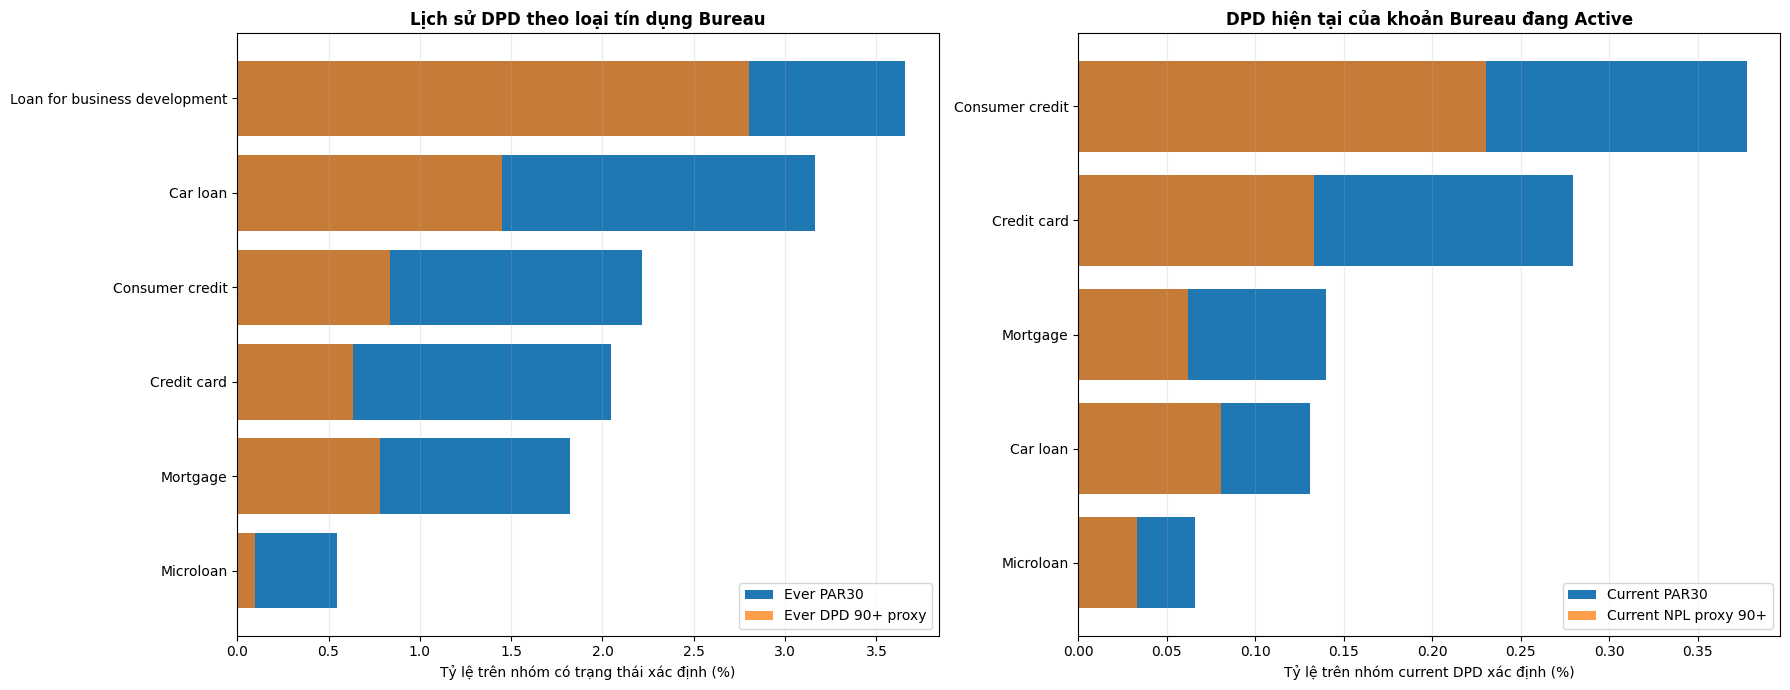

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1.5 — DPD THEO PHÂN KHÚC ĐÚNG Ý NGHĨA CỘT
# ══════════════════════════════════════════════════════════════════════════════
# CREDIT_TYPE là loại khoản tín dụng trong Bureau.
# NAME_CONTRACT_TYPE của application_train là loại hồ sơ hiện tại, không phải
# loại khoản bureau. Hai khái niệm được giữ tách biệt.

applicant_segment = app_train[
    ['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE']
].rename(columns={'NAME_CONTRACT_TYPE': 'APPLICATION_CONTRACT_TYPE'})

bureau_seg = bureau_with_dpd.merge(
    applicant_segment,
    on='SK_ID_CURR', how='left', validate='many_to_one'
)


def historical_dpd_metrics_by_segment(data, segment_col, top_n=None, min_known=100):
    rows = []
    for segment, group in data.dropna(subset=[segment_col]).groupby(segment_col, observed=False):
        total = len(group)
        known = group['HAS_KNOWN_HIST_STATUS']
        known_count = int(known.sum())
        known_group = group.loc[known]
        rows.append({
            'Segment': segment,
            'Tổng khoản vay': total,
            'DPD lịch sử xác định': known_count,
            'Coverage lịch sử (%)': known_count / total * 100 if total else np.nan,
            'Ever DPD > 0 (%)': known_group['HIST_MAX_STATUS'].ge(1).mean() * 100 if known_count else np.nan,
            'Ever PAR30 (%)': known_group['HIST_MAX_STATUS'].ge(2).mean() * 100 if known_count else np.nan,
            'Ever DPD 90+ proxy (%)': known_group['HIST_MAX_STATUS'].ge(4).mean() * 100 if known_count else np.nan,
            'Đủ mẫu': known_count >= min_known,
        })
    result = pd.DataFrame(rows)
    if result.empty:
        return result
    result = result.sort_values(
        ['Đủ mẫu', 'Ever PAR30 (%)', 'DPD lịch sử xác định'],
        ascending=[False, False, False]
    )
    if top_n is not None:
        result = result.head(top_n)
    return result.reset_index(drop=True)


def current_dpd_metrics_by_segment(data, segment_col, top_n=None, min_known=100):
    work = data[
        data['CREDIT_ACTIVE'].eq('Active')
    ].dropna(subset=[segment_col]).copy()
    rows = []
    for segment, group in work.groupby(segment_col, observed=False):
        total = len(group)
        known = group['CURRENT_DPD_DAYS'].notna()
        known_count = int(known.sum())
        known_dpd = group.loc[known, 'CURRENT_DPD_DAYS']
        rows.append({
            'Segment': segment,
            'Khoản Active': total,
            'Current DPD xác định': known_count,
            'Coverage current DPD (%)': known_count / total * 100 if total else np.nan,
            'Current DPD > 0 (%)': known_dpd.gt(0).mean() * 100 if known_count else np.nan,
            'Current PAR30 (%)': known_dpd.ge(31).mean() * 100 if known_count else np.nan,
            'Current NPL proxy 90+ (%)': known_dpd.ge(90).mean() * 100 if known_count else np.nan,
            'Đủ mẫu': known_count >= min_known,
        })
    result = pd.DataFrame(rows)
    if result.empty:
        return result
    result = result.sort_values(
        ['Đủ mẫu', 'Current PAR30 (%)', 'Current DPD xác định'],
        ascending=[False, False, False]
    )
    if top_n is not None:
        result = result.head(top_n)
    return result.reset_index(drop=True)


# Loại khoản tín dụng Bureau — đúng cột CREDIT_TYPE.
historical_by_credit_type = historical_dpd_metrics_by_segment(
    bureau_seg, 'CREDIT_TYPE', top_n=12, min_known=500
)
current_by_credit_type = current_dpd_metrics_by_segment(
    bureau_seg, 'CREDIT_TYPE', top_n=12, min_known=500
)

# Nhóm thu nhập là đặc điểm khách hàng của hồ sơ hiện tại.
historical_by_income_type = historical_dpd_metrics_by_segment(
    bureau_seg, 'NAME_INCOME_TYPE', top_n=10, min_known=500
)

# Loại hợp đồng hiện tại được trình bày riêng, không gọi là loại khoản bureau.
historical_by_application_contract = historical_dpd_metrics_by_segment(
    bureau_seg, 'APPLICATION_CONTRACT_TYPE', min_known=500
)

print('Lịch sử DPD theo CREDIT_TYPE của khoản Bureau:')
display(historical_by_credit_type.round(2))
print('\nDPD hiện tại theo CREDIT_TYPE của khoản Bureau đang Active:')
display(current_by_credit_type.round(2))
print('\nLịch sử DPD Bureau theo nhóm thu nhập của khách hàng:')
display(historical_by_income_type.round(2))
print('\nLịch sử DPD Bureau theo loại hồ sơ vay hiện tại:')
display(historical_by_application_contract.round(2))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

hist_plot = historical_by_credit_type[
    historical_by_credit_type['Đủ mẫu']
].sort_values('Ever PAR30 (%)')
axes[0].barh(hist_plot['Segment'], hist_plot['Ever PAR30 (%)'], label='Ever PAR30')
axes[0].barh(
    hist_plot['Segment'], hist_plot['Ever DPD 90+ proxy (%)'],
    label='Ever DPD 90+ proxy', alpha=0.75
)
axes[0].set_title('Lịch sử DPD theo loại tín dụng Bureau', fontweight='bold')
axes[0].set_xlabel('Tỷ lệ trên nhóm có trạng thái xác định (%)')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.25)

current_plot = current_by_credit_type[
    current_by_credit_type['Đủ mẫu']
].sort_values('Current PAR30 (%)')
axes[1].barh(current_plot['Segment'], current_plot['Current PAR30 (%)'], label='Current PAR30')
axes[1].barh(
    current_plot['Segment'], current_plot['Current NPL proxy 90+ (%)'],
    label='Current NPL proxy 90+', alpha=0.75
)
axes[1].set_title('DPD hiện tại của khoản Bureau đang Active', fontweight='bold')
axes[1].set_xlabel('Tỷ lệ trên nhóm current DPD xác định (%)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()


#### DPD theo phân khúc

**Theo loại tín dụng Bureau và chỉ xét nhóm đủ mẫu lịch sử**

- Ever PAR30 cao nhất ở `Loan for business development` (**3,66%**) và `Car loan` (**3,17%**).
- `Consumer credit` đạt **2,22%**, `Credit card` **2,05%**, `Mortgage` **1,82%** và `Microloan` **0,55%**.
- Với DPD hiện tại của khoản active, PAR30 khoảng **0,38%** ở Consumer credit, **0,28%** ở Credit card, **0,14%** ở Mortgage, **0,13%** ở Car loan và **0,07%** ở Microloan.
- Các nhóm có tỷ lệ cao nhưng không đạt ngưỡng mẫu tối thiểu chỉ được xem là tín hiệu tham khảo.

**Theo loại thu nhập**

- Trong các nhóm đủ mẫu, Ever PAR30 dao động tương đối hẹp từ **2,26% đến 2,51%**; khác biệt quan sát chưa đủ để kết luận quan hệ nhân quả.

**Theo loại hợp đồng hiện tại**

- Coverage lịch sử của `Cash loans` là **33,91%**, trong khi `Revolving loans` chỉ **1,65%**.
- Vì độ phủ khác biệt rất lớn, không nên so sánh trực tiếp hai tỷ lệ như hai danh mục có chất lượng dữ liệu tương đương.

> Mọi kết luận phân khúc cần đi kèm số quan sát, coverage và cờ “Đủ mẫu”.

**Quy ước DPD trong notebook**

| Khái niệm | Quy ước | Cách diễn giải |
|---|---|---|
| Current / no overdue | `CREDIT_DAY_OVERDUE ≤ 0` trên khoản active | Trạng thái quá hạn hiện tại |
| Current PAR30 | `CREDIT_DAY_OVERDUE ≥ 31` | Quá hạn hiện tại từ 31 ngày |
| Current DPD 90+ proxy | `CREDIT_DAY_OVERDUE ≥ 90` | Chỉ báo gần đúng quá hạn nghiêm trọng hiện tại |
| Never delinquent observed | Max `STATUS = 0` | Chưa ghi nhận quá hạn trong phần lịch sử quan sát được |
| Ever DPD 1–30 | Max `STATUS = 1` | Từng ở mức DPD 1–30 |
| Ever PAR30 | Max `STATUS ≥ 2` | Từng đạt mức tương ứng DPD 31+ |
| Ever DPD 90+ proxy | Max `STATUS ≥ 4` | Chỉ báo gần đúng từng đạt DPD 90+ |
| Status unknown only | Chỉ có `X` | Không đủ dữ liệu để xếp tốt/xấu |
| No bureau_balance data | Không nối được lịch sử tháng | Không nằm trong mẫu số Ever DPD |

Trong Roll Rate, `C` được xem là trạng thái đóng; `X` là trạng thái không xác định và không được quy về Current.

##### Delinquency rate theo tháng tương đối

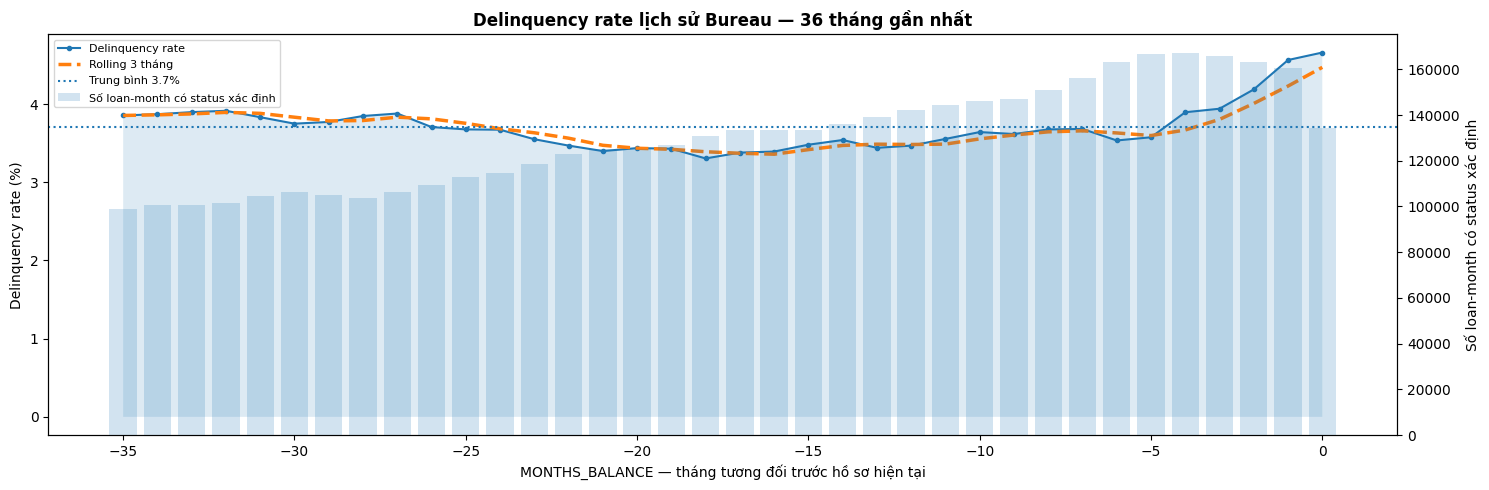

Tháng có delinquency rate cao nhất trong 36 tháng gần nhất:
MONTHS_BALANCE          0.0000
DELINQ_RATE_PCT         4.6585
LOAN_MONTH_COUNT   134336.0000


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1.5 — TỶ LỆ DELINQUENCY THEO THÁNG LỊCH SỬ BUREAU
# ══════════════════════════════════════════════════════════════════════════════
# Mẫu số chỉ gồm status 0-5. C = closed và X = unknown không được coi là tốt.

valid_observed_status = ['0', '1', '2', '3', '4', '5']

bureau_bal_work['STATUS'] = bureau_bal_work['STATUS'].astype(str)
bureau_bal_work['IS_KNOWN_STATUS'] = bureau_bal_work['STATUS'].isin(
    valid_observed_status
).astype('int8')
bureau_bal_work['IS_DELINQUENT'] = bureau_bal_work['STATUS'].isin(
    ['1', '2', '3', '4', '5']
).astype('int8')

bureau_bal_observed = bureau_bal_work[
    bureau_bal_work['IS_KNOWN_STATUS'].eq(1)
].copy()

monthly_delinq = (
    bureau_bal_observed.groupby('MONTHS_BALANCE')['IS_DELINQUENT']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'DELINQ_RATE', 'count': 'LOAN_MONTH_COUNT'})
    .sort_values('MONTHS_BALANCE')
)

monthly_36 = monthly_delinq[
    monthly_delinq['MONTHS_BALANCE'].between(-35, 0)
].copy()
monthly_36['DELINQ_RATE_PCT'] = monthly_36['DELINQ_RATE'] * 100
monthly_36['DELINQ_ROLL3'] = monthly_36['DELINQ_RATE_PCT'].rolling(
    3, min_periods=1
).mean()

fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()

ax1.fill_between(
    monthly_36['MONTHS_BALANCE'], monthly_36['DELINQ_RATE_PCT'], alpha=0.15
)
ax1.plot(
    monthly_36['MONTHS_BALANCE'], monthly_36['DELINQ_RATE_PCT'],
    linewidth=1.5, marker='o', markersize=3, label='Delinquency rate'
)
ax1.plot(
    monthly_36['MONTHS_BALANCE'], monthly_36['DELINQ_ROLL3'],
    linewidth=2.5, linestyle='--', label='Rolling 3 tháng'
)
ax2.bar(
    monthly_36['MONTHS_BALANCE'], monthly_36['LOAN_MONTH_COUNT'],
    alpha=0.20, label='Số loan-month có status xác định'
)

avg_delinq = monthly_36['DELINQ_RATE_PCT'].mean()
ax1.axhline(
    y=avg_delinq, linestyle=':', linewidth=1.5,
    label=f'Trung bình {avg_delinq:.1f}%'
)

ax1.set_xlabel('MONTHS_BALANCE — tháng tương đối trước hồ sơ hiện tại')
ax1.set_ylabel('Delinquency rate (%)')
ax2.set_ylabel('Số loan-month có status xác định')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax1.set_title('Delinquency rate lịch sử Bureau — 36 tháng gần nhất', fontweight='bold')
plt.tight_layout()
plt.show()

idx_max = monthly_36['DELINQ_RATE_PCT'].idxmax()
print('Tháng có delinquency rate cao nhất trong 36 tháng gần nhất:')
print(monthly_36.loc[
    idx_max, ['MONTHS_BALANCE', 'DELINQ_RATE_PCT', 'LOAN_MONTH_COUNT']
].to_string())


#### Nhận xét về xu hướng delinquency

- Trong đúng **36 mốc tháng tương đối từ -35 đến 0**, `MONTHS_BALANCE = 0` có delinquency rate cao nhất, đạt **4,6585%** trên **134.336 loan–month** có trạng thái xác định.
- Trung bình trượt ba tháng giúp giảm nhiễu ngắn hạn và cho thấy tỷ lệ quan sát có xu hướng cao hơn khi tiến gần tháng 0.
- `MONTHS_BALANCE` không chứa ngày lịch; kết quả không đủ để gắn biến động với một năm, chu kỳ kinh tế hoặc thay đổi chính sách cụ thể.
- Mẫu số chỉ gồm trạng thái số 0–5; `C` và `X` không được coi là khoản đúng hạn.

> Insight phù hợp là “rủi ro quan sát tăng về cuối trục thời gian tương đối”, không phải “danh mục ngân hàng xấu đi theo thời gian lịch”.

##### Vintage proxy theo thời điểm mở khoản tín dụng Bureau

`DAYS_CREDIT / 30,4375` được sử dụng để xấp xỉ tháng mở khoản Bureau và tạo cohort. Sự kiện theo dõi là cumulative Ever PAR30 đến từng MOB. Do ngày mở chỉ được suy ra từ số ngày tương đối, kết quả được gọi là **Vintage proxy**, không phải booking vintage chính xác của khoản vay hiện tại.

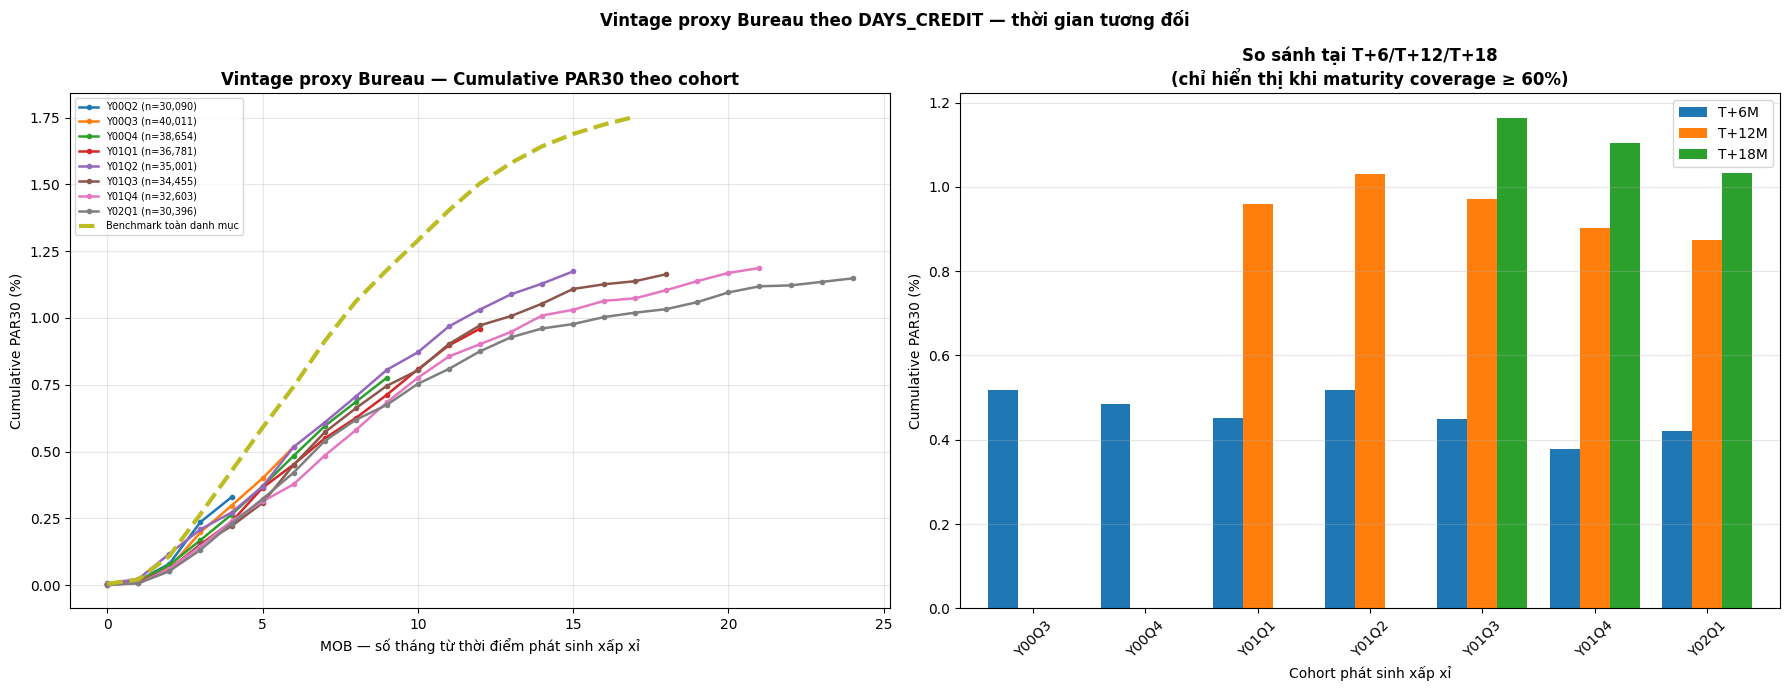

Bảng checkpoint Cumulative PAR30 (%):


,T+6M,T+12M,T+18M
COHORT,,,
Y00Q3,0.5200,NaN,NaN
Y00Q4,0.4800,NaN,NaN
Y01Q1,0.4500,0.9600,NaN
Y01Q2,0.5200,1.0300,NaN
Y01Q3,0.4500,0.9700,1.1600
Y01Q4,0.3800,0.9000,1.1000
Y02Q1,0.4200,0.8800,1.0300


Maturity coverage tại các checkpoint:


,Coverage T+6M,Coverage T+12M,Coverage T+18M
COHORT,,,
Y00Q2,0.0000,0.0000,0.0000
Y00Q3,86.7600,0.0000,0.0000
Y00Q4,92.7500,0.0000,0.0000
Y01Q1,94.4800,80.3700,0.0000
Y01Q2,94.9600,86.4100,0.0000
Y01Q3,94.7400,87.9400,75.6200
Y01Q4,95.2700,88.4000,80.9500
Y02Q1,95.3900,88.9800,82.6200


Lưu ý: đây là vintage proxy của khoản Bureau, suy ra từ DAYS_CREDIT/30.4375; không được diễn giải như booking date chính xác của ngân hàng.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1.5 — VINTAGE PROXY THEO DAYS_CREDIT VÀ CUMULATIVE PAR30
# ══════════════════════════════════════════════════════════════════════════════
# DAYS_CREDIT: số ngày tương đối từ thời điểm hồ sơ hiện tại về thời điểm khoản
# vay bureau được ghi nhận. Quy đổi sang tháng chỉ là xấp xỉ.

DAYS_PER_MONTH = 30.4375
VINTAGE_EVENT_STATUSES = ['2', '3', '4', '5']  # PAR30 = DPD 31+
VINTAGE_MAX_MOB = 24
MIN_COHORT_LOANS = 500
MIN_MATURITY_COVERAGE = 0.60

bureau_origin = bureau[
    ['SK_ID_BUREAU', 'SK_ID_CURR', 'DAYS_CREDIT']
].drop_duplicates('SK_ID_BUREAU').copy()

bureau_origin['ORIGINATION_MONTH_APPROX'] = np.rint(
    pd.to_numeric(bureau_origin['DAYS_CREDIT'], errors='coerce') / DAYS_PER_MONTH
).astype('Int64')

vintage_history = bureau_bal_work[
    ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']
].merge(
    bureau_origin,
    on='SK_ID_BUREAU',
    how='inner',
    validate='many_to_one'
)

vintage_history['STATUS'] = vintage_history['STATUS'].astype(str)
vintage_history['MOB'] = (
    vintage_history['MONTHS_BALANCE']
    - vintage_history['ORIGINATION_MONTH_APPROX'].astype(float)
)

# Giữ các quan sát từ tháng phát sinh xấp xỉ trở đi; loại X khỏi mẫu quan sát.
vintage_history = vintage_history[
    vintage_history['MOB'].notna()
    & (vintage_history['MOB'] >= 0)
    & vintage_history['STATUS'].ne('X')
    & ((vintage_history['MONTHS_BALANCE'] - vintage_history['ORIGINATION_MONTH_APPROX'].astype(float)) <= VINTAGE_MAX_MOB)
].copy()
vintage_history['MOB'] = vintage_history['MOB'].round().astype(int)
vintage_history['IS_PAR30_EVENT'] = vintage_history['STATUS'].isin(
    VINTAGE_EVENT_STATUSES
).astype('int8')


def relative_quarter_label(origin_month):
    if pd.isna(origin_month):
        return 'Không xác định'
    months_ago = abs(int(origin_month))
    relative_year = months_ago // 12
    relative_quarter = (months_ago % 12) // 3 + 1
    return f'Y{relative_year:02d}Q{relative_quarter}'


bureau_origin['COHORT'] = bureau_origin['ORIGINATION_MONTH_APPROX'].apply(
    relative_quarter_label
)

# Một dòng cho mỗi khoản vay: cohort, MOB quan sát tối đa, MOB đầu tiên đạt PAR30.
loan_observation = (
    vintage_history.groupby('SK_ID_BUREAU', as_index=False)
    .agg(
        MAX_OBSERVED_MOB=('MOB', 'max'),
        NUMBER_OF_OBSERVED_MONTHS=('MOB', 'nunique'),
    )
    .merge(
        bureau_origin[['SK_ID_BUREAU', 'SK_ID_CURR', 'COHORT', 'ORIGINATION_MONTH_APPROX']],
        on='SK_ID_BUREAU',
        how='left',
        validate='one_to_one'
    )
)

first_par30 = (
    vintage_history[vintage_history['IS_PAR30_EVENT'] == 1]
    .groupby('SK_ID_BUREAU')['MOB']
    .min()
    .rename('FIRST_PAR30_MOB')
)
loan_observation = loan_observation.merge(
    first_par30,
    on='SK_ID_BUREAU',
    how='left'
)

cohort_volume = (
    loan_observation.groupby('COHORT')['SK_ID_BUREAU']
    .nunique()
    .sort_values(ascending=False)
)
eligible_cohort_volume = cohort_volume[
    cohort_volume >= MIN_COHORT_LOANS
]
if eligible_cohort_volume.empty:
    print(
        f'Không có cohort đạt {MIN_COHORT_LOANS:,} khoản vay; '
        'tạm dùng các cohort lớn nhất để kiểm tra code.'
    )
    eligible_cohort_volume = cohort_volume

top_cohorts = eligible_cohort_volume.head(8).index.tolist()


def build_vintage_curve(loan_level, max_mob=24):
    rows = []
    for cohort, group in loan_level.groupby('COHORT', observed=False):
        cohort_size = group['SK_ID_BUREAU'].nunique()
        if cohort_size == 0:
            continue

        for mob in range(max_mob + 1):
            mature_count = int((group['MAX_OBSERVED_MOB'] >= mob).sum())
            maturity_coverage = mature_count / cohort_size
            cumulative_bad_count = int((
                group['FIRST_PAR30_MOB'].notna()
                & (group['FIRST_PAR30_MOB'] <= mob)
            ).sum())

            rows.append({
                'COHORT': cohort,
                'MOB': mob,
                'COHORT_SIZE': cohort_size,
                'MATURE_COUNT': mature_count,
                'MATURITY_COVERAGE': maturity_coverage,
                'CUMULATIVE_PAR30_COUNT': cumulative_bad_count,
                # Mẫu số cố định theo cohort để đường cumulative không giảm giả.
                'CUMULATIVE_PAR30_RATE': cumulative_bad_count / cohort_size,
            })
    return pd.DataFrame(rows)


vintage_full = build_vintage_curve(loan_observation, VINTAGE_MAX_MOB)
vintage_df = vintage_full[
    vintage_full['COHORT'].isin(top_cohorts)
    & (vintage_full['MATURITY_COVERAGE'] >= MIN_MATURITY_COVERAGE)
].copy()

benchmark_source = loan_observation.assign(COHORT='Toàn danh mục')
benchmark = build_vintage_curve(benchmark_source, VINTAGE_MAX_MOB)
benchmark = benchmark[
    benchmark['MATURITY_COVERAGE'] >= MIN_MATURITY_COVERAGE
].copy()

# ── Biểu đồ Vintage Curve ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for cohort, group in vintage_df.groupby('COHORT', observed=False):
    group = group.sort_values('MOB')
    axes[0].plot(
        group['MOB'],
        group['CUMULATIVE_PAR30_RATE'] * 100,
        linewidth=1.8,
        marker='o',
        markersize=3,
        label=f'{cohort} (n={cohort_volume.get(cohort, 0):,})'
    )

axes[0].plot(
    benchmark['MOB'],
    benchmark['CUMULATIVE_PAR30_RATE'] * 100,
    linewidth=3,
    linestyle='--',
    label='Benchmark toàn danh mục'
)
axes[0].set_xlabel('MOB — số tháng từ thời điểm phát sinh xấp xỉ')
axes[0].set_ylabel('Cumulative PAR30 (%)')
axes[0].set_title('Vintage proxy Bureau — Cumulative PAR30 theo cohort', fontweight='bold')
axes[0].legend(fontsize=7, loc='upper left')
axes[0].grid(alpha=0.3)

# So sánh tại các checkpoint; chỉ lấy điểm đủ maturity coverage.
checkpoints = [6, 12, 18]
checkpoint_rows = []
for cohort in top_cohorts:
    row = {'COHORT': cohort}
    cohort_data = vintage_full[vintage_full['COHORT'] == cohort]
    for checkpoint in checkpoints:
        point = cohort_data[cohort_data['MOB'] == checkpoint]
        if point.empty or point['MATURITY_COVERAGE'].iloc[0] < MIN_MATURITY_COVERAGE:
            row[f'T+{checkpoint}M'] = np.nan
        else:
            row[f'T+{checkpoint}M'] = (
                point['CUMULATIVE_PAR30_RATE'].iloc[0] * 100
            )
    checkpoint_rows.append(row)

checkpoint_table = pd.DataFrame(checkpoint_rows)
if checkpoint_table.empty:
    checkpoint_table = pd.DataFrame(
        columns=[f'T+{checkpoint}M' for checkpoint in checkpoints]
    )
else:
    checkpoint_table = checkpoint_table.set_index('COHORT').dropna(how='all')

if checkpoint_table.empty:
    axes[1].text(
        0.5, 0.5,
        'Không có checkpoint đủ maturity coverage',
        ha='center', va='center', transform=axes[1].transAxes
    )
else:
    checkpoint_table.plot(kind='bar', ax=axes[1], width=0.8)

axes[1].set_ylabel('Cumulative PAR30 (%)')
axes[1].set_xlabel('Cohort phát sinh xấp xỉ')
axes[1].set_title(
    f'So sánh tại T+6/T+12/T+18\n'
    f'(chỉ hiển thị khi maturity coverage ≥ {MIN_MATURITY_COVERAGE:.0%})',
    fontweight='bold'
)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Vintage proxy Bureau theo DAYS_CREDIT — thời gian tương đối',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Bảng checkpoint Cumulative PAR30 (%):')
display(checkpoint_table.round(2))

coverage_checkpoint = vintage_full[
    vintage_full['MOB'].isin(checkpoints)
    & vintage_full['COHORT'].isin(top_cohorts)
].pivot(index='COHORT', columns='MOB', values='MATURITY_COVERAGE')
coverage_checkpoint.columns = [f'Coverage T+{int(col)}M' for col in coverage_checkpoint.columns]
print('Maturity coverage tại các checkpoint:')
display((coverage_checkpoint * 100).round(2))

print(
    'Lưu ý: đây là vintage proxy của khoản Bureau, suy ra từ DAYS_CREDIT/30.4375; '
    'không được diễn giải như booking date chính xác của ngân hàng.'
)


#### Insight từ Vintage proxy

- Tại T+12, cumulative PAR30 cao nhất là cohort `Y01Q2` **1,03%**, tiếp theo là `Y01Q3` **0,97%**, `Y01Q1` **0,96%**, `Y01Q4` **0,90%** và `Y02Q1` **0,88%**.
- Chênh lệch cao nhất–thấp nhất tại T+12 chỉ **0,15 điểm phần trăm**, nên không nên diễn giải là khác biệt chất lượng cohort quá lớn.
- Tại T+18, ba cohort đủ độ trưởng thành có cumulative PAR30 từ **1,03% đến 1,16%**.
- Maturity coverage được kiểm soát tại từng checkpoint; ô không đủ độ trưởng thành được để trống thay vì so sánh cưỡng ép.

> Vintage proxy cho thấy khác biệt cohort có tồn tại nhưng tương đối nhỏ; chưa đủ cơ sở quy kết cho thay đổi chính sách cấp tín dụng hoặc điều kiện kinh tế.

##### Ma trận Roll Rate giữa hai tháng liên tiếp

ROLL RATE ĐẦY ĐỦ (%) — giữ Unknown và Closed để kiểm tra dữ liệu:


BUCKET_NEXT,Unknown,Closed,Current,DPD 1-30,DPD 31-60,DPD 61-90,DPD 90+ proxy
BUCKET_CUR,,,,,,,
Unknown,87.5900,0.9200,11.2500,0.1800,0.0200,0.0000,0.0300
Closed,0.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Current,7.3100,4.8500,85.8000,1.9800,0.0500,0.0000,0.0100
DPD 1-30,3.4100,8.1500,47.8700,34.6100,5.8500,0.1000,0.0200
DPD 31-60,4.1900,7.1500,24.9800,14.6000,18.1900,30.1700,0.7100
DPD 61-90,2.6500,7.3100,12.3300,5.7000,5.1700,11.5300,55.3100
DPD 90+ proxy,3.0800,3.4500,2.2900,0.5400,0.3800,0.3100,89.9500


Độ phủ trạng thái tháng sau theo bucket hiện tại:


,Số cặp tháng,Coverage tháng sau (%)
BUCKET_CUR,,
Closed,13197390,100.0000
Current,7342179,92.6900
DPD 1-30,236579,96.5900
DPD 31-60,23133,95.8100
DPD 61-90,8838,97.3500
DPD 90+ proxy,66932,96.9200


ROLL RATE NGHIỆP VỤ (%) — điều kiện trên trạng thái tháng sau xác định:


BUCKET_NEXT,Closed,Current,DPD 1-30,DPD 31-60,DPD 61-90,DPD 90+ proxy
BUCKET_CUR,,,,,,
Closed,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Current,5.2300,92.5700,2.1300,0.0500,0.0000,0.0100
DPD 1-30,8.4300,49.5500,35.8300,6.0600,0.1000,0.0300
DPD 31-60,7.4600,26.0700,15.2400,18.9900,31.4900,0.7400
DPD 61-90,7.5100,12.6700,5.8600,5.3100,11.8400,56.8100
DPD 90+ proxy,3.5600,2.3600,0.5500,0.4000,0.3200,92.8000


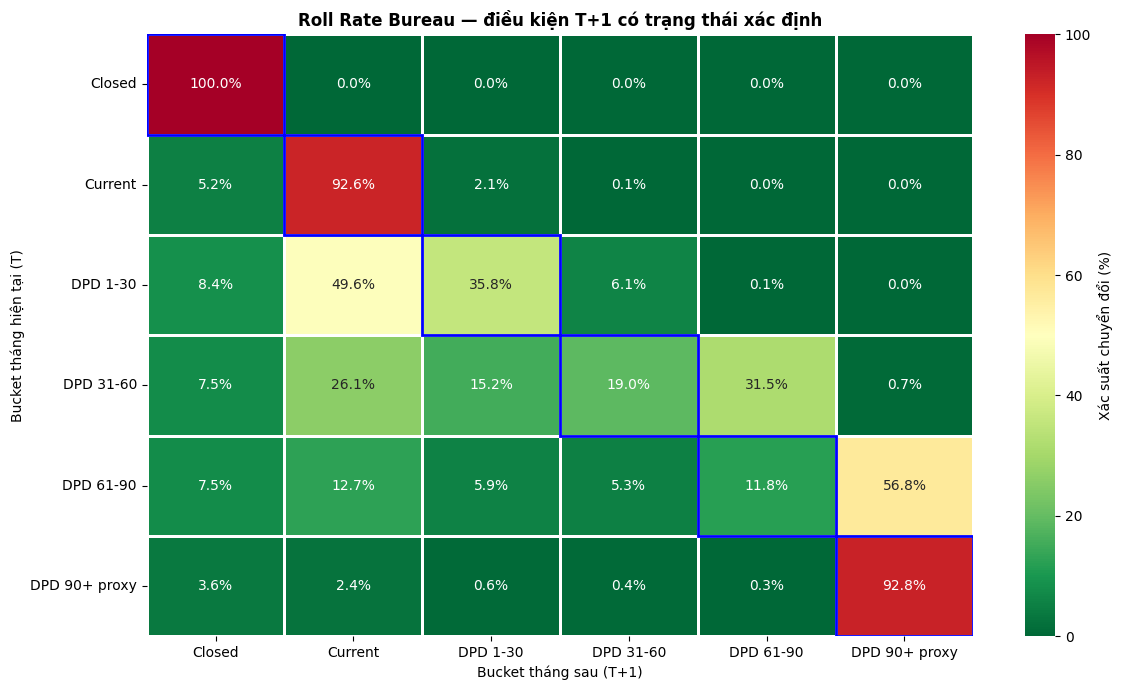

,Chỉ tiêu,Tỷ lệ (%)
0,Current → DPD 1-30,2.1300
1,DPD 1-30 → Current (cure),49.5500
2,DPD 31-60 → DPD 61-90,31.4900
3,DPD 61-90 → DPD 90+ proxy,56.8100
4,DPD 90+ proxy → DPD 90+ proxy (persistence),92.8000


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1.5 — ROLL RATE MATRIX CỦA LỊCH SỬ BUREAU
# ══════════════════════════════════════════════════════════════════════════════

bb = bureau_bal_work[['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']].copy()
bb['STATUS'] = bb['STATUS'].astype(str)

number_of_duplicate_loan_months = int(
    bb.duplicated(['SK_ID_BUREAU', 'MONTHS_BALANCE']).sum()
)
if number_of_duplicate_loan_months > 0:
    print(f'Cảnh báo: loại {number_of_duplicate_loan_months:,} bản ghi loan-month trùng.')
    bb = bb.drop_duplicates(['SK_ID_BUREAU', 'MONTHS_BALANCE'], keep='last')

bb_next = bb.rename(columns={'STATUS': 'STATUS_NEXT'}).copy()
# Trạng thái ở -1 là tháng kế tiếp của -2; dịch khóa để ghép cặp T -> T+1.
bb_next['MONTHS_BALANCE'] = bb_next['MONTHS_BALANCE'] - 1

roll_raw = bb.merge(
    bb_next,
    on=['SK_ID_BUREAU', 'MONTHS_BALANCE'],
    how='inner', validate='one_to_one'
)

BUCKET_MAP = {
    'X': 'Unknown',
    'C': 'Closed',
    '0': 'Current',
    '1': 'DPD 1-30',
    '2': 'DPD 31-60',
    '3': 'DPD 61-90',
    '4': 'DPD 90+ proxy',
    '5': 'DPD 90+ proxy',
}
FULL_BUCKET_ORDER = [
    'Unknown', 'Closed', 'Current', 'DPD 1-30',
    'DPD 31-60', 'DPD 61-90', 'DPD 90+ proxy'
]
BUSINESS_BUCKET_ORDER = [
    'Closed', 'Current', 'DPD 1-30',
    'DPD 31-60', 'DPD 61-90', 'DPD 90+ proxy'
]

roll_raw['BUCKET_CUR'] = roll_raw['STATUS'].map(BUCKET_MAP)
roll_raw['BUCKET_NEXT'] = roll_raw['STATUS_NEXT'].map(BUCKET_MAP)
roll_raw = roll_raw.dropna(subset=['BUCKET_CUR', 'BUCKET_NEXT'])


def make_roll_rate_matrix(data, bucket_order):
    counts = (
        data.groupby(['BUCKET_CUR', 'BUCKET_NEXT'], observed=False)
        .size().unstack(fill_value=0)
        .reindex(index=bucket_order, columns=bucket_order, fill_value=0)
    )
    rates = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    return counts, rates.fillna(0)


roll_counts_full, roll_pct_full = make_roll_rate_matrix(
    roll_raw, FULL_BUCKET_ORDER
)
print('ROLL RATE ĐẦY ĐỦ (%) — giữ Unknown và Closed để kiểm tra dữ liệu:')
display(roll_pct_full.round(2))

# Coverage của trạng thái tháng sau, theo bucket hiện tại.
next_status_coverage = (
    roll_raw.assign(NEXT_STATUS_KNOWN=roll_raw['BUCKET_NEXT'].ne('Unknown'))
    .groupby('BUCKET_CUR')['NEXT_STATUS_KNOWN']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'Số cặp tháng', 'mean': 'Coverage tháng sau'})
    .reindex(BUSINESS_BUCKET_ORDER)
)
next_status_coverage['Coverage tháng sau (%)'] = (
    next_status_coverage['Coverage tháng sau'] * 100
)
print('Độ phủ trạng thái tháng sau theo bucket hiện tại:')
display(next_status_coverage[['Số cặp tháng', 'Coverage tháng sau (%)']].round(2))

# Ma trận nghiệp vụ là xác suất có điều kiện khi cả T và T+1 đều xác định.
roll_business = roll_raw[
    roll_raw['BUCKET_CUR'].ne('Unknown')
    & roll_raw['BUCKET_NEXT'].ne('Unknown')
].copy()
roll_counts_business, roll_business_pct = make_roll_rate_matrix(
    roll_business, BUSINESS_BUCKET_ORDER
)

print('ROLL RATE NGHIỆP VỤ (%) — điều kiện trên trạng thái tháng sau xác định:')
display(roll_business_pct.round(2))

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    roll_business_pct,
    annot=roll_business_pct.round(1).astype(str) + '%',
    fmt='', cmap='RdYlGn_r', linewidths=0.8,
    cbar_kws={'label': 'Xác suất chuyển đổi (%)'},
    vmin=0, vmax=100, ax=ax
)
for diagonal_index in range(len(BUSINESS_BUCKET_ORDER)):
    ax.add_patch(plt.Rectangle(
        (diagonal_index, diagonal_index), 1, 1,
        fill=False, edgecolor='blue', lw=2.0, zorder=5
    ))
ax.set_title('Roll Rate Bureau — điều kiện T+1 có trạng thái xác định', fontweight='bold')
ax.set_xlabel('Bucket tháng sau (T+1)')
ax.set_ylabel('Bucket tháng hiện tại (T)')
plt.tight_layout()
plt.show()


def safe_transition(current_bucket, next_bucket):
    if current_bucket not in roll_business_pct.index:
        return np.nan
    if next_bucket not in roll_business_pct.columns:
        return np.nan
    return float(roll_business_pct.loc[current_bucket, next_bucket])


transition_summary = pd.DataFrame({
    'Chỉ tiêu': [
        'Current → DPD 1-30',
        'DPD 1-30 → Current (cure)',
        'DPD 31-60 → DPD 61-90',
        'DPD 61-90 → DPD 90+ proxy',
        'DPD 90+ proxy → DPD 90+ proxy (persistence)',
    ],
    'Tỷ lệ (%)': [
        safe_transition('Current', 'DPD 1-30'),
        safe_transition('DPD 1-30', 'Current'),
        safe_transition('DPD 31-60', 'DPD 61-90'),
        safe_transition('DPD 61-90', 'DPD 90+ proxy'),
        safe_transition('DPD 90+ proxy', 'DPD 90+ proxy'),
    ]
})
display(transition_summary.round(2))


#### Insight từ Roll Rate

Ma trận nghiệp vụ được điều kiện trên trạng thái tháng sau xác định; coverage T+1 của các bucket chính đều đạt ít nhất **92,69%**.

- `Current → DPD 1–30`: **2,13%**.
- `DPD 1–30 → Current` (cure): **49,55%**.
- `DPD 31–60 → DPD 61–90`: **31,49%**.
- `DPD 61–90 → DPD 90+ proxy`: **56,81%**.
- `DPD 90+ proxy → DPD 90+ proxy`: **92,80%**.

Khả năng phục hồi còn đáng kể ở DPD 1–30, nhưng xác suất chuyển nặng tăng rõ sau DPD 30 và đặc biệt sau DPD 60. Do đó, khoảng DPD 1–60 là vùng phù hợp để ưu tiên nhắc nợ, tái đánh giá và can thiệp sớm.

> Đây là chuyển dịch trạng thái lịch sử Bureau, không phải mô hình thu hồi nợ của khoản vay hiện tại.

### 2.2. Xây dựng và đánh giá mô hình dự báo

#### 2.2.1. Chuẩn bị dữ liệu và kiểm soát leakage

Quy trình mô hình gồm bảy bước:

1. Loại khóa định danh, biến mục tiêu và các nhóm biến ngoài phạm vi nghiên cứu.
2. Chia stratified thành **train 60% / calibration 10% / threshold 10% / test 20%**.
3. Logistic Regression thực hiện imputation, capping, scaling và one-hot encoding bên trong pipeline CV.
4. LightGBM sử dụng category và missing native, không preprocessing theo phân phối trước CV.
5. Hai mô hình dùng cùng một bộ 5-fold trên train.
6. Chọn mô hình bằng CV AUC; fit calibration trên calibration set; chọn threshold trên threshold set.
7. Test chỉ được sử dụng để báo cáo hiệu năng cuối cùng.

Thiết kế này tách biệt bốn quyết định: học tham số mô hình, lựa chọn mô hình, hiệu chỉnh xác suất và lựa chọn điểm vận hành.

In [ ]:
TARGET_COL = 'TARGET'

DROP_COLS = cols_building + cols_flag_doc + [
    'SK_ID_CURR', 'DAYS_BIRTH', 'DAYS_EMPLOYED'
]

drop_actual = [column for column in DROP_COLS if column in df_master.columns]
model_df = df_master.drop(columns=drop_actual, errors='ignore').copy()
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)

X_raw = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL].astype(int)

# ── 60% train / 10% calibration / 10% threshold / 20% test ───────────────
X_train_raw, X_holdout_raw, y_train, y_holdout = train_test_split(
    X_raw, y, test_size=0.40, random_state=SEED, stratify=y
)
X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    X_holdout_raw, y_holdout, test_size=0.50,
    random_state=SEED, stratify=y_holdout
)
X_calib_raw, X_valid_raw, y_calib, y_valid = train_test_split(
    X_dev_raw, y_dev, test_size=0.50,
    random_state=SEED, stratify=y_dev
)

cat_cols = X_train_raw.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()
num_cols_model = [column for column in X_train_raw.columns if column not in cat_cols]

cap_cols = [
    column for column in ['AMT_ANNUITY', 'AMT_GOODS_PRICE']
    if column in num_cols_model
]
num_cols_no_cap = [column for column in num_cols_model if column not in cap_cols]


class QuantileClipper(BaseEstimator, TransformerMixin):
    """Winsorize từng cột bằng quantile chỉ học trong fit()."""

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        array = np.asarray(X, dtype=float)
        self.n_features_in_ = array.shape[1]
        self.lower_bounds_ = np.nanquantile(array, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(array, self.upper, axis=0)
        return self

    def transform(self, X):
        array = np.asarray(X, dtype=float)
        return np.clip(array, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f'x{index}' for index in range(self.n_features_in_)]
        return np.asarray(input_features, dtype=object)


try:
    one_hot = OneHotEncoder(
        handle_unknown='ignore', min_frequency=20, sparse_output=True
    )
except TypeError:
    one_hot = OneHotEncoder(
        handle_unknown='ignore', min_frequency=20, sparse=True
    )

lr_cap_pipeline = Pipeline([
    ('clip', QuantileClipper(0.01, 0.99)),
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
    ('scale', StandardScaler()),
])
lr_num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
    ('scale', StandardScaler()),
])
lr_cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', one_hot),
])
lr_preprocessor = ColumnTransformer(
    transformers=[
        ('num_cap', lr_cap_pipeline, cap_cols),
        ('num', lr_num_pipeline, num_cols_no_cap),
        ('cat', lr_cat_pipeline, cat_cols),
    ],
    remainder='drop'
)

# ── LightGBM: giữ NaN và categorical native, không fit preprocessing trước CV ──
MISSING_CATEGORY = '__MISSING__'
UNKNOWN_CATEGORY = '__UNKNOWN__'


def prepare_lgb_frames(train_frame, *other_frames):
    train_prepared = train_frame.copy()
    others_prepared = [frame.copy() for frame in other_frames]

    for column in num_cols_model:
        train_prepared[column] = pd.to_numeric(train_prepared[column], errors='coerce')
        for frame in others_prepared:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')

    category_levels = {}
    for column in cat_cols:
        train_values = train_prepared[column].astype('string').fillna(MISSING_CATEGORY)
        levels = sorted(train_values.unique().tolist())
        for special in [MISSING_CATEGORY, UNKNOWN_CATEGORY]:
            if special not in levels:
                levels.append(special)
        category_levels[column] = levels
        train_prepared[column] = pd.Categorical(train_values, categories=levels)

        for frame in others_prepared:
            values = frame[column].astype('string').fillna(MISSING_CATEGORY)
            values = values.where(values.isin(levels), UNKNOWN_CATEGORY)
            frame[column] = pd.Categorical(values, categories=levels)

    return (train_prepared, *others_prepared), category_levels


(
    X_train, X_calib, X_valid, X_test
), category_levels = prepare_lgb_frames(
    X_train_raw, X_calib_raw, X_valid_raw, X_test_raw
)

neg_pos_ratio = y_train.eq(0).sum() / max(y_train.eq(1).sum(), 1)
model_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train       : {X_train_raw.shape}, bad rate: {y_train.mean():.2%}')
print(f'Calibration : {X_calib_raw.shape}, bad rate: {y_calib.mean():.2%}')
print(f'Threshold   : {X_valid_raw.shape}, bad rate: {y_valid.mean():.2%}')
print(f'Test        : {X_test_raw.shape}, bad rate: {y_test.mean():.2%}')
print(f'Categorical native features: {len(cat_cols)}')
print(f'Numeric features           : {len(num_cols_model)}')
print(f'Negative/Positive ratio    : {neg_pos_ratio:.2f}')


Train       : (184506, 143), bad rate: 8.07%
Calibration : (30751, 143), bad rate: 8.07%
Threshold   : (30751, 143), bad rate: 8.07%
Test        : (61503, 143), bad rate: 8.07%
Categorical native features: 12
Numeric features           : 131
Negative/Positive ratio    : 11.39


#### Kết quả chia mẫu và tập đặc trưng

| Tập | Số hồ sơ | Bad rate |
|---|---:|---:|
| Train | 184.506 | 8,07% |
| Calibration | 30.751 | 8,07% |
| Threshold | 30.751 | 8,07% |
| Test | 61.503 | 8,07% |

Tập mô hình có **143 feature**, gồm **131 biến số** và **12 biến phân loại**. Các tập có cùng bad rate nhờ stratify và hoàn toàn rời nhau theo index gốc. Tỷ lệ âm/dương trong train là **11,39**.

> Random split phù hợp để so sánh mô hình trong phạm vi đồ án nhưng chưa thay thế out-of-time validation khi có dữ liệu ngày lịch thực.

#### 2.2.2. Logistic Regression – mô hình cơ sở

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.05,
    random_state=SEED,
    solver='liblinear'
)

lr_pipeline = Pipeline([
    ('preprocess', lr_preprocessor),
    ('model', lr),
])

lr_cv_scores = cross_val_score(
    lr_pipeline,
    X_train_raw,
    y_train,
    cv=model_cv,
    scoring='roc_auc',
    n_jobs=min(2, os.cpu_count() or 1)
)

lr_pipeline.fit(X_train_raw, y_train)

lr_calib_proba = lr_pipeline.predict_proba(X_calib_raw)[:, 1]
lr_valid_proba = lr_pipeline.predict_proba(X_valid_raw)[:, 1]
lr_proba = lr_pipeline.predict_proba(X_test_raw)[:, 1]

print(f'Logistic Regression CV AUC       : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')
print(f'Logistic Calibration AUC         : {roc_auc_score(y_calib, lr_calib_proba):.4f}')
print(f'Logistic Threshold-set AUC       : {roc_auc_score(y_valid, lr_valid_proba):.4f}')
print(f'Logistic Test AUC                : {roc_auc_score(y_test, lr_proba):.4f}')


Logistic Regression CV AUC       : 0.7650 ± 0.0034
Logistic Calibration AUC         : 0.7623
Logistic Threshold-set AUC       : 0.7714
Logistic Test AUC                : 0.7699


#### Kết quả Logistic Regression

- CV AUC trên train: **0,7650 ± 0,0034**.
- AUC trên calibration set: **0,7623**.
- AUC trên threshold set: **0,7714**.
- Test AUC: **0,7699**.

Logistic Regression tạo baseline dễ kiểm tra và đạt khả năng xếp hạng tương đối tốt. `class_weight='balanced'` hỗ trợ lớp hiếm nhưng làm xác suất thô không còn là PD đã hiệu chỉnh; nếu Logistic được chọn, xác suất cũng phải đi qua calibration.

> Kết quả cho thấy phần đáng kể tín hiệu có thể được mô hình hóa bằng quan hệ tuyến tính sau biến đổi, nhưng vẫn còn dư địa cho mô hình phi tuyến.

#### 2.2.3. LightGBM – mô hình phi tuyến

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LIGHTGBM — TUNING NHỎ BẰNG CÙNG 5-FOLD CV TRÊN TRAIN
# ══════════════════════════════════════════════════════════════════════════════

base_lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'seed': SEED,
    'feature_fraction_seed': SEED,
    'bagging_seed': SEED,
    'data_random_seed': SEED,
    'num_threads': min(4, os.cpu_count() or 1),
}

weight_candidates = [
    1.0,
    float(np.sqrt(neg_pos_ratio)),
    float(neg_pos_ratio),
]
parameter_candidates = [
    {
        'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 6,
        'min_child_samples': 40, 'feature_fraction': 0.85,
        'bagging_fraction': 0.85, 'bagging_freq': 1,
        'lambda_l1': 0.10, 'lambda_l2': 1.00,
        'scale_pos_weight': weight_candidates[0],
    },
    {
        'learning_rate': 0.04, 'num_leaves': 31, 'max_depth': -1,
        'min_child_samples': 60, 'feature_fraction': 0.80,
        'bagging_fraction': 0.85, 'bagging_freq': 1,
        'lambda_l1': 0.20, 'lambda_l2': 2.00,
        'scale_pos_weight': weight_candidates[1],
    },
    {
        'learning_rate': 0.05, 'num_leaves': 47, 'max_depth': 7,
        'min_child_samples': 50, 'feature_fraction': 0.80,
        'bagging_fraction': 0.80, 'bagging_freq': 1,
        'lambda_l1': 0.20, 'lambda_l2': 2.00,
        'scale_pos_weight': weight_candidates[2],
    },
    {
        'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 8,
        'min_child_samples': 80, 'feature_fraction': 0.75,
        'bagging_fraction': 0.80, 'bagging_freq': 1,
        'lambda_l1': 0.50, 'lambda_l2': 3.00,
        'scale_pos_weight': weight_candidates[1],
    },
]

lgb_train_dataset = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=cat_cols,
    free_raw_data=False
)
# Dùng đúng các fold như Logistic Regression.
lgb_cv_folds = list(model_cv.split(X_train, y_train))

tuning_rows = []
best_cv_auc = -np.inf
best_cv_params = None
best_n_estimators = None

for candidate_number, candidate_params in enumerate(parameter_candidates, start=1):
    current_params = {**base_lgb_params, **candidate_params}
    cv_result = lgb.cv(
        current_params,
        lgb_train_dataset,
        num_boost_round=800,
        folds=lgb_cv_folds,
        callbacks=[
            lgb.early_stopping(40, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    auc_key = next(
        key for key in cv_result
        if 'auc' in key.lower() and 'mean' in key.lower()
    )
    candidate_best_auc = float(np.max(cv_result[auc_key]))
    candidate_best_round = int(np.argmax(cv_result[auc_key]) + 1)

    tuning_rows.append({
        'candidate': candidate_number,
        'cv_auc': candidate_best_auc,
        'n_estimators': candidate_best_round,
        **candidate_params,
    })

    if candidate_best_auc > best_cv_auc:
        best_cv_auc = candidate_best_auc
        best_cv_params = candidate_params.copy()
        best_n_estimators = candidate_best_round

lgb_tuning_results = pd.DataFrame(tuning_rows).sort_values(
    'cv_auc', ascending=False
).reset_index(drop=True)
print('Kết quả tuning LightGBM trên train:')
display(lgb_tuning_results.round(4))

best_lgb = lgb.LGBMClassifier(
    **best_cv_params,
    n_estimators=best_n_estimators,
    objective='binary',
    random_state=SEED,
    n_jobs=min(4, os.cpu_count() or 1),
    verbosity=-1,
)
best_lgb.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols,
    callbacks=[lgb.log_evaluation(0)]
)

lgb_calib_proba = best_lgb.predict_proba(X_calib)[:, 1]
lgb_valid_proba = best_lgb.predict_proba(X_valid)[:, 1]
lgb_proba = best_lgb.predict_proba(X_test)[:, 1]

print(f'LightGBM best CV AUC        : {best_cv_auc:.4f}')
print(f'LightGBM best n_estimators  : {best_n_estimators}')
print(f'LightGBM Calibration AUC    : {roc_auc_score(y_calib, lgb_calib_proba):.4f}')
print(f'LightGBM Threshold-set AUC  : {roc_auc_score(y_valid, lgb_valid_proba):.4f}')
print(f'LightGBM Test AUC           : {roc_auc_score(y_test, lgb_proba):.4f}')
print('Best parameters:')
print(best_cv_params)

Kết quả tuning LightGBM trên train:


,candidate,cv_auc,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,feature_fraction,bagging_fraction,bagging_freq,lambda_l1,lambda_l2,scale_pos_weight
0,2,0.7778,476,0.0400,31,-1,60,0.8000,0.8500,1,0.2000,2.0000,3.3745
1,1,0.7772,283,0.0500,31,6,40,0.8500,0.8500,1,0.1000,1.0000,1.0000
2,4,0.7770,450,0.0300,63,8,80,0.7500,0.8000,1,0.5000,3.0000,3.3745
3,3,0.7740,265,0.0500,47,7,50,0.8000,0.8000,1,0.2000,2.0000,11.3871


LightGBM best CV AUC        : 0.7778
LightGBM best n_estimators  : 476
LightGBM Calibration AUC    : 0.7766
LightGBM Threshold-set AUC  : 0.7843
LightGBM Test AUC           : 0.7844
Best parameters:
{'learning_rate': 0.04, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 60, 'feature_fraction': 0.8, 'bagging_fraction': 0.85, 'bagging_freq': 1, 'lambda_l1': 0.2, 'lambda_l2': 2.0, 'scale_pos_weight': 3.37447918476002}


#### Kết quả tuning LightGBM

Bốn cấu hình được so sánh bằng cùng 5-fold stratified CV trên train. Cấu hình tốt nhất là **candidate 2**:

- `learning_rate = 0,04`;
- `num_leaves = 31`, `max_depth = -1`;
- `min_child_samples = 60`;
- `feature_fraction = 0,80`, `bagging_fraction = 0,85`, `bagging_freq = 1`;
- `lambda_l1 = 0,20`, `lambda_l2 = 2,00`;
- `scale_pos_weight = 3,3745`;
- **476 cây** theo early stopping.

Hiệu năng của cấu hình được chọn:

- CV AUC: **0,7778**.
- Calibration AUC: **0,7766**.
- Threshold-set AUC: **0,7843**.
- Test AUC: **0,7844**.

Candidate 1, không tăng trọng số lớp, đạt CV AUC **0,7772**; candidate 2 chỉ cao hơn **0,0006** nhưng được chọn theo quy tắc CV đã xác định. Do sử dụng `scale_pos_weight`, xác suất thô cần được hiệu chỉnh trước khi diễn giải như PD.

#### 2.2.4. So sánh và lựa chọn mô hình

Hai mô hình được đánh giá bằng cùng thiết kế mẫu và cùng fold CV. Việc lựa chọn dựa trên CV AUC train với ngưỡng cải thiện tối thiểu **0,002**, không dựa vào test. Tập test chỉ dùng để xác nhận khả năng tổng quát hóa và báo cáo các chỉ tiêu cuối.

##### 2.2.4.1. Bảng so sánh tổng hợp

In [ ]:
test_probabilities = {
    'Logistic Regression': lr_proba,
    'LightGBM': lgb_proba,
}
threshold_probabilities = {
    'Logistic Regression': lr_valid_proba,
    'LightGBM': lgb_valid_proba,
}
calibration_probabilities = {
    'Logistic Regression': lr_calib_proba,
    'LightGBM': lgb_calib_proba,
}

model_comparison = pd.DataFrame({
    'Mô hình': list(test_probabilities.keys()),
    'CV AUC train': [float(lr_cv_scores.mean()), float(best_cv_auc)],
    'Calibration AUC': [
        roc_auc_score(y_calib, calibration_probabilities[name])
        for name in test_probabilities
    ],
    'Threshold-set AUC': [
        roc_auc_score(y_valid, threshold_probabilities[name])
        for name in test_probabilities
    ],
    'Test AUC': [
        roc_auc_score(y_test, test_probabilities[name])
        for name in test_probabilities
    ],
    'Test Average Precision': [
        average_precision_score(y_test, test_probabilities[name])
        for name in test_probabilities
    ],
})
model_comparison['GINI'] = 2 * model_comparison['Test AUC'] - 1
model_comparison['AP / Bad-rate nền'] = (
    model_comparison['Test Average Precision'] / y_test.mean()
)
display(model_comparison.round(4))

MIN_AUC_GAIN_FOR_COMPLEX_MODEL = 0.002
lr_cv_auc_mean = float(lr_cv_scores.mean())
lgb_cv_auc_mean = float(best_cv_auc)

if lgb_cv_auc_mean >= lr_cv_auc_mean + MIN_AUC_GAIN_FOR_COMPLEX_MODEL:
    final_model_name = 'LightGBM'
    final_calib_proba = lgb_calib_proba
    final_valid_proba = lgb_valid_proba
    final_test_proba = lgb_proba
else:
    final_model_name = 'Logistic Regression'
    final_calib_proba = lr_calib_proba
    final_valid_proba = lr_valid_proba
    final_test_proba = lr_proba

print(f'CV AUC Logistic Regression : {lr_cv_auc_mean:.4f}')
print(f'CV AUC LightGBM            : {lgb_cv_auc_mean:.4f}')
print(f'Mức cải thiện tối thiểu    : {MIN_AUC_GAIN_FOR_COMPLEX_MODEL:.4f}')
print(f'Mô hình cuối cùng          : {final_model_name}')
print('Test không được dùng để chọn mô hình.')


,Mô hình,CV AUC train,Calibration AUC,Threshold-set AUC,Test AUC,Test Average Precision,GINI,AP / Bad-rate nền
0,Logistic Regression,0.7650,0.7623,0.7714,0.7699,0.2532,0.5399,3.1370
1,LightGBM,0.7778,0.7766,0.7843,0.7844,0.2720,0.5688,3.3699


CV AUC Logistic Regression : 0.7650
CV AUC LightGBM            : 0.7778
Mức cải thiện tối thiểu    : 0.0020
Mô hình cuối cùng          : LightGBM
Test không được dùng để chọn mô hình.


#### Kết luận lựa chọn mô hình

| Chỉ tiêu test | Logistic Regression | LightGBM |
|---|---:|---:|
| AUC | 0,7699 | **0,7844** |
| Average Precision | 0,2532 | **0,2720** |
| GINI | 0,5399 | **0,5688** |
| AP / bad-rate nền | 3,1370 | **3,3699** |

- LightGBM cải thiện CV AUC từ **0,7650** lên **0,7778**, tăng **0,0128**, vượt ngưỡng tối thiểu 0,002.
- LightGBM vì vậy được chọn trước khi quan sát kết quả test.
- Trên test, LightGBM cao hơn Logistic **0,0145 AUC** và **0,0188 Average Precision**.
- Average Precision của LightGBM cao gấp **3,37 lần** bad rate nền 8,07%, cho thấy mô hình tập trung lớp xấu tốt hơn xếp hạng ngẫu nhiên.

> LightGBM có lợi thế nhất quán nhưng không phải bộ phân loại hoàn hảo; cần đánh giá tiếp calibration, threshold và khả năng phân tầng.

#### Giải thích mô hình bằng feature importance

Feature importance của LightGBM được báo cáo theo **gain share** và số lần split. Gain thể hiện mức giảm hàm mất mát do biến đóng góp trong các cây, nhưng:

- không chứng minh quan hệ nhân quả;
- không cho biết chiều tác động;
- có thể ưu tiên biến có nhiều điểm chia hoặc nhiều mức phân loại.

Kết quả phù hợp để mô tả cấu trúc tín hiệu ở cấp mô hình, không đủ để giải thích quyết định của từng khách hàng.

Top feature của mô hình cuối cùng: LightGBM


,feature,importance_gain,importance_split,importance_gain_share
0,EXT_SOURCE_MEAN,227739.8152,326,0.2690
1,ORGANIZATION_TYPE,83295.5819,1899,0.0984
2,EXT_SOURCE_MIN,22728.3015,216,0.0268
3,PREV_CREDIT_APPLICATION_RATIO_MEAN,19165.1794,265,0.0226
4,OCCUPATION_TYPE,17748.0571,446,0.0210
5,ANNUITY_CREDIT_RATIO,17197.3180,322,0.0203
6,EXT_SOURCE_3,15907.2100,326,0.0188
7,EXT_SOURCE_MAX,14844.3425,214,0.0175
8,CREDIT_TERM_MONTHS_APPROX,13164.0937,254,0.0155
9,AGE_YEARS,12858.4630,297,0.0152


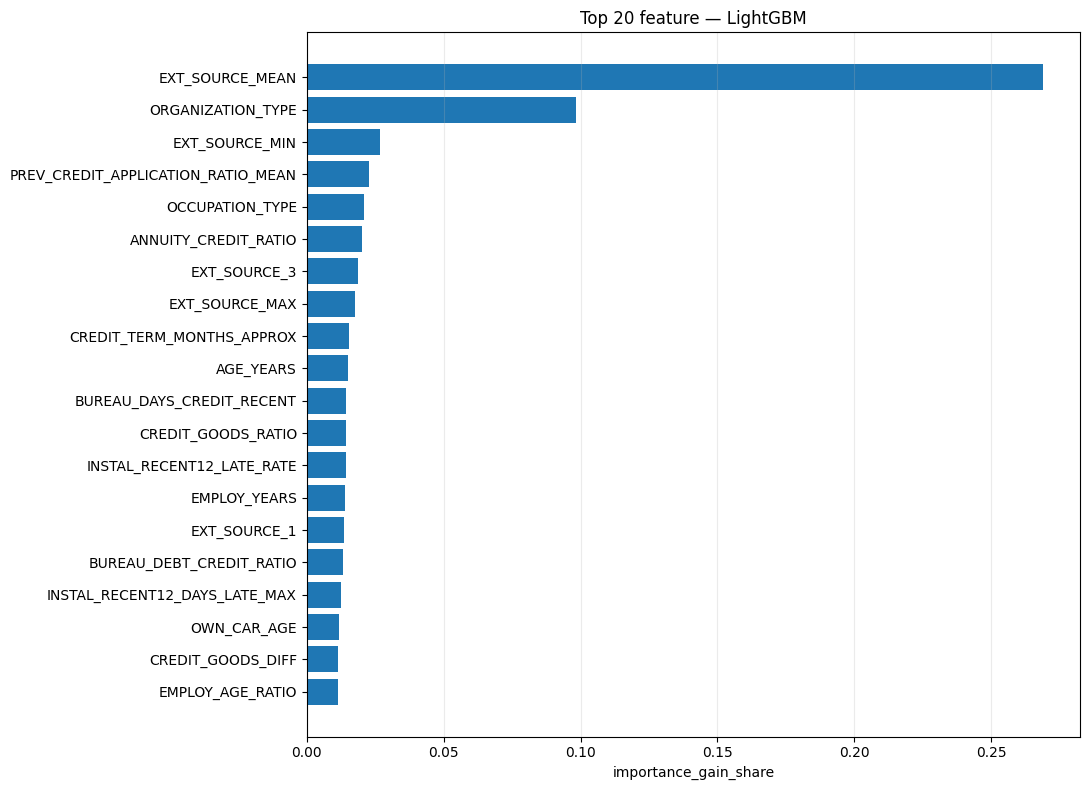

In [ ]:

if final_model_name == 'LightGBM':
    feature_importance = pd.DataFrame({
        'feature': best_lgb.booster_.feature_name(),
        'importance_gain': best_lgb.booster_.feature_importance(importance_type='gain'),
        'importance_split': best_lgb.booster_.feature_importance(importance_type='split'),
    })
    feature_importance['importance_gain_share'] = (
        feature_importance['importance_gain']
        / max(feature_importance['importance_gain'].sum(), 1e-9)
    )
    feature_importance = feature_importance.sort_values(
        'importance_gain', ascending=False
    ).reset_index(drop=True)
else:
    feature_names = lr_pipeline.named_steps['preprocess'].get_feature_names_out()
    coefficients = lr_pipeline.named_steps['model'].coef_[0]
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'absolute_coefficient': np.abs(coefficients),
    }).sort_values('absolute_coefficient', ascending=False).reset_index(drop=True)

print(f'Top feature của mô hình cuối cùng: {final_model_name}')
display(feature_importance.head(25).round(5))

plot_column = (
    'importance_gain_share'
    if 'importance_gain_share' in feature_importance.columns
    else 'absolute_coefficient'
)
plot_data = feature_importance.head(20).sort_values(plot_column)
plt.figure(figsize=(11, 8))
plt.barh(plot_data['feature'], plot_data[plot_column])
plt.xlabel(plot_column)
plt.title(f'Top 20 feature — {final_model_name}')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BOOTSTRAP KHOẢNG TIN CẬY CHO AUC VÀ CHÊNH LỆCH AUC
# ══════════════════════════════════════════════════════════════════════════════

def stratified_bootstrap_indices(y_true, rng):
    y_array = np.asarray(y_true, dtype=int)
    negative_indices = np.flatnonzero(y_array == 0)
    positive_indices = np.flatnonzero(y_array == 1)
    sampled_negative = rng.choice(
        negative_indices, size=len(negative_indices), replace=True
    )
    sampled_positive = rng.choice(
        positive_indices, size=len(positive_indices), replace=True
    )
    sampled = np.concatenate([sampled_negative, sampled_positive])
    rng.shuffle(sampled)
    return sampled


N_BOOTSTRAP = 500
bootstrap_rng = np.random.default_rng(SEED)
y_test_array = np.asarray(y_test, dtype=int)
lr_test_array = np.asarray(lr_proba, dtype=float)
lgb_test_array = np.asarray(lgb_proba, dtype=float)

bootstrap_auc_lr = []
bootstrap_auc_lgb = []
bootstrap_auc_difference = []

for _ in range(N_BOOTSTRAP):
    sampled_indices = stratified_bootstrap_indices(y_test_array, bootstrap_rng)
    sampled_y = y_test_array[sampled_indices]
    auc_lr = roc_auc_score(sampled_y, lr_test_array[sampled_indices])
    auc_lgb = roc_auc_score(sampled_y, lgb_test_array[sampled_indices])
    bootstrap_auc_lr.append(auc_lr)
    bootstrap_auc_lgb.append(auc_lgb)
    bootstrap_auc_difference.append(auc_lgb - auc_lr)


def percentile_interval(values, confidence=0.95):
    alpha = 1 - confidence
    lower, upper = np.quantile(values, [alpha / 2, 1 - alpha / 2])
    return float(lower), float(upper)


lr_auc_ci = percentile_interval(bootstrap_auc_lr)
lgb_auc_ci = percentile_interval(bootstrap_auc_lgb)
auc_difference_ci = percentile_interval(bootstrap_auc_difference)
observed_auc_difference = (
    roc_auc_score(y_test, lgb_test_array)
    - roc_auc_score(y_test, lr_test_array)
)

auc_confidence_table = pd.DataFrame({
    'Mô hình': ['Logistic Regression', 'LightGBM'],
    'AUC quan sát': [
        roc_auc_score(y_test, lr_test_array),
        roc_auc_score(y_test, lgb_test_array),
    ],
    'CI 95% lower': [lr_auc_ci[0], lgb_auc_ci[0]],
    'CI 95% upper': [lr_auc_ci[1], lgb_auc_ci[1]],
})
display(auc_confidence_table.round(4))

print(f'Chênh lệch AUC quan sát (LGBM - LR): {observed_auc_difference:.4f}')
print(
    f'Bootstrap CI 95% cho chênh lệch AUC: '
    f'[{auc_difference_ci[0]:.4f}, {auc_difference_ci[1]:.4f}]'
)
if auc_difference_ci[0] > 0:
    print('Kết luận bootstrap: LightGBM có AUC cao hơn trên tập kiểm tra này.')
else:
    print('Kết luận bootstrap: chưa đủ bằng chứng rằng chênh lệch AUC khác 0.')


,Mô hình,AUC quan sát,CI 95% lower,CI 95% upper
0,Logistic Regression,0.7699,0.7629,0.7775
1,LightGBM,0.7844,0.7782,0.7912


Chênh lệch AUC quan sát (LGBM - LR): 0.0145
Bootstrap CI 95% cho chênh lệch AUC: [0.0116, 0.0173]
Kết luận bootstrap: LightGBM có AUC cao hơn trên tập kiểm tra này.


#### Insight về feature importance và độ chắc chắn của AUC

Các biến có gain share cao nhất gồm:

- `EXT_SOURCE_MEAN`: **26,90%**;
- `ORGANIZATION_TYPE`: **9,84%**;
- `EXT_SOURCE_MIN`: **2,68%**;
- `PREV_CREDIT_APPLICATION_RATIO_MEAN`: **2,26%**;
- `OCCUPATION_TYPE`: **2,10%**;
- `ANNUITY_CREDIT_RATIO`: **2,03%**;
- `EXT_SOURCE_3`: **1,88%**;
- `EXT_SOURCE_MAX`: **1,75%**;
- `CREDIT_TERM_MONTHS_APPROX`: **1,55%**;
- `AGE_YEARS`: **1,52%**.

Mô hình phụ thuộc mạnh vào nhóm `EXT_SOURCE`, nhưng thông tin nghề nghiệp, lịch sử hồ sơ trước, cấu trúc khoản vay, hành vi installment gần đây và dư nợ Bureau cũng đóng góp vào dự báo. Sự tập trung cao vào `EXT_SOURCE_MEAN` là một hạn chế cần theo dõi khi triển khai trên nguồn dữ liệu khác.

Bootstrap 500 lần trên tập test cho kết quả:

- Logistic AUC 95% CI: **[0,7629; 0,7775]**;
- LightGBM AUC 95% CI: **[0,7782; 0,7912]**;
- Chênh lệch AUC LightGBM – Logistic: **0,0145**;
- CI 95% của chênh lệch: **[0,0116; 0,0173]**.

Khoảng tin cậy của chênh lệch không chứa 0, hỗ trợ kết luận LightGBM có AUC cao hơn trên tập kiểm tra này.

##### 2.2.4.2. Đường cong ROC

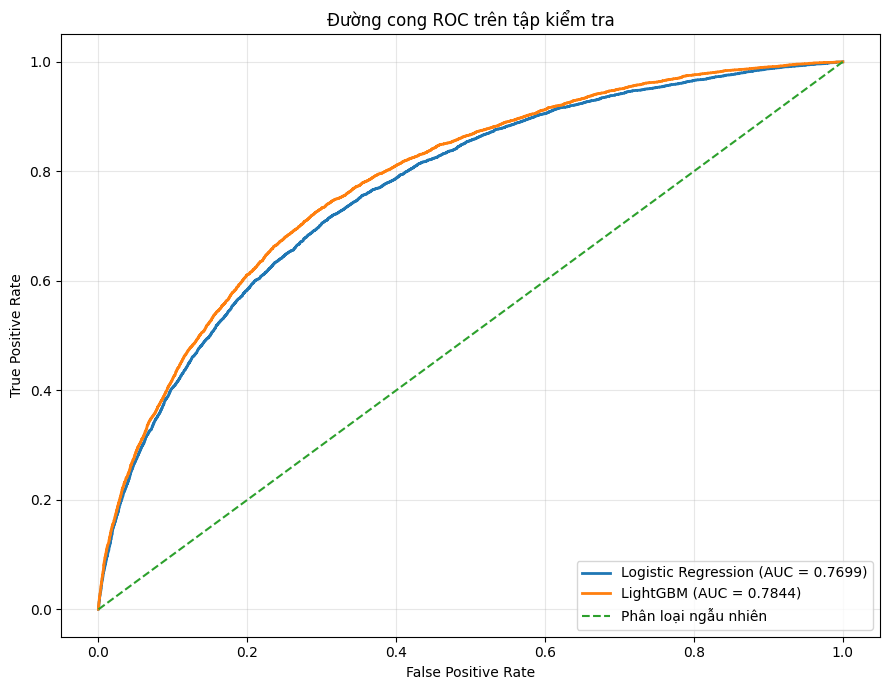

In [ ]:
plt.figure(figsize=(9, 7))

for model_name, probabilities in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    model_auc = roc_auc_score(y_test, probabilities)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {model_auc:.4f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Phân loại ngẫu nhiên'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường cong ROC trên tập kiểm tra')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Insight từ ROC

- Cả hai đường ROC đều nằm rõ phía trên đường ngẫu nhiên.
- LightGBM đạt AUC **0,7844**, cao hơn Logistic **0,7699**.
- Mức cải thiện tuyệt đối là **0,0145**, tương đương **1,45 điểm phần trăm AUC**.
- AUC đo khả năng xếp một khách hàng xấu cao hơn một khách hàng tốt; chỉ tiêu này không xác định threshold vận hành và không phản ánh trực tiếp độ chính xác của PD.

> ROC xác nhận khả năng xếp hạng. Quyết định sử dụng mô hình phải kết hợp Precision–Recall, calibration và chi phí sai lầm.

##### 2.2.4.3. Đường cong Precision–Recall

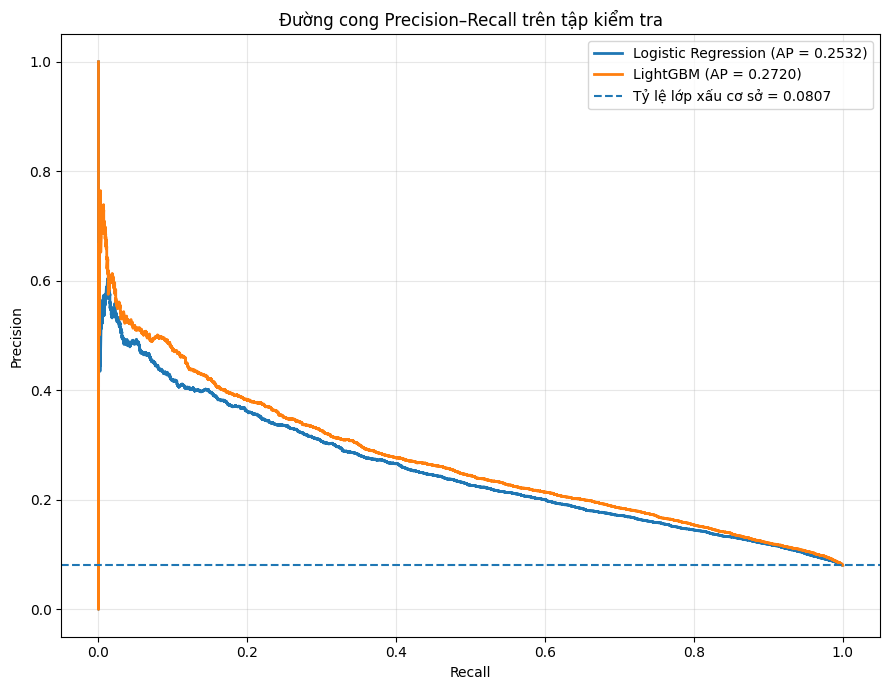

In [ ]:
plt.figure(figsize=(9, 7))

for model_name, probabilities in test_probabilities.items():
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        probabilities
    )
    average_precision = average_precision_score(y_test, probabilities)

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f'{model_name} (AP = {average_precision:.4f})'
    )

base_rate = y_test.mean()
plt.axhline(
    base_rate,
    linestyle='--',
    linewidth=1.5,
    label=f'Tỷ lệ lớp xấu cơ sở = {base_rate:.4f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Đường cong Precision–Recall trên tập kiểm tra')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Insight từ Precision–Recall

- Bad rate nền trên test là **8,07%**.
- Average Precision của Logistic là **0,2532**; LightGBM là **0,2720**.
- Tương ứng, AP cao gấp **3,14 lần** và **3,37 lần** tỷ lệ lớp xấu cơ sở.
- Precision giảm khi yêu cầu Recall cao hơn, phản ánh đánh đổi khó tránh trong bài toán lớp dương hiếm.

> Đường PR cho thấy mô hình có giá trị trong việc ưu tiên hồ sơ. Tuy nhiên, tăng độ bao phủ khách hàng xấu sẽ kéo theo nhiều false positive; điểm vận hành cần gắn với năng lực thẩm định và chi phí.

##### 2.2.4.4. So sánh AUC và GINI

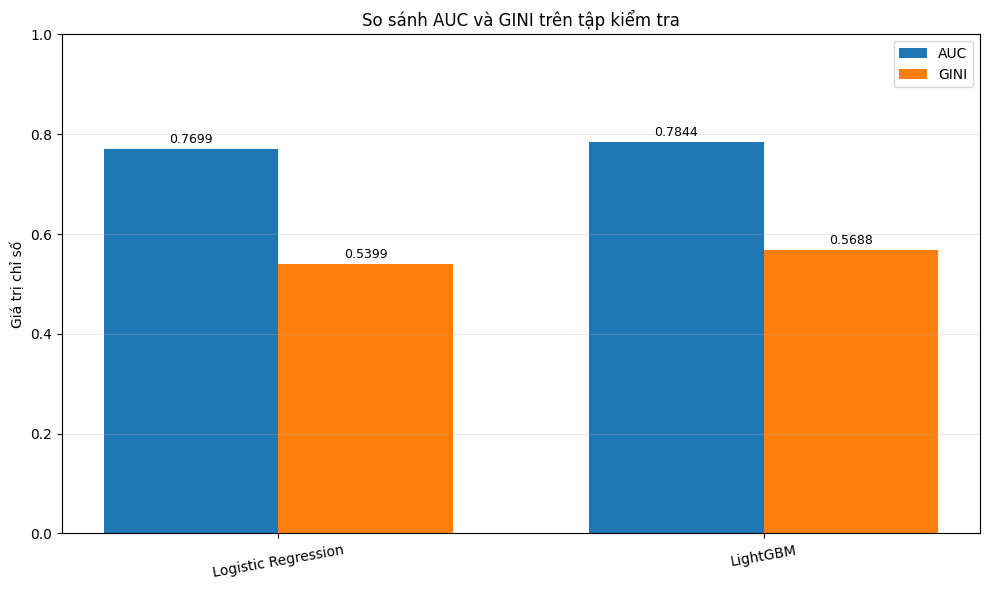

,Mô hình,AUC,GINI
0,Logistic Regression,0.7699,0.5399
1,LightGBM,0.7844,0.5688


In [ ]:
model_metrics_plot = pd.DataFrame({
    'Mô hình': list(test_probabilities.keys()),
    'AUC': [
        roc_auc_score(y_test, probabilities)
        for probabilities in test_probabilities.values()
    ],
})

model_metrics_plot['GINI'] = 2 * model_metrics_plot['AUC'] - 1

x_positions = np.arange(len(model_metrics_plot))
bar_width = 0.36

plt.figure(figsize=(10, 6))
plt.bar(
    x_positions - bar_width / 2,
    model_metrics_plot['AUC'],
    width=bar_width,
    label='AUC'
)
plt.bar(
    x_positions + bar_width / 2,
    model_metrics_plot['GINI'],
    width=bar_width,
    label='GINI'
)

for index, value in enumerate(model_metrics_plot['AUC']):
    plt.text(
        index - bar_width / 2,
        value + 0.012,
        f'{value:.4f}',
        ha='center',
        fontsize=9
    )

for index, value in enumerate(model_metrics_plot['GINI']):
    plt.text(
        index + bar_width / 2,
        value + 0.012,
        f'{value:.4f}',
        ha='center',
        fontsize=9
    )

plt.xticks(x_positions, model_metrics_plot['Mô hình'], rotation=10)
plt.ylim(0, 1)
plt.ylabel('Giá trị chỉ số')
plt.title('So sánh AUC và GINI trên tập kiểm tra')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(model_metrics_plot.round(4))

#### Insight từ AUC và GINI

- Logistic Regression: AUC **0,7699**, GINI **0,5399**.
- LightGBM: AUC **0,7844**, GINI **0,5688**.
- Do `GINI = 2 × AUC − 1`, hai chỉ tiêu đưa ra cùng thứ hạng mô hình.
- GINI 0,5688 cho thấy khả năng phân biệt tương đối tốt trong phạm vi dữ liệu, nhưng không đủ để dùng như bằng chứng duy nhất cho tự động hóa tín dụng.

> Kết luận mô hình phải dựa đồng thời trên discrimination, calibration, tính đơn điệu theo decile/grade và hiệu quả tại threshold.

#### 2.2.5. Hiệu chỉnh xác suất và lựa chọn threshold

- Mô hình cuối được chọn bằng CV trên train.
- Platt Scaling được fit **chỉ trên calibration set 10%**.
- Threshold tối đa F1 được chọn **chỉ trên threshold set 10%** bằng PD đã hiệu chỉnh.
- Test không tham gia fit mô hình, calibration hoặc lựa chọn threshold.
- Hệ số dốc của Platt scaler được ràng buộc dương để giữ nguyên thứ tự rủi ro.

Kết quả trên test:

| Phiên bản xác suất | AUC | Brier Score | Log Loss | PD trung bình |
|---|---:|---:|---:|---:|
| LightGBM thô | 0,7844 | 0,0831 | 0,2917 | 18,78% |
| Sau Platt Scaling | 0,7844 | **0,0663** | **0,2382** | **8,07%** |
| Bad rate thực tế |  |  |  | 8,07% |

Do cấu hình tốt nhất sử dụng `scale_pos_weight = 3,3745`, xác suất thô bị đẩy cao hơn tỷ lệ rủi ro thực tế. Platt Scaling với `slope = 0,9791` và `intercept = -1,1389` đưa PD trung bình từ **18,78%** về **8,07%**, đồng thời cải thiện Brier Score và Log Loss. AUC giữ nguyên vì phép hiệu chỉnh đơn điệu không làm thay đổi thứ tự xếp hạng.

> Đây là bước cần thiết trước khi sử dụng đầu ra như PD, phân hạng rủi ro hoặc tính phơi nhiễm có trọng số PD.

Platt slope (phải > 0): 0.979065
Platt intercept        : -1.138862


,Phiên bản xác suất,AUC,Brier Score,Log Loss,PD trung bình,Bad rate thực tế
0,LightGBM thô,0.7844,0.0831,0.2917,0.1878,0.0807
1,LightGBM sau Platt Scaling,0.7844,0.0663,0.2382,0.0807,0.0807


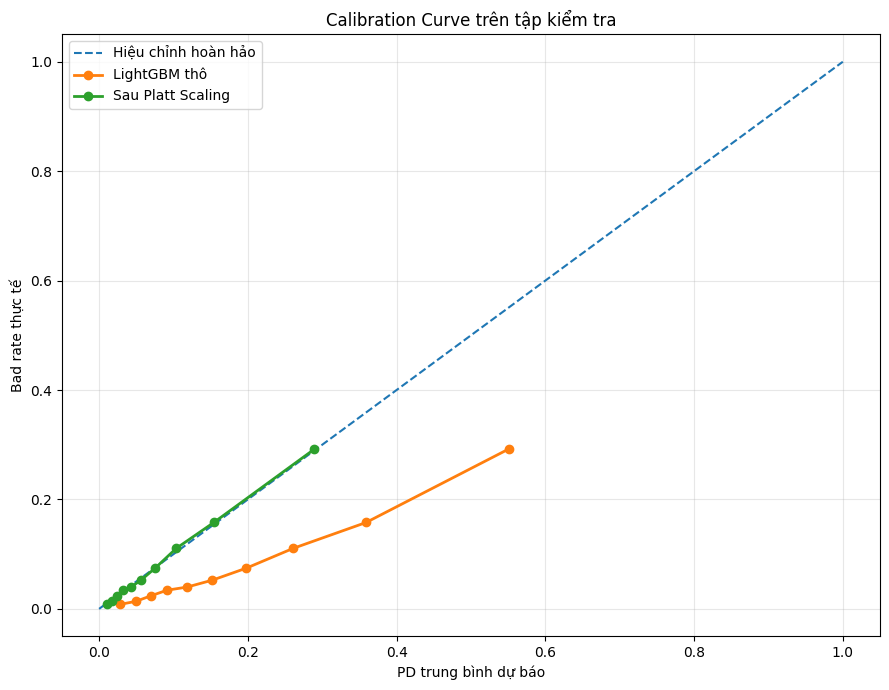

Threshold F1 trên tập threshold riêng : 0.1872
F1 trên tập threshold tại ngưỡng      : 0.3454
Tập test không tham gia fit calibration hoặc chọn threshold.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2.5 — CALIBRATION VÀ CHỌN THRESHOLD TRÊN HAI TẬP RIÊNG
# ══════════════════════════════════════════════════════════════════════════════


def probability_logit(probability, epsilon=1e-6):
    probability = np.clip(np.asarray(probability, dtype=float), epsilon, 1 - epsilon)
    return np.log(probability / (1 - probability))


class MonotonicPlattScaler:
    """Platt scaling với hệ số dốc bị chặn dương để giữ nguyên thứ tự rủi ro."""

    def fit(self, raw_probability, target):
        x = probability_logit(raw_probability)
        y_array = np.asarray(target, dtype=float)
        prevalence = np.clip(y_array.mean(), 1e-6, 1 - 1e-6)
        initial_intercept = np.log(prevalence / (1 - prevalence)) - np.mean(x)

        def objective(parameters):
            slope, intercept = parameters
            calibrated = np.clip(expit(slope * x + intercept), 1e-9, 1 - 1e-9)
            return -np.mean(
                y_array * np.log(calibrated)
                + (1 - y_array) * np.log(1 - calibrated)
            )

        result = minimize(
            objective,
            x0=np.array([1.0, initial_intercept], dtype=float),
            method='L-BFGS-B',
            bounds=[(1e-6, None), (None, None)],
        )
        if not result.success:
            raise RuntimeError(f'Platt calibration không hội tụ: {result.message}')
        self.slope_ = float(result.x[0])
        self.intercept_ = float(result.x[1])
        return self

    def predict(self, raw_probability):
        x = probability_logit(raw_probability)
        return expit(self.slope_ * x + self.intercept_)


# Fit calibration chỉ trên tập calibration 10%.
platt_scaler = MonotonicPlattScaler().fit(final_calib_proba, y_calib)
calibrated_valid_proba = platt_scaler.predict(final_valid_proba)
calibrated_test_proba = platt_scaler.predict(final_test_proba)

print(f'Platt slope (phải > 0): {platt_scaler.slope_:.6f}')
print(f'Platt intercept        : {platt_scaler.intercept_:.6f}')

calibration_metrics = pd.DataFrame([
    {
        'Phiên bản xác suất': f'{final_model_name} thô',
        'AUC': roc_auc_score(y_test, final_test_proba),
        'Brier Score': brier_score_loss(y_test, final_test_proba),
        'Log Loss': log_loss(y_test, final_test_proba),
        'PD trung bình': np.mean(final_test_proba),
        'Bad rate thực tế': np.mean(y_test),
    },
    {
        'Phiên bản xác suất': f'{final_model_name} sau Platt Scaling',
        'AUC': roc_auc_score(y_test, calibrated_test_proba),
        'Brier Score': brier_score_loss(y_test, calibrated_test_proba),
        'Log Loss': log_loss(y_test, calibrated_test_proba),
        'PD trung bình': np.mean(calibrated_test_proba),
        'Bad rate thực tế': np.mean(y_test),
    },
])
display(calibration_metrics.round(4))

raw_fraction_positive, raw_mean_predicted = calibration_curve(
    y_test, final_test_proba, n_bins=10, strategy='quantile'
)
cal_fraction_positive, cal_mean_predicted = calibration_curve(
    y_test, calibrated_test_proba, n_bins=10, strategy='quantile'
)

plt.figure(figsize=(9, 7))
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5, label='Hiệu chỉnh hoàn hảo')
plt.plot(
    raw_mean_predicted, raw_fraction_positive,
    marker='o', linewidth=2, label=f'{final_model_name} thô'
)
plt.plot(
    cal_mean_predicted, cal_fraction_positive,
    marker='o', linewidth=2, label='Sau Platt Scaling'
)
plt.xlabel('PD trung bình dự báo')
plt.ylabel('Bad rate thực tế')
plt.title('Calibration Curve trên tập kiểm tra')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Threshold chỉ được chọn trên tập threshold 10%, sau khi calibration.
validation_precision, validation_recall, validation_thresholds = precision_recall_curve(
    y_valid, calibrated_valid_proba
)
validation_f1 = (
    2 * validation_precision[:-1] * validation_recall[:-1]
    / (validation_precision[:-1] + validation_recall[:-1] + 1e-9)
)
best_threshold_index = int(np.nanargmax(validation_f1))
best_thresh = float(validation_thresholds[best_threshold_index])
y_pred_final = (calibrated_test_proba >= best_thresh).astype(int)

print(f'Threshold F1 trên tập threshold riêng : {best_thresh:.4f}')
print(f'F1 trên tập threshold tại ngưỡng      : {validation_f1[best_threshold_index]:.4f}')
print('Tập test không tham gia fit calibration hoặc chọn threshold.')

portfolio_pd = calibrated_test_proba


#### 2.2.6. Ma trận nhầm lẫn tại ngưỡng F1

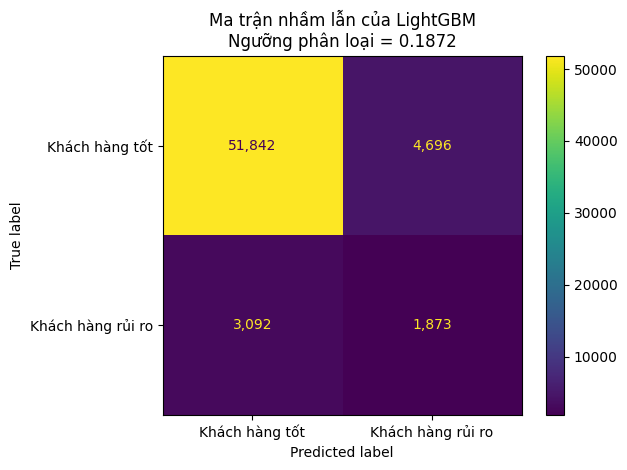

Classification report của LightGBM trên tập kiểm tra:
                   precision    recall  f1-score   support

   Khách hàng tốt     0.9437    0.9169    0.9301     56538
Khách hàng rủi ro     0.2851    0.3772    0.3248      4965

         accuracy                         0.8734     61503
        macro avg     0.6144    0.6471    0.6275     61503
     weighted avg     0.8905    0.8734    0.8813     61503



In [ ]:
final_confusion_matrix = confusion_matrix(y_test, y_pred_final)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=['Khách hàng tốt', 'Khách hàng rủi ro']
)

display_object.plot(values_format=',d')
plt.title(
    f'Ma trận nhầm lẫn của {final_model_name}\n'
    f'Ngưỡng phân loại = {best_thresh:.4f}'
)
plt.tight_layout()
plt.show()

print(f'Classification report của {final_model_name} trên tập kiểm tra:')
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=['Khách hàng tốt', 'Khách hàng rủi ro'],
        digits=4
    )
)


#### Insight từ ma trận nhầm lẫn

Với threshold **0,1872** trên PD đã hiệu chỉnh, kết quả test là:

- Accuracy: **87,34%**.
- Precision lớp rủi ro: **28,51%**.
- Recall lớp rủi ro: **37,72%**.
- F1 lớp rủi ro: **32,48%**.

Mô hình phát hiện khoảng 37,72% trường hợp xấu tại điểm F1 và phần lớn cảnh báo dương vẫn là false positive. Điều này không mâu thuẫn với AUC khá: AUC đánh giá thứ tự trên mọi ngưỡng, trong khi ma trận nhầm lẫn chỉ phản ánh một điểm vận hành cụ thể.

> Không sử dụng threshold 0,1872 như cut-off phê duyệt. Chính sách thực tế cần chi phí false negative/false positive, LGD, EAD, lợi nhuận kỳ vọng và khẩu vị rủi ro.

#### 2.2.7. Precision, Recall và F1 theo threshold

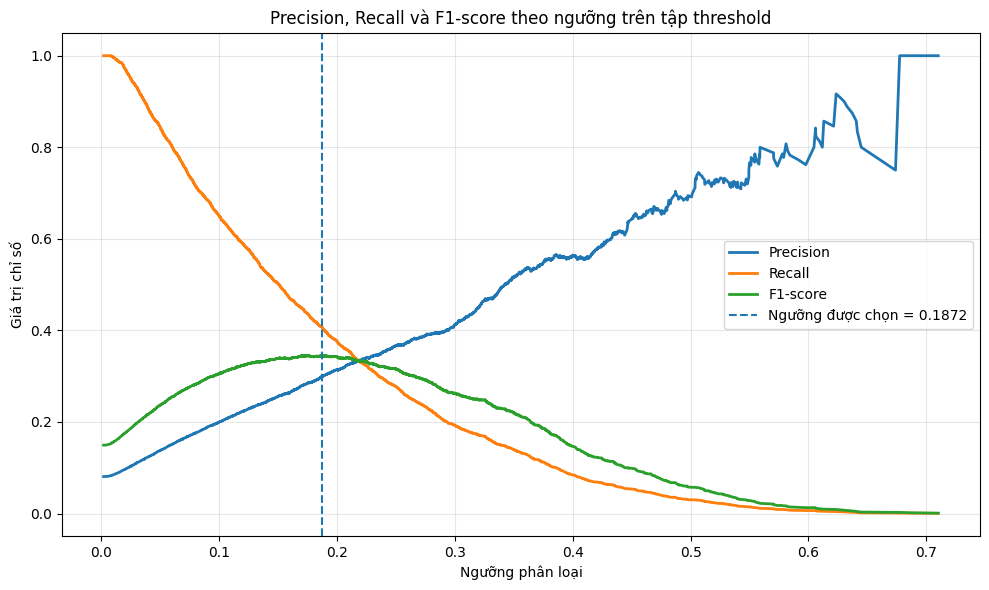

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(
    validation_thresholds,
    validation_precision[:-1],
    label='Precision',
    linewidth=2
)
plt.plot(
    validation_thresholds,
    validation_recall[:-1],
    label='Recall',
    linewidth=2
)
plt.plot(
    validation_thresholds,
    validation_f1,
    label='F1-score',
    linewidth=2
)
plt.axvline(
    best_thresh,
    linestyle='--',
    linewidth=1.5,
    label=f'Ngưỡng được chọn = {best_thresh:.4f}'
)

plt.xlabel('Ngưỡng phân loại')
plt.ylabel('Giá trị chỉ số')
plt.title('Precision, Recall và F1-score theo ngưỡng trên tập threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Insight về lựa chọn threshold

- Threshold tối đa F1 trên tập threshold riêng là **0,1872**.
- F1 đạt được trên threshold set là **0,3454**.
- Khi áp dụng cùng ngưỡng lên test, F1 lớp xấu là **0,3248**.
- Khi tăng threshold, Precision thường tăng nhưng Recall giảm; khi giảm threshold, số khách hàng xấu được phát hiện tăng cùng với số cảnh báo sai.
- Chênh lệch giữa F1 trên threshold set và test cho thấy hiệu năng tại một ngưỡng có thể suy giảm trên mẫu chưa thấy.

> F1 coi Precision và Recall quan trọng ngang nhau; đây chỉ là minh họa kỹ thuật, không phải hàm mục tiêu kinh tế của hoạt động tín dụng.

---

#### 2.2.8. Đánh giá khả năng phân tầng bằng KS, Decile và Lift

Phần này kiểm tra mô hình có tập trung phần lớn khách hàng xấu vào vùng PD cao hay không. Đây là góc nhìn phù hợp với quản trị danh mục và phân bổ nguồn lực hơn việc chỉ sử dụng một quyết định nhị phân.

KS Statistic                 : 0.4338
Vị trí phân tách theo dân số : 32.67%
Bad capture tại điểm KS      : 72.55%


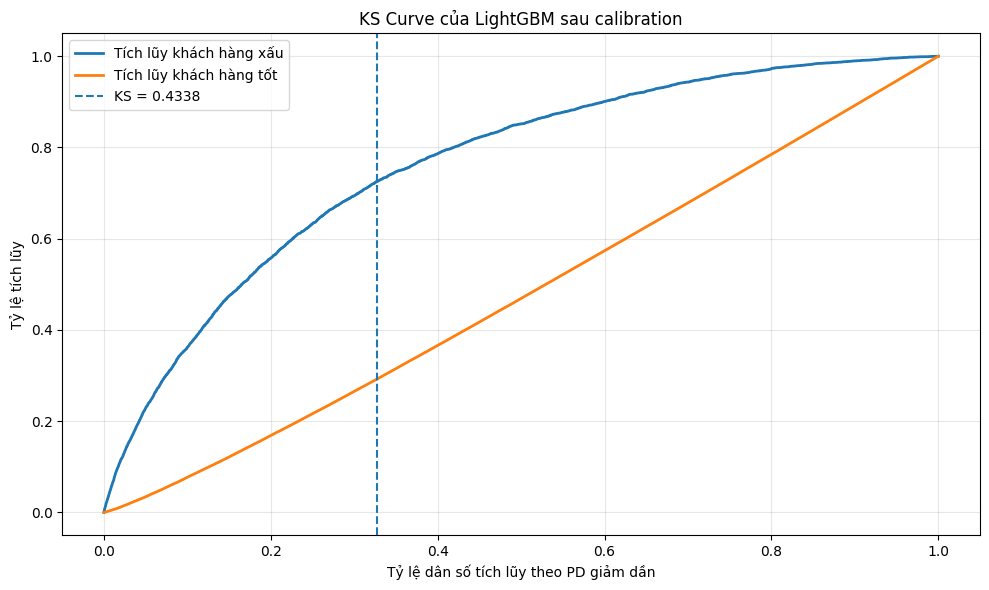

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2.8 — KS CURVE
# ══════════════════════════════════════════════════════════════════════════════

def create_ks_table(y_true, probability):
    frame = pd.DataFrame({
        'actual_target': np.asarray(y_true, dtype=int),
        'pd': np.asarray(probability, dtype=float),
    }).sort_values('pd', ascending=False).reset_index(drop=True)

    total_bad = max(frame['actual_target'].sum(), 1)
    total_good = max((1 - frame['actual_target']).sum(), 1)

    frame['cum_bad_rate'] = frame['actual_target'].cumsum() / total_bad
    frame['cum_good_rate'] = (1 - frame['actual_target']).cumsum() / total_good
    frame['ks'] = (frame['cum_bad_rate'] - frame['cum_good_rate']).abs()
    frame['population_share'] = (np.arange(len(frame)) + 1) / len(frame)
    return frame


ks_table = create_ks_table(y_test, portfolio_pd)
ks_position = int(ks_table['ks'].idxmax())
ks_statistic = float(ks_table.loc[ks_position, 'ks'])
ks_population_share = float(ks_table.loc[ks_position, 'population_share'])
ks_bad_capture = float(ks_table.loc[ks_position, 'cum_bad_rate'])

print(f'KS Statistic                 : {ks_statistic:.4f}')
print(f'Vị trí phân tách theo dân số : {ks_population_share:.2%}')
print(f'Bad capture tại điểm KS      : {ks_bad_capture:.2%}')

plt.figure(figsize=(10, 6))
plt.plot(
    ks_table['population_share'],
    ks_table['cum_bad_rate'],
    linewidth=2,
    label='Tích lũy khách hàng xấu'
)
plt.plot(
    ks_table['population_share'],
    ks_table['cum_good_rate'],
    linewidth=2,
    label='Tích lũy khách hàng tốt'
)
plt.axvline(
    ks_population_share,
    linestyle='--',
    linewidth=1.5,
    label=f'KS = {ks_statistic:.4f}'
)
plt.xlabel('Tỷ lệ dân số tích lũy theo PD giảm dần')
plt.ylabel('Tỷ lệ tích lũy')
plt.title(f'KS Curve của {final_model_name} sau calibration')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


,number_of_customers,number_of_bad,average_pd,min_pd,max_pd,observed_bad_rate,customer_share,bad_capture,cumulative_bad_capture,lift
risk_decile,,,,,,,,,,
1,6151,1796,0.2895,0.1934,0.7261,0.2920,0.1000,0.3617,0.3617,3.6169
2,6150,971,0.1542,0.1234,0.1934,0.1579,0.1000,0.1956,0.5573,1.9558
3,6150,680,0.1037,0.0877,0.1234,0.1106,0.1000,0.1370,0.6943,1.3697
4,6150,458,0.0754,0.0646,0.0877,0.0745,0.1000,0.0922,0.7865,0.9225
5,6151,323,0.0563,0.0489,0.0646,0.0525,0.1000,0.0651,0.8516,0.6505
6,6150,245,0.0429,0.0373,0.0489,0.0398,0.1000,0.0493,0.9009,0.4935
7,6150,210,0.0327,0.0284,0.0373,0.0341,0.1000,0.0423,0.9432,0.4230
8,6150,146,0.0246,0.0210,0.0284,0.0237,0.1000,0.0294,0.9726,0.2941
9,6150,85,0.0175,0.0140,0.0210,0.0138,0.1000,0.0171,0.9897,0.1712


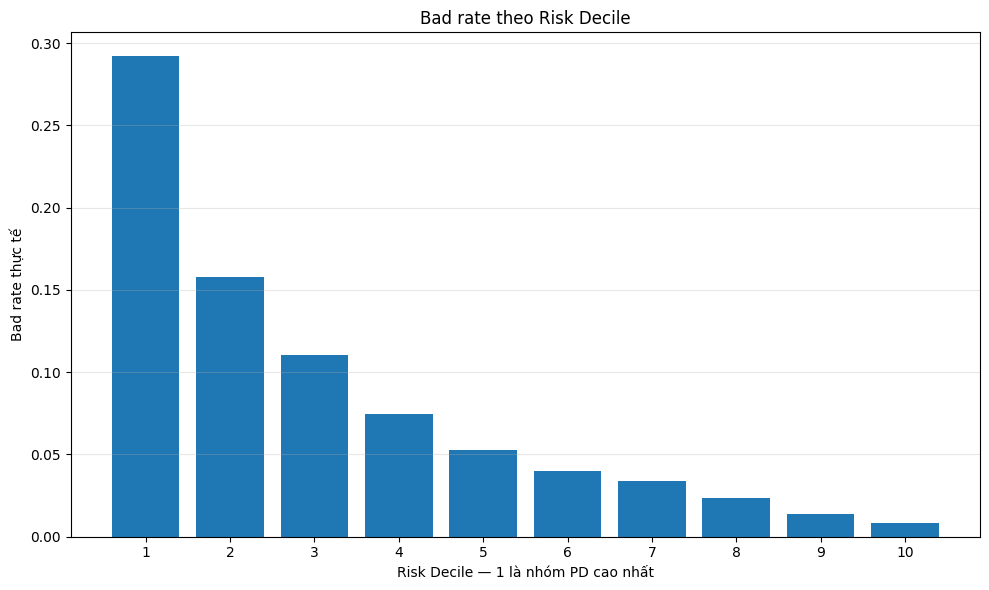

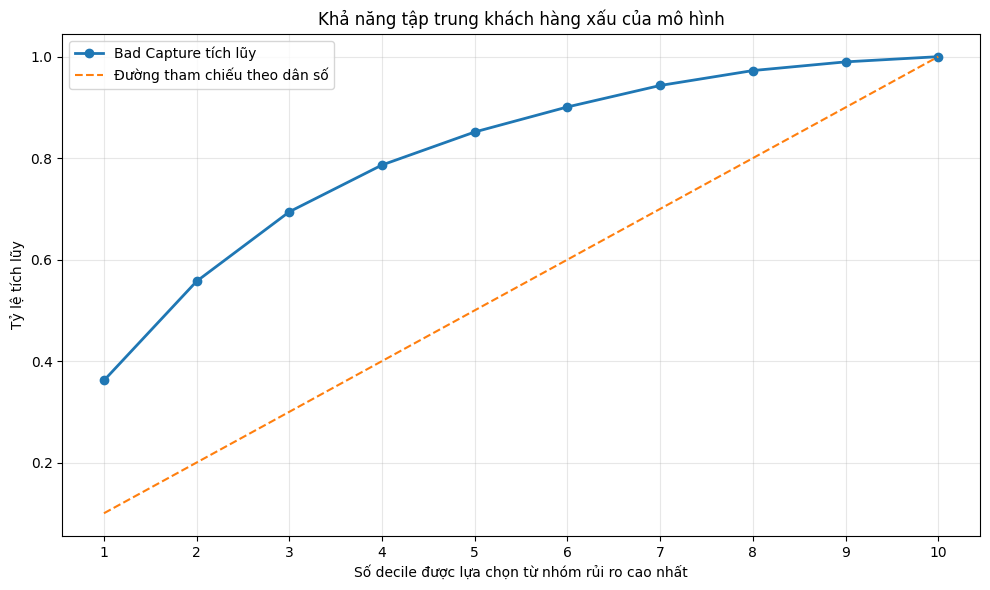

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2.8 — DECILE, LIFT VÀ BAD CAPTURE
# ══════════════════════════════════════════════════════════════════════════════

def create_decile_table(y_true, probability, number_of_deciles=10):
    frame = pd.DataFrame({
        'actual_target': np.asarray(y_true, dtype=int),
        'pd': np.asarray(probability, dtype=float),
    })

    # Rank trước qcut để xử lý trường hợp nhiều xác suất trùng nhau.
    descending_rank = frame['pd'].rank(method='first', ascending=False)
    frame['risk_decile'] = pd.qcut(
        descending_rank,
        q=number_of_deciles,
        labels=range(1, number_of_deciles + 1)
    ).astype(int)

    summary = frame.groupby('risk_decile').agg(
        number_of_customers=('actual_target', 'size'),
        number_of_bad=('actual_target', 'sum'),
        average_pd=('pd', 'mean'),
        min_pd=('pd', 'min'),
        max_pd=('pd', 'max'),
        observed_bad_rate=('actual_target', 'mean'),
    ).sort_index()

    portfolio_bad_rate = frame['actual_target'].mean()
    total_bad = max(frame['actual_target'].sum(), 1)

    summary['customer_share'] = summary['number_of_customers'] / len(frame)
    summary['bad_capture'] = summary['number_of_bad'] / total_bad
    summary['cumulative_bad_capture'] = summary['bad_capture'].cumsum()
    summary['lift'] = summary['observed_bad_rate'] / max(portfolio_bad_rate, 1e-9)
    return summary


decile_table = create_decile_table(y_test, portfolio_pd)
display(decile_table.round(4))

plt.figure(figsize=(10, 6))
plt.bar(decile_table.index.astype(str), decile_table['observed_bad_rate'])
plt.xlabel('Risk Decile — 1 là nhóm PD cao nhất')
plt.ylabel('Bad rate thực tế')
plt.title('Bad rate theo Risk Decile')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    decile_table.index,
    decile_table['cumulative_bad_capture'],
    marker='o',
    linewidth=2,
    label='Bad Capture tích lũy'
)
plt.plot(
    decile_table.index,
    decile_table['customer_share'].cumsum(),
    linestyle='--',
    linewidth=1.5,
    label='Đường tham chiếu theo dân số'
)
plt.xticks(decile_table.index)
plt.xlabel('Số decile được lựa chọn từ nhóm rủi ro cao nhất')
plt.ylabel('Tỷ lệ tích lũy')
plt.title('Khả năng tập trung khách hàng xấu của mô hình')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Insight từ KS, Decile và Lift

- KS đạt **0,4338**.
- Điểm KS xuất hiện tại **32,67%** dân số có PD cao nhất và tập trung **72,55%** khách hàng xấu.
- Decile 1 có bad rate **29,20%**, lift **3,6169** và chứa **36,17%** tổng số khách hàng xấu.
- Top 20% chứa **55,73%**; top 30% chứa **69,43%** khách hàng xấu.
- Bad rate giảm đơn điệu từ **29,20%** ở decile 1 xuống **0,83%** ở decile 10; PD trung bình giảm từ **28,95%** xuống **1,00%**.

Kết quả cho thấy mô hình có khả năng tập trung rủi ro rõ ràng. Giá trị thực tiễn nổi bật nằm ở ưu tiên thẩm định hoặc giám sát nhóm PD cao, không phải dự báo hoàn hảo trạng thái từng cá nhân.

#### 2.2.9. Chuyển PD thành điểm rủi ro

PD đã hiệu chỉnh được chuyển thành điểm bằng phép biến đổi đơn điệu:

$$
Score = Offset + Factor \times \ln\left(\frac{1-PD}{PD}\right)
$$

Quy ước minh họa:

- Base Score = **600**;
- Base Odds tốt/xấu = **50:1**;
- PDO = **20**;
- giới hạn điểm từ 300 đến 850.

PD thấp tương ứng với điểm cao. Việc chuyển đổi không tạo thêm sức mạnh dự báo mà chỉ giúp diễn giải và truyền đạt kết quả thuận tiện hơn.

,number_of_customers,average_score,median_score,average_pd
Khách hàng tốt,56538,573.4300,575.1800,0.0700
Khách hàng rủi ro,4965,540.3300,539.0800,0.1800


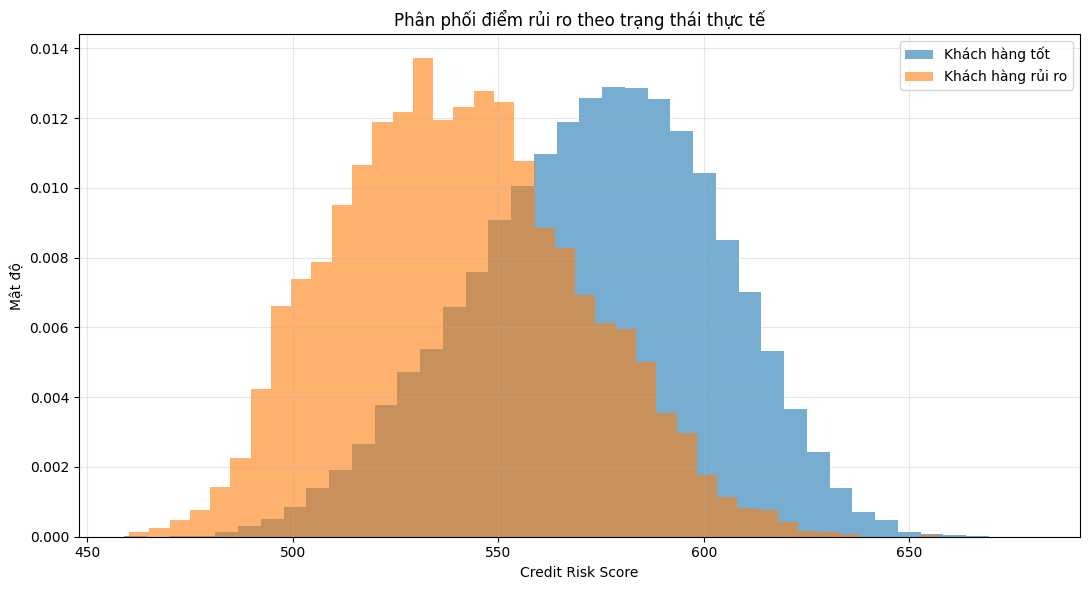

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2.9 — CHUYỂN PD THÀNH ĐIỂM RỦI RO
# ══════════════════════════════════════════════════════════════════════════════

BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20
SCORE_MIN = 300
SCORE_MAX = 850

score_factor = PDO / np.log(2)
score_offset = BASE_SCORE - score_factor * np.log(BASE_ODDS)


def probability_to_score(probability):
    probability = np.clip(np.asarray(probability, dtype=float), 1e-6, 1 - 1e-6)
    good_bad_odds = (1 - probability) / probability
    score = score_offset + score_factor * np.log(good_bad_odds)
    return np.clip(score, SCORE_MIN, SCORE_MAX)


portfolio_scoring = pd.DataFrame(index=y_test.index)
portfolio_scoring['actual_target'] = y_test.astype(int)
portfolio_scoring['pd_raw'] = np.asarray(final_test_proba)
portfolio_scoring['pd_calibrated'] = portfolio_pd
portfolio_scoring['credit_score'] = probability_to_score(portfolio_pd)

if 'SK_ID_CURR' in df_master.columns:
    portfolio_scoring['SK_ID_CURR'] = df_master.loc[y_test.index, 'SK_ID_CURR']

if 'AMT_CREDIT' in df_master.columns:
    portfolio_scoring['credit_exposure'] = df_master.loc[y_test.index, 'AMT_CREDIT']
    portfolio_scoring['pd_weighted_exposure'] = (
        portfolio_scoring['credit_exposure']
        * portfolio_scoring['pd_calibrated']
    )

score_summary = portfolio_scoring.groupby('actual_target').agg(
    number_of_customers=('credit_score', 'size'),
    average_score=('credit_score', 'mean'),
    median_score=('credit_score', 'median'),
    average_pd=('pd_calibrated', 'mean'),
)
score_summary.index = ['Khách hàng tốt', 'Khách hàng rủi ro']
display(score_summary.round(2))

plt.figure(figsize=(11, 6))
plt.hist(
    portfolio_scoring.loc[portfolio_scoring['actual_target'] == 0, 'credit_score'],
    bins=40,
    alpha=0.6,
    density=True,
    label='Khách hàng tốt'
)
plt.hist(
    portfolio_scoring.loc[portfolio_scoring['actual_target'] == 1, 'credit_score'],
    bins=40,
    alpha=0.6,
    density=True,
    label='Khách hàng rủi ro'
)
plt.xlabel('Credit Risk Score')
plt.ylabel('Mật độ')
plt.title('Phân phối điểm rủi ro theo trạng thái thực tế')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Insight từ phân phối điểm

- Khách hàng tốt có điểm trung bình **573,43**, trung vị **575,18**.
- Khách hàng rủi ro có điểm trung bình **540,33**, trung vị **539,08**.
- Chênh lệch điểm trung bình giữa hai nhóm là **33,10 điểm**.
- PD trung bình của nhóm tốt và nhóm rủi ro lần lượt khoảng **7%** và **18%**.

Hai phân phối vẫn chồng lấn đáng kể, vì vậy điểm không thể xác định chắc chắn trạng thái của từng khách hàng. Cách sử dụng phù hợp là xếp thứ tự rủi ro, thiết lập tầng giám sát và hỗ trợ giao tiếp kết quả mô hình.

#### 2.2.10. Phân hạng rủi ro danh mục

PD đã hiệu chỉnh được chia thành năm hạng minh họa:

| Hạng | Khoảng PD | Mức rủi ro |
|---|---:|---|
| A | PD ≤ 3% | Rất thấp |
| B | 3% < PD ≤ 6% | Thấp |
| C | 6% < PD ≤ 10% | Trung bình |
| D | 10% < PD ≤ 20% | Cao |
| E | PD > 20% | Rất cao |

Các ngưỡng này phục vụ phân tích đồ án và chưa phải chuẩn chính thức của một ngân hàng. Khi triển khai thực tế, ngưỡng cần được tái hiệu chỉnh theo bad rate mục tiêu, khẩu vị rủi ro, sản phẩm và chu kỳ kinh tế.

,number_of_customers,customer_share,number_of_bad,observed_bad_rate,average_pd,average_score,total_credit_exposure,exposure_share,pd_weighted_exposure
risk_grade,,,,,,,,,
A — Rất thấp,19668,0.3198,315,0.0160,0.0181,604.8567,12598670866.5000,0.3415,226988467.5083
B — Thấp,15623,0.2540,652,0.0417,0.0432,577.0460,9573007806.0000,0.2595,413662889.0175
C — Trung bình,10317,0.1677,792,0.0768,0.0778,558.7720,6067505470.5000,0.1645,471859851.6513
D — Cao,10129,0.1647,1471,0.1452,0.1405,539.9505,5696953569.0000,0.1544,797848086.2762
E — Rất cao,5766,0.0938,1735,0.3009,0.2957,512.9615,2951959099.5000,0.0800,869655233.9323


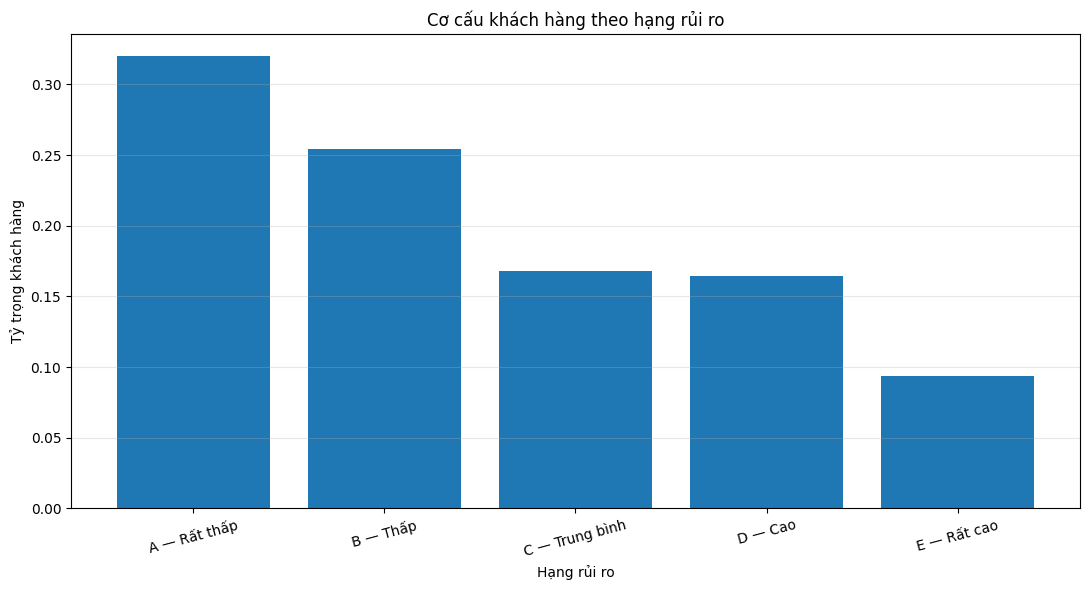

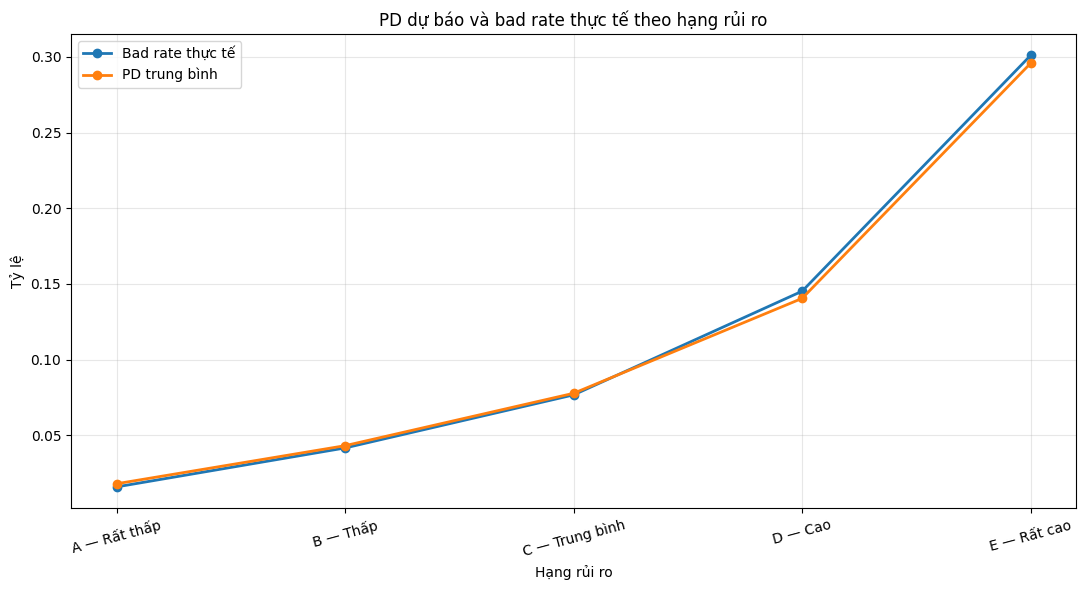

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2.10 — RISK GRADE VÀ TỔNG HỢP RỦI RO DANH MỤC
# ══════════════════════════════════════════════════════════════════════════════

risk_grade_labels = ['A — Rất thấp', 'B — Thấp', 'C — Trung bình', 'D — Cao', 'E — Rất cao']
portfolio_scoring['risk_grade'] = pd.cut(
    portfolio_scoring['pd_calibrated'],
    bins=[-np.inf, 0.03, 0.06, 0.10, 0.20, np.inf],
    labels=risk_grade_labels,
    ordered=True
)

aggregation_spec = {
    'number_of_customers': ('actual_target', 'size'),
    'number_of_bad': ('actual_target', 'sum'),
    'observed_bad_rate': ('actual_target', 'mean'),
    'average_pd': ('pd_calibrated', 'mean'),
    'average_score': ('credit_score', 'mean'),
}

if 'credit_exposure' in portfolio_scoring.columns:
    aggregation_spec.update({
        'total_credit_exposure': ('credit_exposure', 'sum'),
        'pd_weighted_exposure': ('pd_weighted_exposure', 'sum'),
    })

risk_grade_summary = portfolio_scoring.groupby(
    'risk_grade',
    observed=False
).agg(**aggregation_spec)

risk_grade_summary['customer_share'] = (
    risk_grade_summary['number_of_customers']
    / risk_grade_summary['number_of_customers'].sum()
)

if 'total_credit_exposure' in risk_grade_summary.columns:
    risk_grade_summary['exposure_share'] = (
        risk_grade_summary['total_credit_exposure']
        / risk_grade_summary['total_credit_exposure'].sum()
    )

# Sắp xếp cột theo hướng thuận tiện cho báo cáo.
ordered_columns = [
    'number_of_customers',
    'customer_share',
    'number_of_bad',
    'observed_bad_rate',
    'average_pd',
    'average_score',
]
if 'total_credit_exposure' in risk_grade_summary.columns:
    ordered_columns += [
        'total_credit_exposure',
        'exposure_share',
        'pd_weighted_exposure',
    ]

risk_grade_summary = risk_grade_summary[ordered_columns]
display(risk_grade_summary.round(4))

plt.figure(figsize=(11, 6))
plt.bar(
    risk_grade_summary.index.astype(str),
    risk_grade_summary['customer_share']
)
plt.xlabel('Hạng rủi ro')
plt.ylabel('Tỷ trọng khách hàng')
plt.title('Cơ cấu khách hàng theo hạng rủi ro')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
plt.plot(
    risk_grade_summary.index.astype(str),
    risk_grade_summary['observed_bad_rate'],
    marker='o',
    linewidth=2,
    label='Bad rate thực tế'
)
plt.plot(
    risk_grade_summary.index.astype(str),
    risk_grade_summary['average_pd'],
    marker='o',
    linewidth=2,
    label='PD trung bình'
)
plt.xlabel('Hạng rủi ro')
plt.ylabel('Tỷ lệ')
plt.title('PD dự báo và bad rate thực tế theo hạng rủi ro')
plt.xticks(rotation=15)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Risk Grade

Bad rate thực tế và PD trung bình tăng nhất quán từ A đến E:

| Hạng | Tỷ trọng KH | Bad rate | PD trung bình | Điểm trung bình |
|---|---:|---:|---:|---:|
| A | 31,98% | 1,60% | 1,81% | 604,86 |
| B | 25,40% | 4,17% | 4,32% | 577,05 |
| C | 16,77% | 7,68% | 7,78% | 558,77 |
| D | 16,47% | 14,52% | 14,05% | 539,95 |
| E | 9,38% | 30,09% | 29,57% | 512,96 |

- D–E chiếm **25,84%** khách hàng nhưng chứa **64,57%** tổng số khách hàng xấu.
- D–E chiếm **23,44%** tổng `AMT_CREDIT` nhưng tạo **59,98%** tổng PD-weighted exposure.
- A–B chiếm **57,38%** khách hàng và **60,11%** exposure nhưng chỉ chứa **19,48%** khách hàng xấu.
- Bad rate tăng đơn điệu từ A đến E, phù hợp với mục tiêu phân tầng danh mục.

> `PD × AMT_CREDIT` chỉ là phơi nhiễm có trọng số PD, không phải Expected Loss vì chưa có LGD và EAD được chuẩn hóa.

#### 2.2.11. Gợi ý hành động quản trị theo hạng

Notebook chuyển năm hạng thành ba mức ưu tiên minh họa:

- **A–B:** quản lý thông thường;
- **C:** theo dõi tăng cường;
- **D–E:** ưu tiên kiểm soát rủi ro.

Đây là ví dụ sử dụng mô hình ở cấp danh mục để phân bổ nguồn lực, không phải chính sách `APPROVE/DECLINE`.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2.11 — HÀNH ĐỘNG QUẢN TRỊ MINH HỌA
# ══════════════════════════════════════════════════════════════════════════════

action_mapping = {
    'A — Rất thấp': 'Quản lý thông thường',
    'B — Thấp': 'Quản lý thông thường',
    'C — Trung bình': 'Theo dõi tăng cường',
    'D — Cao': 'Ưu tiên kiểm soát rủi ro',
    'E — Rất cao': 'Ưu tiên kiểm soát rủi ro',
}

portfolio_scoring['management_action'] = (
    portfolio_scoring['risk_grade'].astype(str).map(action_mapping)
)

management_summary = portfolio_scoring.groupby('management_action').agg(
    number_of_customers=('actual_target', 'size'),
    number_of_bad=('actual_target', 'sum'),
    observed_bad_rate=('actual_target', 'mean'),
    average_pd=('pd_calibrated', 'mean'),
    average_score=('credit_score', 'mean'),
)

management_summary['customer_share'] = (
    management_summary['number_of_customers']
    / management_summary['number_of_customers'].sum()
)

display(management_summary.sort_values('average_pd').round(4))


,number_of_customers,number_of_bad,observed_bad_rate,average_pd,average_score,customer_share
management_action,,,,,,
Quản lý thông thường,35291,967,0.0274,0.0292,592.5451,0.5738
Theo dõi tăng cường,10317,792,0.0768,0.0778,558.7720,0.1677
Ưu tiên kiểm soát rủi ro,15895,3206,0.2017,0.1968,530.1601,0.2584


#### Insight quản trị

| Nhóm hành động | Số KH | Tỷ trọng KH | Số KH xấu | Bad rate | PD trung bình | Điểm trung bình |
|---|---:|---:|---:|---:|---:|---:|
| Quản lý thông thường | 35.291 | 57,38% | 967 | 2,74% | 2,92% | 592,55 |
| Theo dõi tăng cường | 10.317 | 16,77% | 792 | 7,68% | 7,78% | 558,77 |
| Ưu tiên kiểm soát rủi ro | 15.895 | 25,84% | 3.206 | 20,17% | 19,68% | 530,16 |

Nhóm ưu tiên kiểm soát chỉ chiếm khoảng một phần tư danh mục nhưng chứa **3.206/4.965 trường hợp xấu (64,57%)**. Kết quả này hỗ trợ tập trung thẩm định bổ sung, cảnh báo sớm hoặc nguồn lực giám sát vào nhóm D–E.

> Hành động thực tế còn phải kết hợp xác minh gian lận, khả năng trả nợ, chính sách sản phẩm, quy định pháp lý, chi phí vốn, LGD, EAD và lợi nhuận kỳ vọng.

### 2.3. Thảo luận kết quả nghiên cứu

#### 2.3.1. Kết luận theo câu hỏi nghiên cứu

1. **Chất lượng dữ liệu:** bảng hồ sơ có khóa duy nhất và quy mô lớn, nhưng độ phủ lịch sử không đồng đều. Chỉ **38,65%** khoản Bureau có trạng thái DPD số xác định; mọi tỷ lệ Ever DPD phải đi kèm mẫu số và coverage.
2. **Tín hiệu lịch sử:** Roll Rate cho thấy rủi ro chuyển nặng tăng rõ sau DPD 30 và đặc biệt sau DPD 60; DPD 1–30 vẫn có cure rate **49,55%**, tạo cơ hội cho can thiệp sớm.
3. **So sánh mô hình:** LightGBM vượt Logistic theo CV và test. Chênh lệch test AUC là **0,0145**, với bootstrap CI 95% **[0,0116; 0,0173]** không chứa 0.
4. **Chất lượng xác suất:** do sử dụng `scale_pos_weight = 3,3745`, PD thô trung bình là **18,78%**, cao hơn bad rate **8,07%**. Platt Scaling đưa PD trung bình về **8,07%** và cải thiện Brier Score từ **0,0831** xuống **0,0663**.
5. **Khả năng phân tầng:** KS đạt **0,4338**; top 30% tập trung **69,43%** khách hàng xấu; bad rate tăng đơn điệu từ **1,60%** ở hạng A lên **30,09%** ở hạng E.
6. **Khả năng ứng dụng:** mô hình phù hợp cho xếp hạng, phân tầng và ưu tiên nguồn lực. Threshold F1 **0,1872** chỉ đạt Recall **37,72%** và Precision **28,51%**, chưa đủ để tự động duyệt hoặc từ chối.

#### 2.3.2. Điểm mạnh của thiết kế

- Tổng hợp đúng cấp quan sát, đặc biệt với `installments_payments`.
- Phân biệt “không có lịch sử” với giá trị bằng 0 bằng cờ coverage.
- Tách độc lập train, calibration, threshold và test.
- Dùng cùng fold CV cho Logistic Regression và LightGBM.
- Không preprocessing LightGBM theo phân phối toàn dữ liệu trước CV.
- Đánh giá đồng thời discrimination, calibration, concentration và tính đơn điệu.
- Phân biệt rõ DPD hiện tại, Ever DPD, Vintage proxy và Roll Rate.
- Có bootstrap CI và kiểm tra kỹ thuật tự động cuối notebook.

#### 2.3.3. Hạn chế

- Random split chưa phải out-of-time validation.
- `TARGET` không hoàn toàn tương đương default hoặc NPL theo chuẩn pháp lý Việt Nam.
- `bureau_balance` thiếu nhiều; thời gian chỉ mang tính tương đối, không phải ngày lịch.
- Hai bảng POS/CASH và Credit Card chưa được đưa vào mô hình cuối do giới hạn tài nguyên.
- Chưa có LGD, EAD, lợi nhuận và chi phí vận hành để tối ưu threshold kinh tế.
- Feature importance chưa thay thế SHAP và chưa đánh giá fairness/bias.
- Các ngưỡng A–E là quy ước minh họa, cần tái hiệu chỉnh trên dữ liệu thực tế.
- Kết quả chưa được kiểm định trên một tổ chức, sản phẩm hoặc giai đoạn kinh tế độc lập.

#### 2.3.4. Hướng phát triển

- Thực hiện out-of-time validation và theo dõi drift bằng PSI/CSI khi có dữ liệu thời gian thực.
- Bổ sung SHAP để giải thích cấp danh mục và từng hồ sơ.
- Tích hợp LGD, EAD và lợi nhuận kỳ vọng để xây dựng threshold theo Expected Loss.
- Kiểm tra fairness theo giới tính, độ tuổi, vùng địa lý và nhóm nghề nghiệp.
- So sánh thêm mô hình XGBoost/CatBoost hoặc monotonic boosting trong cùng thiết kế validation.
- Tái hiệu chỉnh PD và Risk Grade định kỳ khi phân phối khách hàng thay đổi.

### 2.4. Kiểm tra tự động trước khi kết luận

Notebook thực hiện các kiểm tra cuối:

- index của train, calibration, threshold và test phải rời nhau;
- `TARGET` không xuất hiện trong feature;
- PD phải hữu hạn, nằm trong `[0; 1]` và khớp số quan sát test;
- Decile và Risk Grade phải bao phủ đầy đủ danh mục test;
- bad rate theo Risk Grade được kiểm tra tính đơn điệu.

Kết quả hiện tại cho thấy toàn bộ kiểm tra đều đạt và bad rate tăng đơn điệu từ A đến E (`True`). Các kiểm tra này giúp phát hiện lỗi kỹ thuật phổ biến nhưng không thay thế model validation độc lập, kiểm định ngoài thời gian và phê duyệt mô hình theo quy trình quản trị rủi ro.

In [ ]:

# Các tập phải rời nhau hoàn toàn theo index gốc.
split_indices = {
    'train': set(X_train_raw.index),
    'calibration': set(X_calib_raw.index),
    'threshold': set(X_valid_raw.index),
    'test': set(X_test_raw.index),
}
for name_a, index_a in split_indices.items():
    for name_b, index_b in split_indices.items():
        if name_a < name_b:
            assert index_a.isdisjoint(index_b), f'Leakage index giữa {name_a} và {name_b}'

assert TARGET_COL not in X_train_raw.columns
assert len(portfolio_pd) == len(y_test)
assert np.isfinite(portfolio_pd).all()
assert ((portfolio_pd >= 0) & (portfolio_pd <= 1)).all()
assert abs(decile_table['customer_share'].sum() - 1) < 1e-6
assert risk_grade_summary['number_of_customers'].sum() == len(y_test)

# Bad rate theo grade nên tăng nhìn chung từ A đến E; chỉ cảnh báo nếu không đơn điệu.
grade_bad_rate = risk_grade_summary['observed_bad_rate'].dropna().values
is_grade_monotonic = np.all(np.diff(grade_bad_rate) >= -1e-9)

print('✓ Không trùng index giữa train/calibration/threshold/test')
print('✓ TARGET không nằm trong feature')
print('✓ PD hợp lệ và khớp số quan sát test')
print('✓ Decile và Risk Grade bao phủ đủ tập test')
print(f'Risk Grade bad rate tăng đơn điệu: {is_grade_monotonic}')
if not is_grade_monotonic:
    print('Cảnh báo: cần xem lại ngưỡng grade hoặc calibration; không tự động sửa ngưỡng.')


✓ Không trùng index giữa train/calibration/threshold/test
✓ TARGET không nằm trong feature
✓ PD hợp lệ và khớp số quan sát test
✓ Decile và Risk Grade bao phủ đủ tập test
Risk Grade bad rate tăng đơn điệu: True
